### Data Loading...

In [1]:
import pandas as pd 

In [2]:
data = pd.read_csv('filled_dataset.csv')
data.head()

,level_no,pid,lang_x,total_users,removed_outliers,kept_users,sum_duration,avg_duration,lower_bound,upper_bound,...,seed_word,level_data,board_count,dimx,dimy,Levelset_ID,avg_zipf,min_zipf,max_zipf,seed_zipf
0,1,121501,FR,49530,2837,46693,373218,7,-4,20,...,MON,"[{""x"":2,""y"":0,""Word"":""NOM"",""IsHorizontal"":fals...",2,3.0,3.0,1421,5.900000,5.59,6.21,6.21
1,2,1505543,FR,45712,3503,42209,617356,14,-5,35,...,EST,"[{""x"":2,""y"":0,""Word"":""TES"",""IsHorizontal"":fals...",3,3.0,3.0,1421,5.550000,4.00,7.20,7.20
2,3,1509998,FR,42577,2620,39957,1636355,40,"-36,5","119,5",...,BEAU,"[{""x"":1,""y"":1,""Word"":""AUBE"",""IsHorizontal"":fal...",3,3.0,4.0,1421,4.983333,4.23,5.46,5.26
3,4,121546,FR,40872,3425,37447,990433,26,"-6,5","61,5",...,CLIP,"[{""x"":3,""y"":3,""Word"":""PIC"",""IsHorizontal"":fals...",4,4.0,5.0,1421,3.662500,2.95,4.23,4.23
4,5,121843,FR,34530,2097,32433,1126009,34,-21,91,...,TORT,"[{""x"":2,""y"":2,""Word"":""TROT"",""IsHorizontal"":fal...",4,5.0,4.0,1421,3.550000,2.93,4.54,4.54


   level_no      pid lang_x  total_users  removed_outliers  kept_users  \
0         1   121501     FR        49530              2837       46693   
1         2  1505543     FR        45712              3503       42209   
2         3  1509998     FR        42577              2620       39957   
3         4   121546     FR        40872              3425       37447   
4         5   121843     FR        34530              2097       32433   

   sum_duration  avg_duration lower_bound upper_bound  ...  seed_word  \
0        373218             7          -4          20  ...        MON   
1        617356            14          -5          35  ...        EST   
2       1636355            40       -36,5       119,5  ...       BEAU   
3        990433            26        -6,5        61,5  ...       CLIP   
4       1126009            34         -21          91  ...       TORT   

                                          level_data board_count  dimx dimy  \
0  [{"x":2,"y":0,"Word":"NOM","IsHori

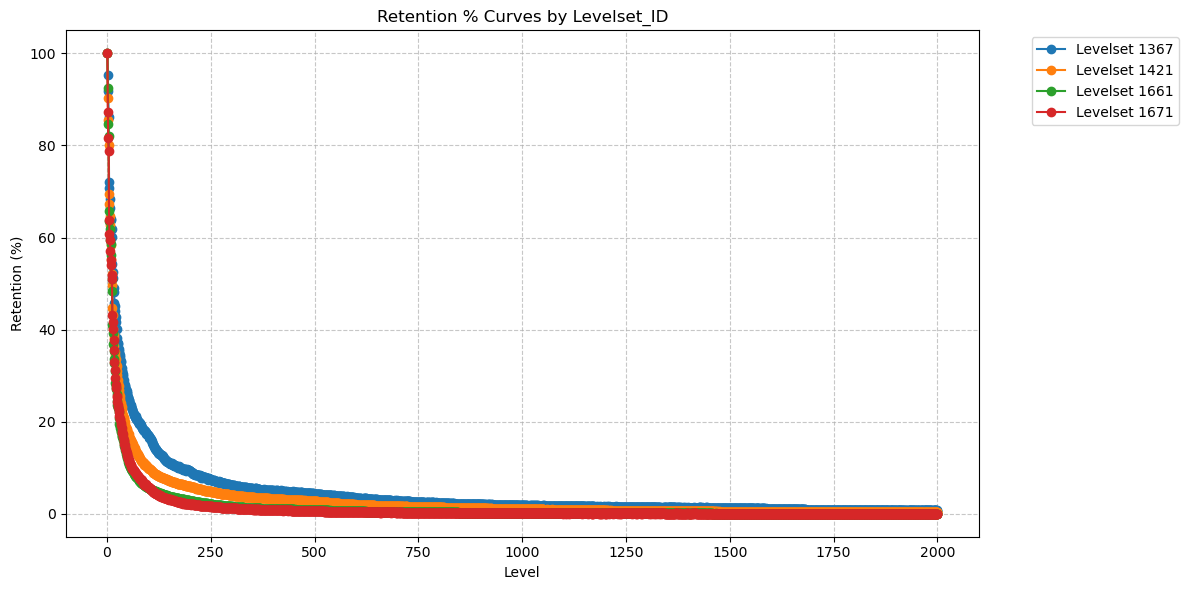

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('filled_dataset.csv')

# Inspect the data
print(df.head())
print(df.info())

# Ensure the data is sorted by Levelset_ID and level
df = df.sort_values(['Levelset_ID', 'level_no'])

# Calculate retention percentage for each Levelset_ID
def calculate_retention(group):
    # Find the number of users at the first level (min level)
    # Assuming the first row in the sorted group is the start
    initial_users = group.iloc[0]['kept_users']
    group['retention_pct'] = (group['kept_users'] / initial_users) * 100
    return group

df = df.groupby('Levelset_ID', group_keys=False).apply(calculate_retention)

# Plotting the retention curves
plt.figure(figsize=(12, 6))
for levelset_id, group in df.groupby('Levelset_ID'):
    plt.plot(group['level_no'], group['retention_pct'], marker='o', label=f'Levelset {levelset_id}')

plt.title('Retention % Curves by Levelset_ID')
plt.xlabel('Level')
plt.ylabel('Retention (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('retention_curves.png')

# Also save the processed data with retention values
df.to_csv('retention_processed_data.csv', index=False)

### CURVE FITTING

LEVELSETS RANKED BY RETENTION (Best to Worst)

Rank | Levelset_ID | Decay Rate (b) | R² Score | Equation
--------------------------------------------------------------------------------
  1 |        1367 | 0.016577 | 0.9154 | y = 65.6·e^(-0.0166x) + 2.4
  2 |        1421 | 0.030385 | 0.9125 | y = 75.8·e^(-0.0304x) + 1.6
  3 |        1671 | 0.042552 | 0.9622 | y = 84.5·e^(-0.0426x) + 0.5
  4 |        1661 | 0.048199 | 0.9552 | y = 88.8·e^(-0.0482x) + 0.6


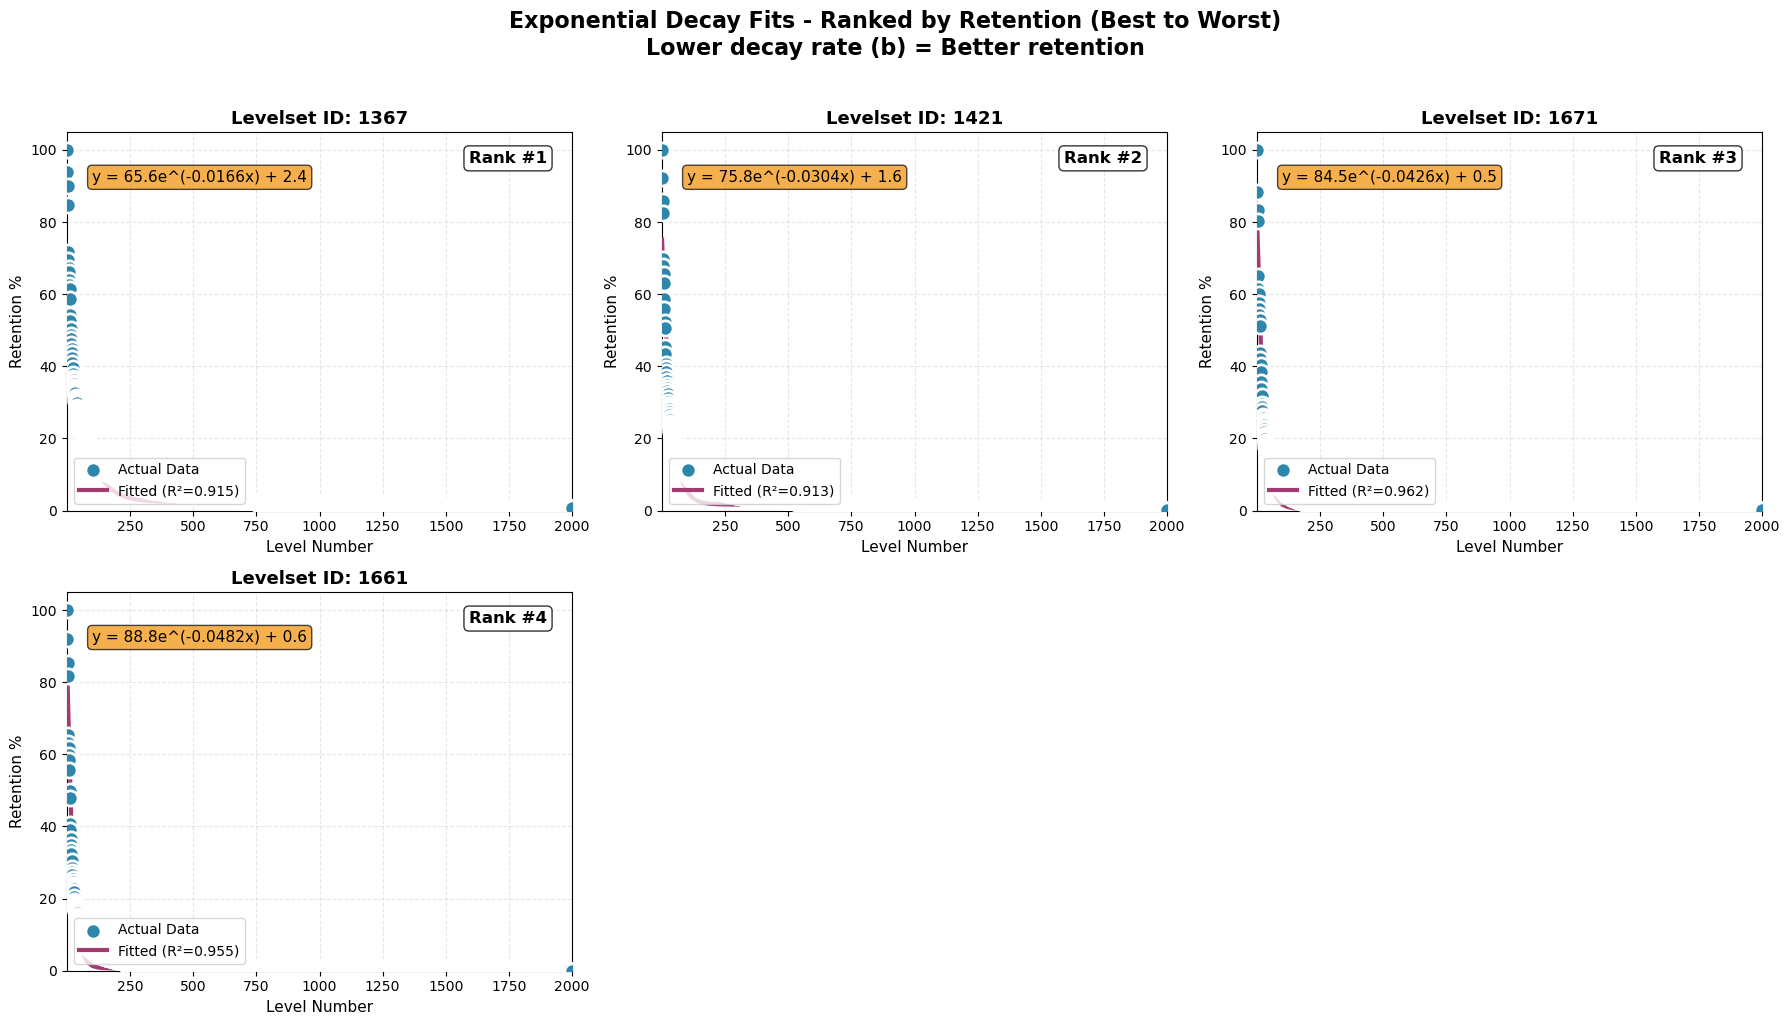

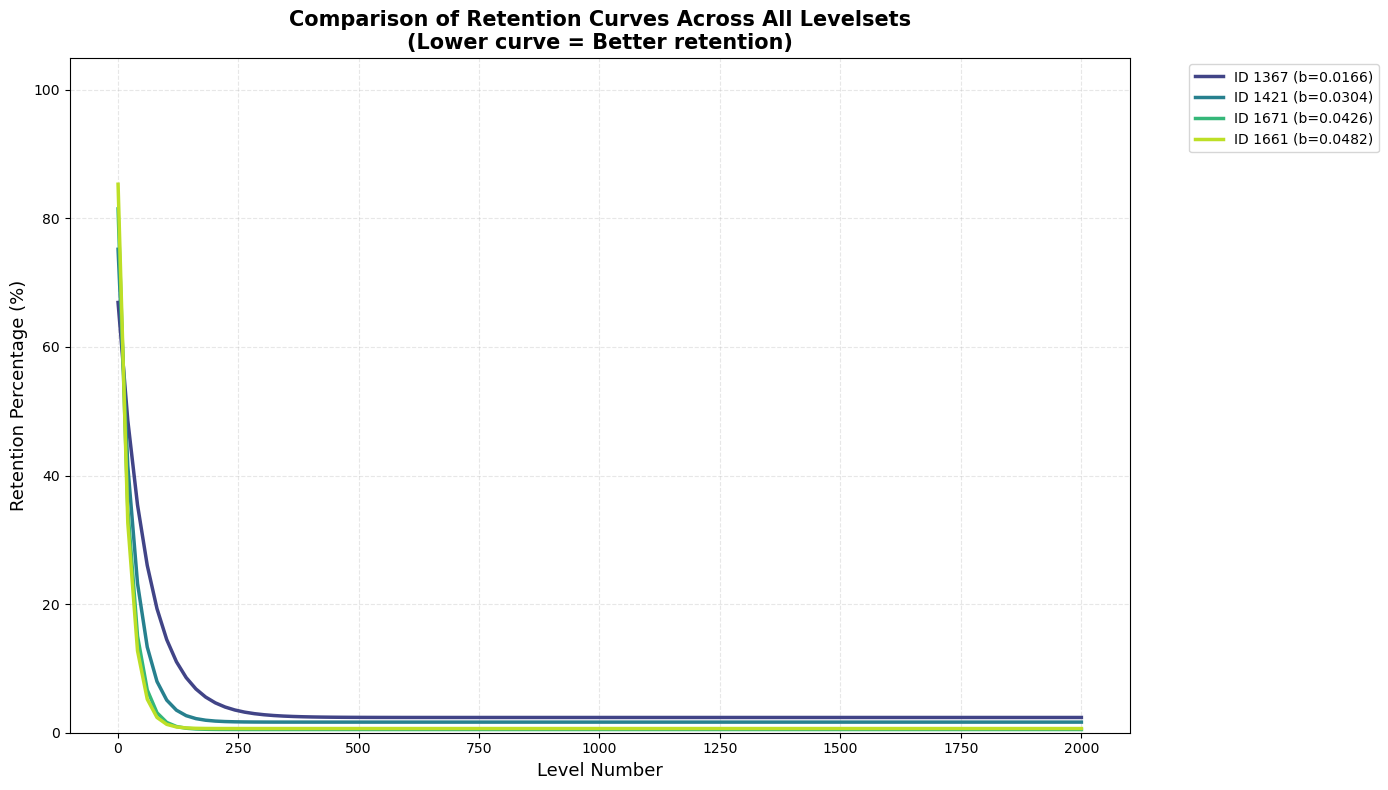


SUMMARY - BEST AND WORST RETENTION

🏆 BEST RETENTION (Least Steep):
   Levelset_ID: 1367
   Equation: y = 65.6·e^(-0.0166x) + 2.4
   Decay Rate (b): 0.016577

📉 WORST RETENTION (Most Steep):
   Levelset_ID: 1661
   Equation: y = 88.8·e^(-0.0482x) + 0.6
   Decay Rate (b): 0.048199


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

# Read the data
data = pd.read_csv('filled_dataset.csv')

# Define exponential decay function
def exp_decay(x, a, b, c):
    """Exponential decay: y = a * exp(-b * x) + c"""
    return a * np.exp(-b * x) + c

# Calculate retention percentages for each levelset
retention_data = []

for levelset_id in data['Levelset_ID'].unique():
    levelset_df = data[data['Levelset_ID'] == levelset_id].sort_values('level_no')
    
    if len(levelset_df) < 3:
        continue
        
    initial_users = levelset_df.iloc[0]['total_users']
    levels = levelset_df['level_no'].values
    retention_pct = (levelset_df['total_users'].values / initial_users) * 100
    
    retention_data.append({
        'Levelset_ID': levelset_id,
        'levels': levels,
        'retention_pct': retention_pct,
        'initial_users': initial_users
    })

# Fit curves for each levelset
results = []

for item in retention_data:
    levelset_id = item['Levelset_ID']
    x = item['levels']
    y = item['retention_pct']
    
    try:
        # Fit 3-parameter exponential decay
        p0 = [100, 0.1, 0]
        bounds = ([0, 0, -10], [200, 2, 50])
        
        params, _ = curve_fit(exp_decay, x, y, p0=p0, bounds=bounds, maxfev=5000)
        y_pred = exp_decay(x, *params)
        r2 = r2_score(y, y_pred)
        
        results.append({
            'Levelset_ID': levelset_id,
            'R2': r2,
            'a': params[0],
            'b': params[1],  # decay rate (steepness)
            'c': params[2],
            'x': x,
            'y': y,
            'initial_users': item['initial_users']
        })
    except:
        continue

# Sort by b parameter (decay rate) - smallest b = least steep = best retention
results_sorted = sorted(results, key=lambda x: x['b'])

print("=" * 80)
print("LEVELSETS RANKED BY RETENTION (Best to Worst)")
print("=" * 80)
print("\nRank | Levelset_ID | Decay Rate (b) | R² Score | Equation")
print("-" * 80)

for rank, res in enumerate(results_sorted, 1):
    print(f"{rank:3d} | {res['Levelset_ID']:11d} | {res['b']:.6f} | {res['R2']:.4f} | "
          f"y = {res['a']:.1f}·e^(-{res['b']:.4f}x) + {res['c']:.1f}")

# Create plots - one figure with subplots for all levelsets
n_plots = len(results_sorted)
n_cols = 3
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten() if n_plots > 1 else [axes]

for idx, res in enumerate(results_sorted):
    ax = axes[idx]
    levelset_id = res['Levelset_ID']
    x = res['x']
    y = res['y']
    a, b, c = res['a'], res['b'], res['c']
    r2 = res['R2']
    
    # Plot actual data
    ax.scatter(x, y, color='#2E86AB', s=120, label='Actual Data', 
               zorder=5, edgecolors='white', linewidth=2)
    
    # Generate smooth curve
    x_smooth = np.linspace(min(x), max(x), 100)
    y_smooth = exp_decay(x_smooth, a, b, c)
    
    # Plot fitted curve
    ax.plot(x_smooth, y_smooth, '#A23B72', linewidth=3, 
            label=f'Fitted (R²={r2:.3f})', zorder=4)
    
    # Add equation
    eq_text = f'y = {a:.1f}e^(-{b:.4f}x) + {c:.1f}'
    ax.text(0.05, 0.90, eq_text, transform=ax.transAxes, 
            fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='#F18F01', alpha=0.7))
    
    # Add rank
    rank = idx + 1
    ax.text(0.95, 0.95, f'Rank #{rank}', transform=ax.transAxes,
            fontsize=12, fontweight='bold', ha='right', va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlabel('Level Number', fontsize=11)
    ax.set_ylabel('Retention %', fontsize=11)
    ax.set_title(f'Levelset ID: {levelset_id}', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='lower left')
    ax.set_ylim([0, 105])
    ax.set_xlim([min(x)-0.5, max(x)+0.5])

# Hide unused subplots
for idx in range(n_plots, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Exponential Decay Fits - Ranked by Retention (Best to Worst)\n'
             'Lower decay rate (b) = Better retention', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Create a combined plot with all curves
plt.figure(figsize=(14, 8))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(results_sorted)))

for idx, res in enumerate(results_sorted):
    levelset_id = res['Levelset_ID']
    a, b, c = res['a'], res['b'], res['c']
    
    x_smooth = np.linspace(1, max(res['x']), 100)
    y_smooth = exp_decay(x_smooth, a, b, c)
    
    plt.plot(x_smooth, y_smooth, color=colors[idx], linewidth=2.5, 
             label=f'ID {levelset_id} (b={b:.4f})')

plt.xlabel('Level Number', fontsize=13)
plt.ylabel('Retention Percentage (%)', fontsize=13)
plt.title('Comparison of Retention Curves Across All Levelsets\n'
          '(Lower curve = Better retention)', fontsize=15, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.ylim([0, 105])
plt.tight_layout()
plt.show()

# Print summary of best and worst
print("\n" + "=" * 80)
print("SUMMARY - BEST AND WORST RETENTION")
print("=" * 80)
print(f"\n🏆 BEST RETENTION (Least Steep):")
print(f"   Levelset_ID: {results_sorted[0]['Levelset_ID']}")
print(f"   Equation: y = {results_sorted[0]['a']:.1f}·e^(-{results_sorted[0]['b']:.4f}x) + {results_sorted[0]['c']:.1f}")
print(f"   Decay Rate (b): {results_sorted[0]['b']:.6f}")

print(f"\n📉 WORST RETENTION (Most Steep):")
print(f"   Levelset_ID: {results_sorted[-1]['Levelset_ID']}")
print(f"   Equation: y = {results_sorted[-1]['a']:.1f}·e^(-{results_sorted[-1]['b']:.4f}x) + {results_sorted[-1]['c']:.1f}")
print(f"   Decay Rate (b): {results_sorted[-1]['b']:.6f}")

### PHASE CLUSTERING

UNSUPERVISED LEARNING - GAME PHASE CLASSIFICATION (FIRST 250 LEVELS)

Total levelsets processed: 4
Total levels classified: 1000
Max level: 250

OVERALL CLASSIFICATION SUMMARY (First 250 Levels)

ONBOARDING:
  Number of levels: 12 (1.2%)
  Level range: 1 - 3
  Avg level: 2.0
  Retention range: 83.3% - 100.0%
  Avg retention: 92.6%
  Board count range: 2 - 3
  Avg board count: 2.5

EARLY GAME:
  Number of levels: 21 (2.1%)
  Level range: 4 - 11
  Avg level: 6.4
  Retention range: 60.2% - 84.8%
  Avg retention: 68.3%
  Board count range: 3 - 7
  Avg board count: 4.4

MID GAME:
  Number of levels: 267 (26.7%)
  Level range: 8 - 75
  Avg level: 42.1
  Retention range: 7.4% - 59.8%
  Avg retention: 23.6%
  Board count range: 4 - 11
  Avg board count: 6.6

LATE GAME:
  Number of levels: 700 (70.0%)
  Level range: 76 - 250
  Avg level: 163.0
  Retention range: 1.6% - 19.7%
  Avg retention: 6.5%
  Board count range: 5 - 15
  Avg board count: 10.1

GENERATING LARGE VISUALIZATIONS...


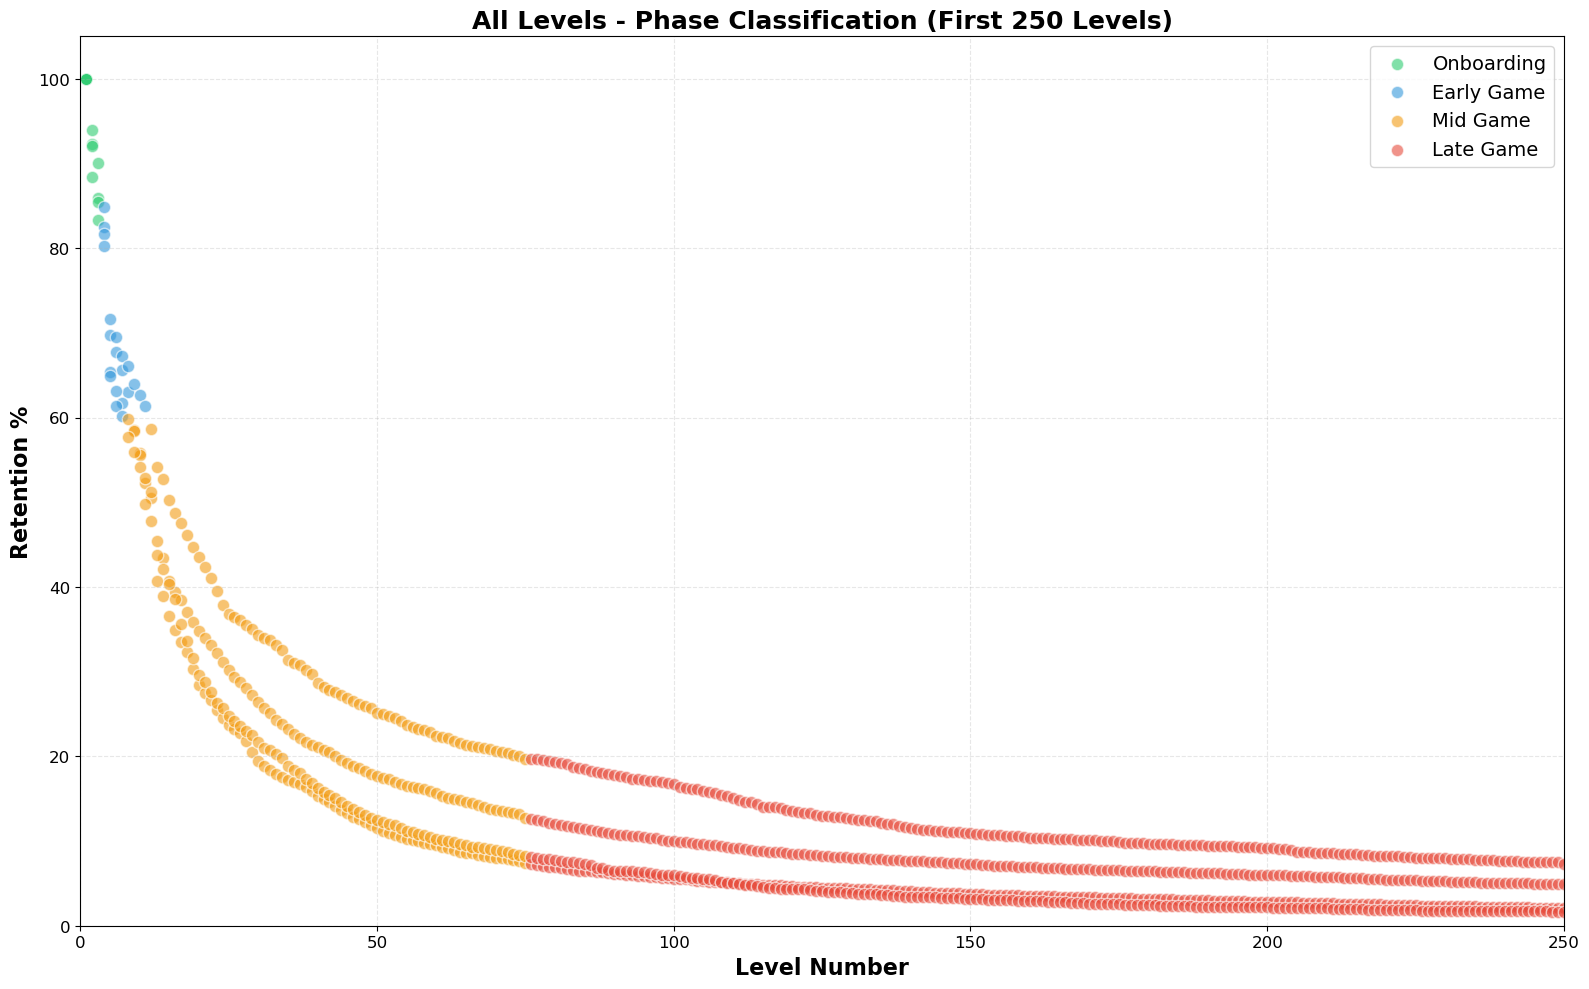

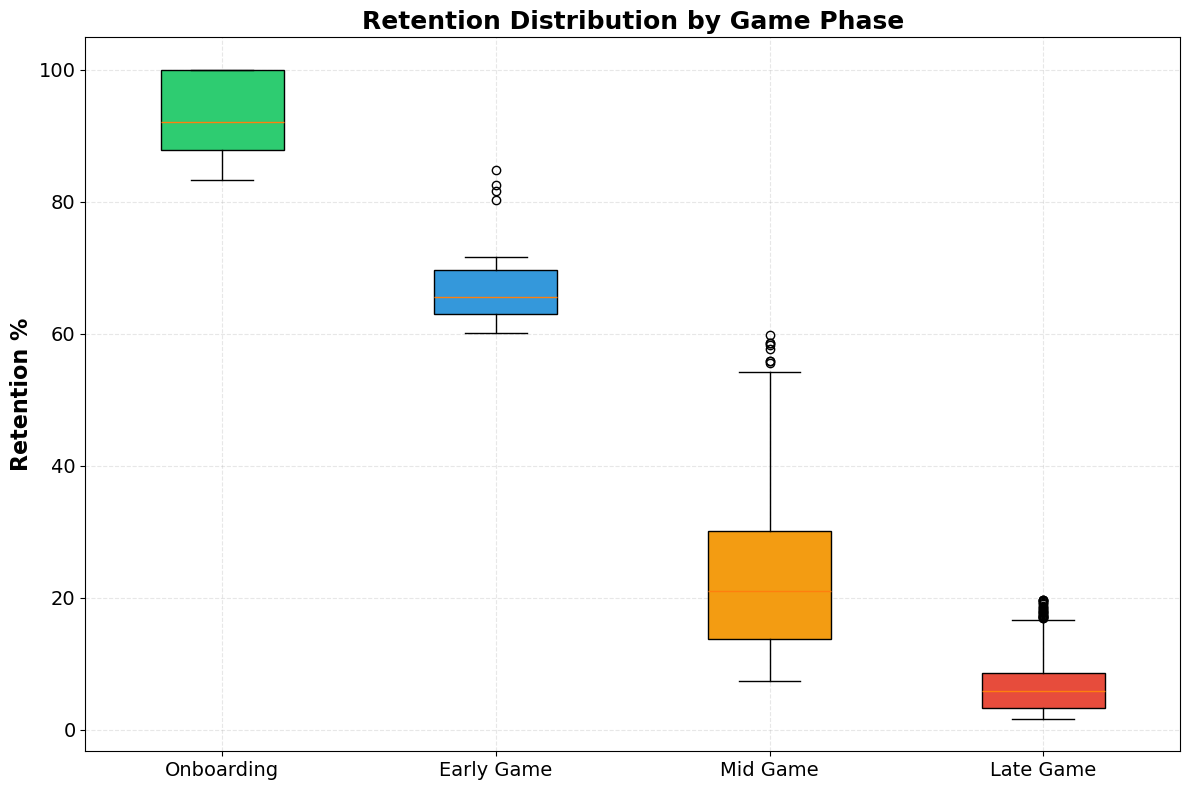

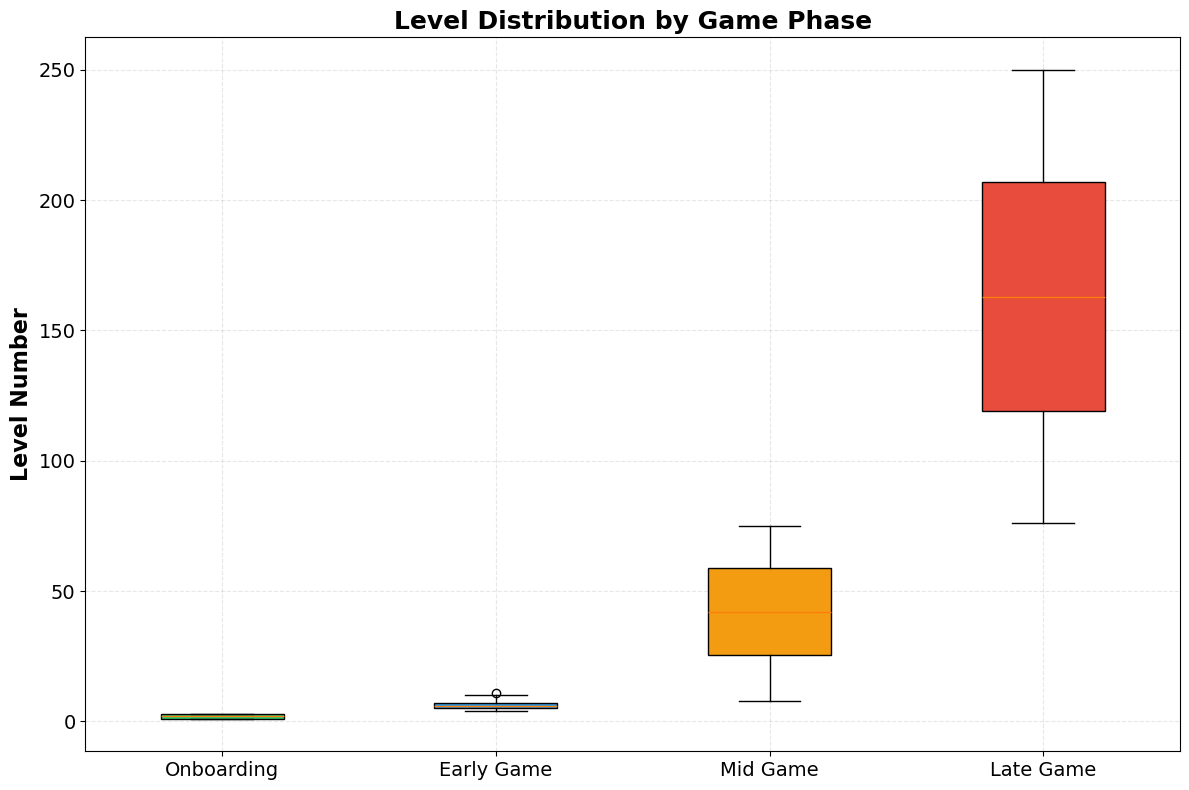

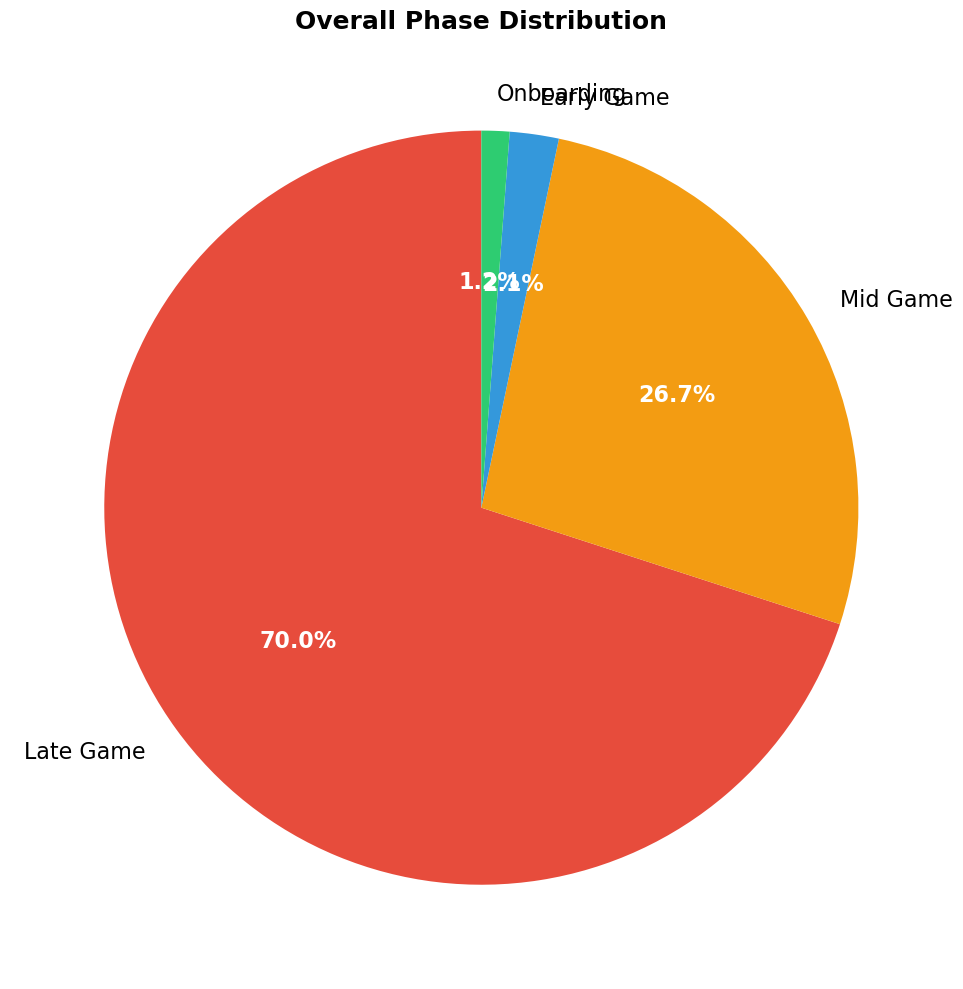

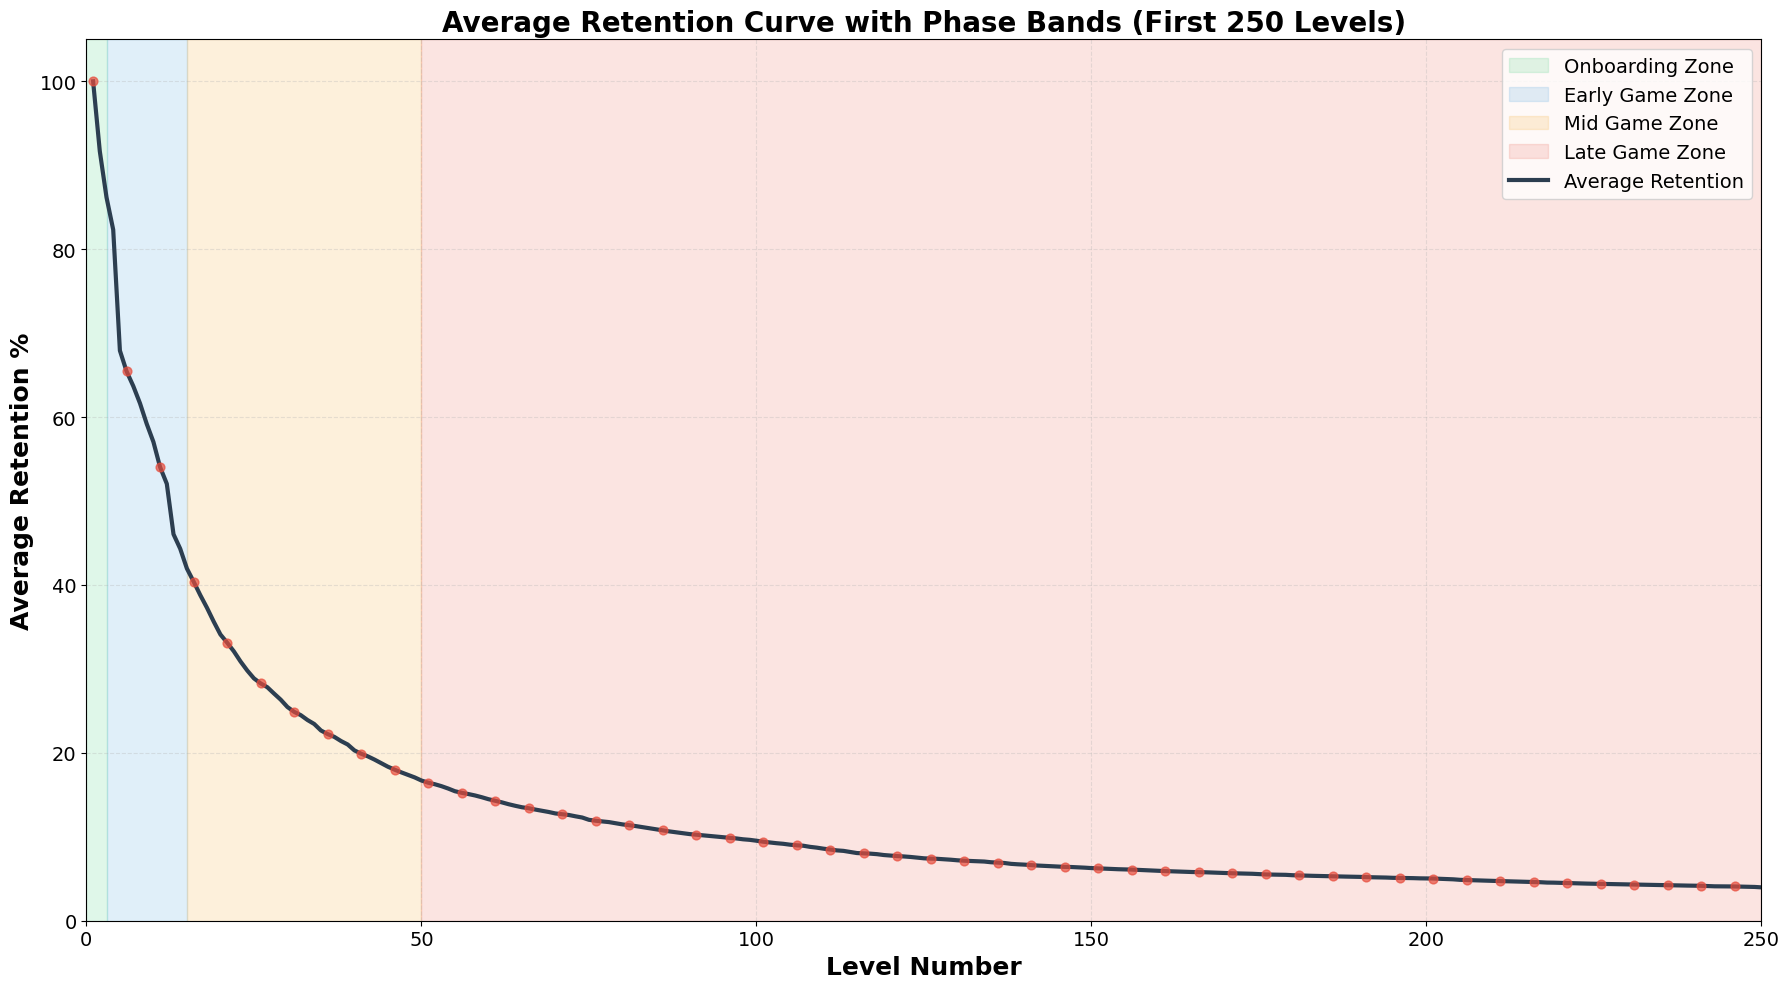

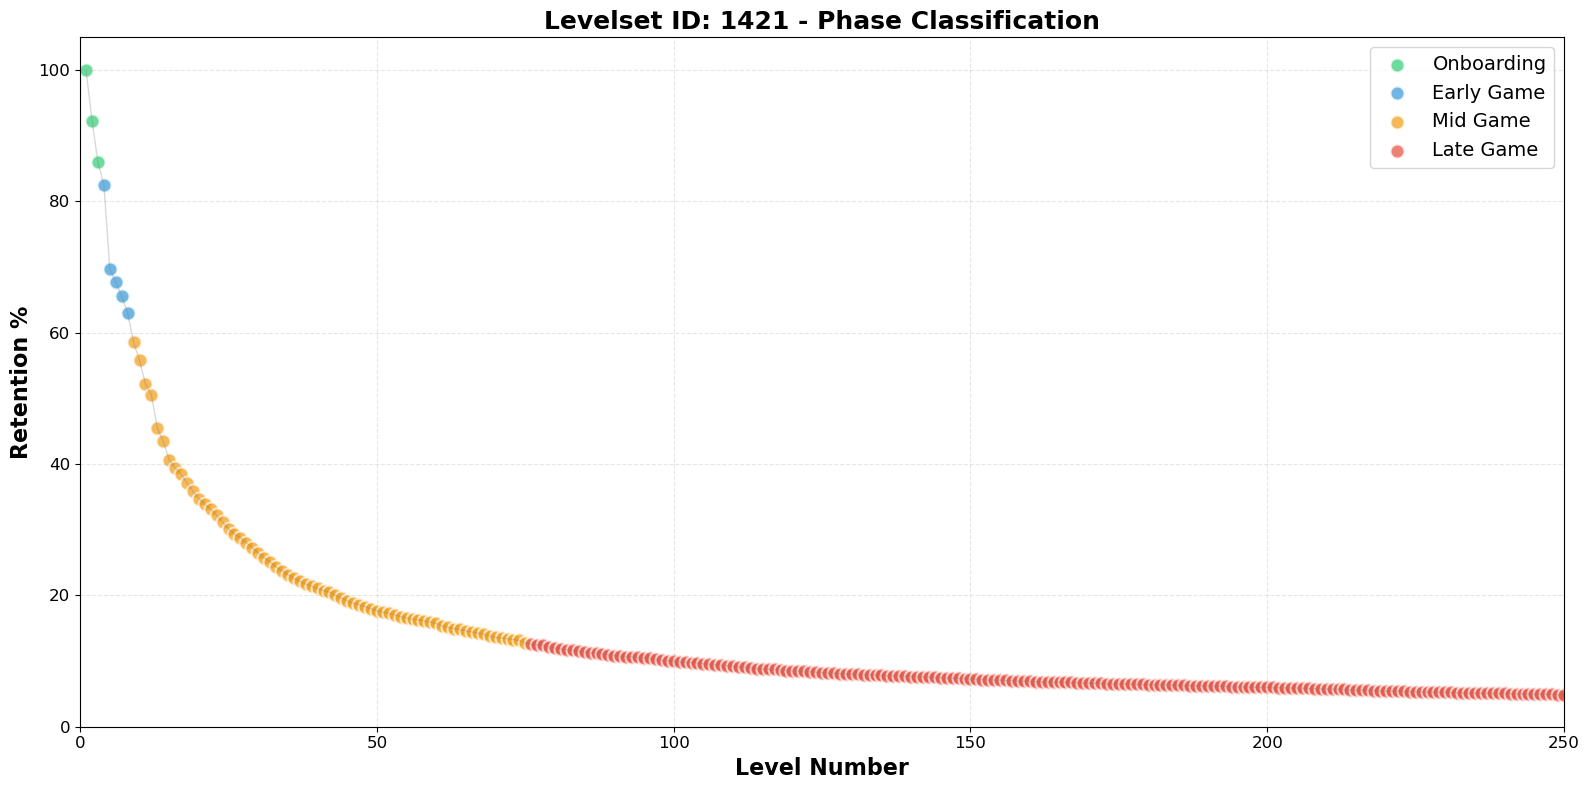

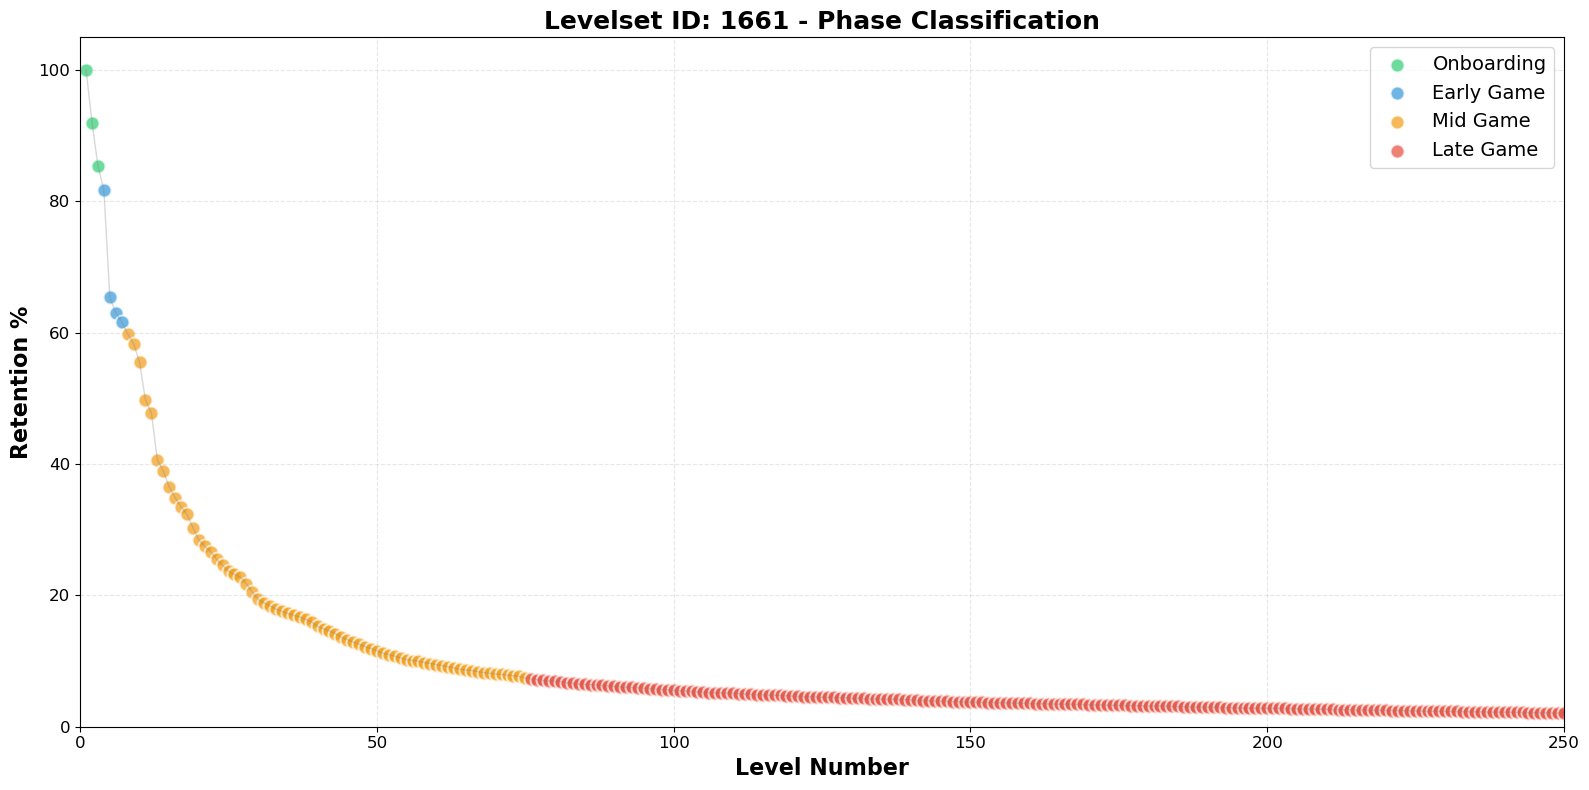

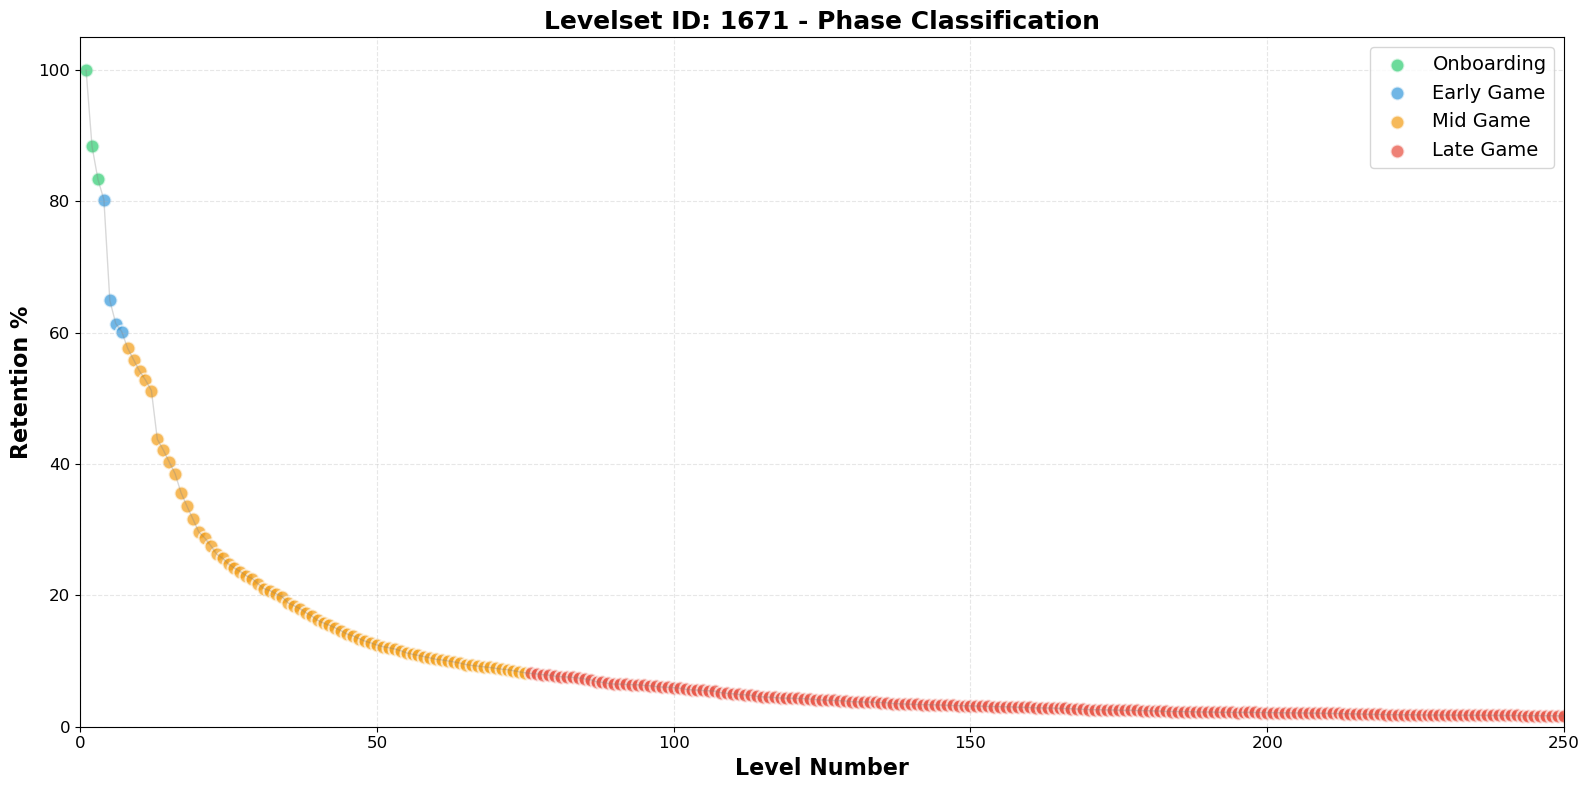

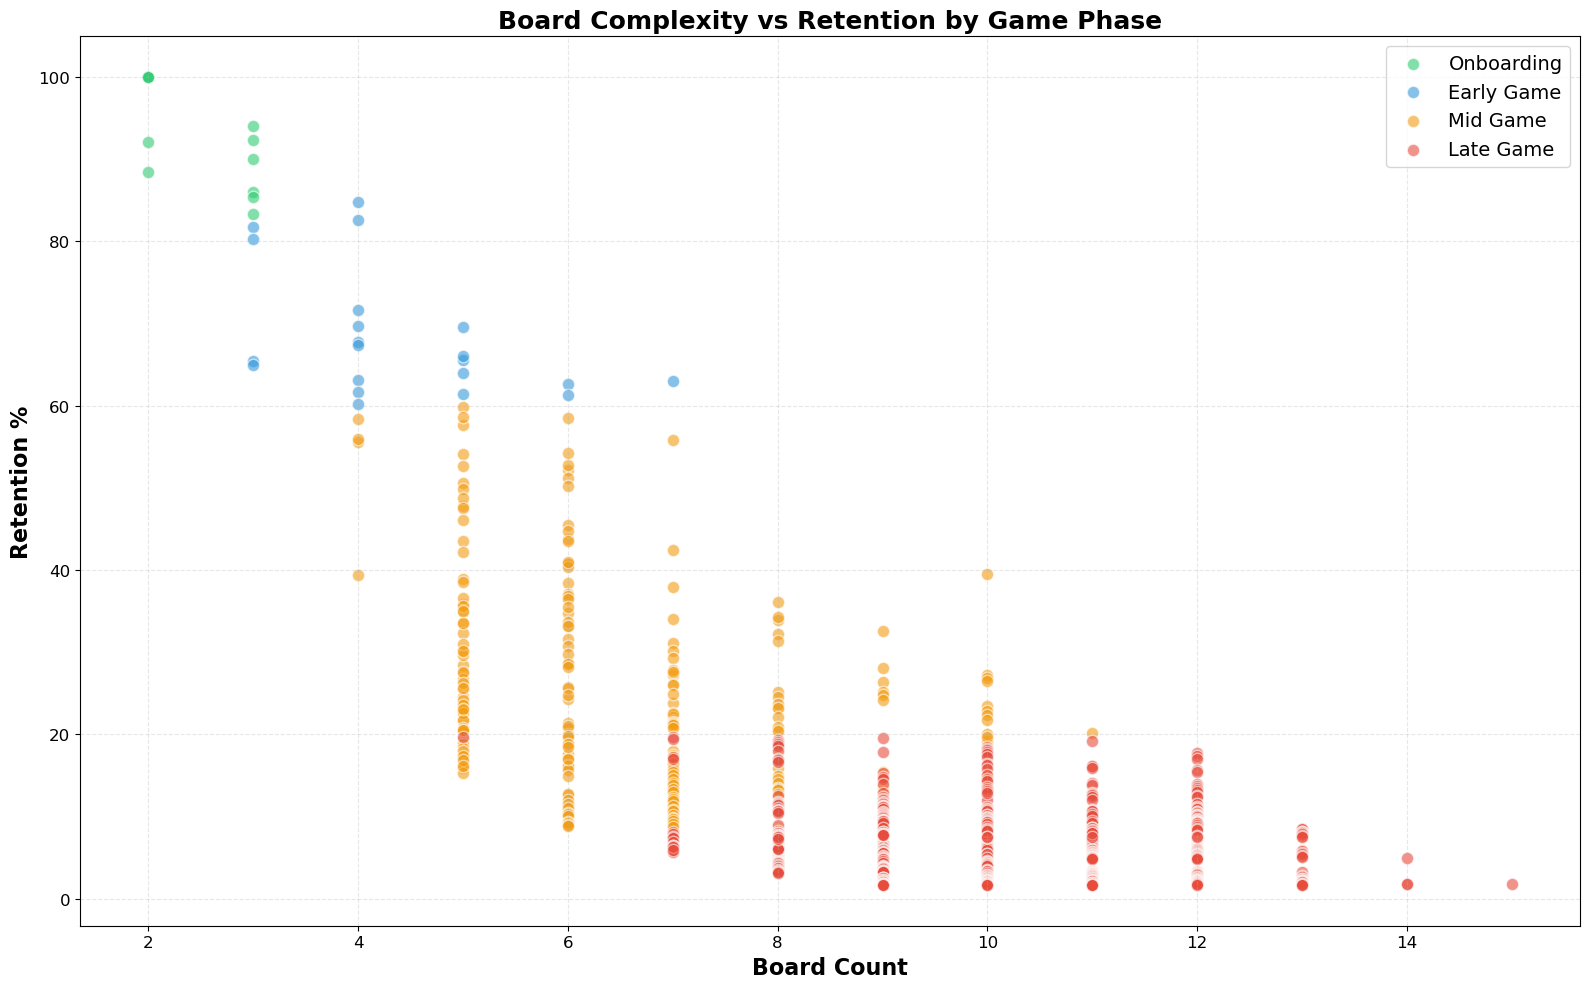


PHASE TRANSITION SUMMARY (Typical Boundaries)
           level_no                   retention_pct      
                min  max   mean   std          mean   std
phase                                                    
Early Game        4   11    6.4   2.0          68.3   7.6
Late Game        76  250  163.0  50.6           6.5   4.0
Mid Game          8   75   42.1  19.3          23.6  12.7
Onboarding        1    3    2.0   0.9          92.6   6.2

TYPICAL TRANSITION RULES

Based on analysis of first 250 levels across all levelsets:
  • Onboarding:  Typically Levels 1-3 (Retention > 85%)
  • Early Game:  Typically Levels 4-15 (Retention 60-85%)
  • Mid Game:    Typically Levels 16-50 (Retention 30-60%)
  • Late Game:   Typically Levels 51+ (Retention < 30%)

PHASE BOUNDARY STATISTICS

Onboarding → Early Game Transition:
  Median transition level: 4
  Mean transition level: 4.0 ± 0.0
  Range: 4 - 4

Early Game → Mid Game Transition:
  Median transition level: 8
  Mean transition level:

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
import warnings
warnings.filterwarnings('ignore')

# Read the data
data = pd.read_csv('filled_dataset.csv')

# Calculate retention % for each row within its levelset
data['retention_pct'] = 0.0

for levelset_id in data['Levelset_ID'].unique():
    mask = data['Levelset_ID'] == levelset_id
    levelset_data = data[mask].sort_values('level_no')
    
    if len(levelset_data) > 0:
        initial_users = levelset_data.iloc[0]['total_users']
        data.loc[mask, 'retention_pct'] = (data.loc[mask, 'total_users'] / initial_users) * 100

print("=" * 80)
print("UNSUPERVISED LEARNING - GAME PHASE CLASSIFICATION (FIRST 250 LEVELS)")
print("=" * 80)

# Function to classify phases within a single levelset
def classify_levelset_phases(levelset_df):
    """Classify game phases for a single levelset based on retention patterns"""
    
    levelset_df = levelset_df.sort_values('level_no').copy()
    
    # Limit to first 250 levels
    levelset_df = levelset_df[levelset_df['level_no'] <= 250].copy()
    
    if len(levelset_df) < 3:
        return None
    
    max_level = levelset_df['level_no'].max()
    levels = levelset_df['level_no'].values
    retention = levelset_df['retention_pct'].values
    
    # Initialize phase array
    phases = np.array([''] * len(levelset_df), dtype=object)
    
    # Onboarding: First 1-3 levels OR retention > 85%
    onboarding_mask = (levels <= 3) | (retention >= 85)
    phases[onboarding_mask] = 'Onboarding'
    
    # Early Game: After onboarding but before major retention drop
    retention_below_60 = np.where(retention < 60)[0]
    if len(retention_below_60) > 0:
        first_major_drop = retention_below_60[0]
    else:
        first_major_drop = len(levels)
    
    early_mask = (~onboarding_mask) & (np.arange(len(levels)) < first_major_drop)
    phases[early_mask] = 'Early Game'
    
    # Mid Game: Between 60% and 30% retention
    mid_mask = (phases == '') & ((retention >= 30) | (levels <= max_level * 0.3))
    phases[mid_mask] = 'Mid Game'
    
    # Late Game: Everything else
    late_mask = (phases == '')
    phases[late_mask] = 'Late Game'
    
    levelset_df['phase'] = phases
    return levelset_df

# Apply classification per levelset (first 250 levels only)
classified_dfs = []
levelset_summaries = []

for levelset_id in data['Levelset_ID'].unique():
    levelset_df = data[data['Levelset_ID'] == levelset_id].copy()
    
    classified_df = classify_levelset_phases(levelset_df)
    if classified_df is not None and len(classified_df) > 0:
        classified_dfs.append(classified_df)
        
        # Create summary for this levelset
        for phase in ['Onboarding', 'Early Game', 'Mid Game', 'Late Game']:
            phase_df = classified_df[classified_df['phase'] == phase]
            if len(phase_df) > 0:
                levelset_summaries.append({
                    'Levelset_ID': levelset_id,
                    'Phase': phase,
                    'Num_Levels': len(phase_df),
                    'Min_Level': phase_df['level_no'].min(),
                    'Max_Level': phase_df['level_no'].max(),
                    'Avg_Retention': phase_df['retention_pct'].mean(),
                    'Min_Retention': phase_df['retention_pct'].min(),
                    'Max_Retention': phase_df['retention_pct'].max(),
                    'Avg_Board_Count': phase_df['board_count'].mean()
                })

# Combine all classified data
data_classified = pd.concat(classified_dfs, ignore_index=True)
summary_df = pd.DataFrame(levelset_summaries)

print(f"\nTotal levelsets processed: {len(classified_dfs)}")
print(f"Total levels classified: {len(data_classified)}")
print(f"Max level: {data_classified['level_no'].max():.0f}")

# Overall summary
print("\n" + "=" * 80)
print("OVERALL CLASSIFICATION SUMMARY (First 250 Levels)")
print("=" * 80)

phase_colors = {
    'Onboarding': '#2ECC71',
    'Early Game': '#3498DB',
    'Mid Game': '#F39C12',
    'Late Game': '#E74C3C'
}

for phase in ['Onboarding', 'Early Game', 'Mid Game', 'Late Game']:
    phase_df = data_classified[data_classified['phase'] == phase]
    
    if len(phase_df) > 0:
        print(f"\n{phase.upper()}:")
        print(f"  Number of levels: {len(phase_df)} ({len(phase_df)/len(data_classified)*100:.1f}%)")
        print(f"  Level range: {phase_df['level_no'].min():.0f} - {phase_df['level_no'].max():.0f}")
        print(f"  Avg level: {phase_df['level_no'].mean():.1f}")
        print(f"  Retention range: {phase_df['retention_pct'].min():.1f}% - {phase_df['retention_pct'].max():.1f}%")
        print(f"  Avg retention: {phase_df['retention_pct'].mean():.1f}%")
        print(f"  Board count range: {phase_df['board_count'].min():.0f} - {phase_df['board_count'].max():.0f}")
        print(f"  Avg board count: {phase_df['board_count'].mean():.1f}")

# Create LARGER visualizations - each plot in its own figure
print("\n" + "=" * 80)
print("GENERATING LARGE VISUALIZATIONS...")
print("=" * 80)

# Plot 1: All levels colored by phase (LARGE)
fig, ax = plt.subplots(figsize=(16, 10))
for phase in phase_colors:
    mask = data_classified['phase'] == phase
    ax.scatter(data_classified[mask]['level_no'], 
               data_classified[mask]['retention_pct'],
               c=phase_colors[phase], label=phase, alpha=0.6, s=80, edgecolors='white', linewidth=1)
ax.set_xlabel('Level Number', fontsize=16, fontweight='bold')
ax.set_ylabel('Retention %', fontsize=16, fontweight='bold')
ax.set_title('All Levels - Phase Classification (First 250 Levels)', fontsize=18, fontweight='bold')
ax.legend(fontsize=14, loc='upper right')
ax.grid(True, alpha=0.3, linestyle='--')
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xlim([0, 250])
ax.set_ylim([0, 105])
plt.tight_layout()
plt.show()

# Plot 2: Box plot - Retention by phase (LARGE)
fig, ax = plt.subplots(figsize=(12, 8))
phase_data = []
phase_labels = []
for phase in phase_colors.keys():
    mask = data_classified['phase'] == phase
    if mask.sum() > 0:
        phase_data.append(data_classified[mask]['retention_pct'].values)
        phase_labels.append(phase)

bp = ax.boxplot(phase_data, labels=phase_labels, patch_artist=True)
for patch, phase in zip(bp['boxes'], phase_labels):
    patch.set_facecolor(phase_colors[phase])
ax.set_ylabel('Retention %', fontsize=16, fontweight='bold')
ax.set_title('Retention Distribution by Game Phase', fontsize=18, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

# Plot 3: Box plot - Level by phase (LARGE)
fig, ax = plt.subplots(figsize=(12, 8))
phase_data = []
for phase in phase_colors.keys():
    mask = data_classified['phase'] == phase
    if mask.sum() > 0:
        phase_data.append(data_classified[mask]['level_no'].values)

bp = ax.boxplot(phase_data, labels=phase_labels, patch_artist=True)
for patch, phase in zip(bp['boxes'], phase_labels):
    patch.set_facecolor(phase_colors[phase])
ax.set_ylabel('Level Number', fontsize=16, fontweight='bold')
ax.set_title('Level Distribution by Game Phase', fontsize=18, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

# Plot 4: Phase distribution pie chart (LARGE)
fig, ax = plt.subplots(figsize=(12, 10))
phase_counts = data_classified['phase'].value_counts()
colors = [phase_colors[p] for p in phase_counts.index]
wedges, texts, autotexts = ax.pie(phase_counts.values, labels=phase_counts.index, colors=colors, 
                                   autopct='%1.1f%%', startangle=90, textprops={'fontsize': 16})
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(16)
    autotext.set_fontweight('bold')
ax.set_title('Overall Phase Distribution', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot 5: Average retention curve with phase bands (LARGE)
fig, ax = plt.subplots(figsize=(18, 10))

# Calculate average retention by level
level_avg = data_classified.groupby('level_no')['retention_pct'].mean()
levels = level_avg.index.values
avg_retention = level_avg.values

# Add phase background colors based on typical boundaries
ax.axvspan(0, 3, alpha=0.15, color=phase_colors['Onboarding'], label='Onboarding Zone')
ax.axvspan(3, 15, alpha=0.15, color=phase_colors['Early Game'], label='Early Game Zone')
ax.axvspan(15, 50, alpha=0.15, color=phase_colors['Mid Game'], label='Mid Game Zone')
ax.axvspan(50, 250, alpha=0.15, color=phase_colors['Late Game'], label='Late Game Zone')

ax.plot(levels, avg_retention, 'b-', linewidth=3, label='Average Retention', color='#2C3E50')
ax.scatter(levels[::5], avg_retention[::5], color='#E74C3C', s=40, zorder=5, alpha=0.7)

ax.set_xlabel('Level Number', fontsize=18, fontweight='bold')
ax.set_ylabel('Average Retention %', fontsize=18, fontweight='bold')
ax.set_title('Average Retention Curve with Phase Bands (First 250 Levels)', fontsize=20, fontweight='bold')
ax.legend(fontsize=14, loc='upper right')
ax.grid(True, alpha=0.3, linestyle='--')
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xlim([0, 250])
ax.set_ylim([0, 105])
plt.tight_layout()
plt.show()

# Plot 6: Individual levelset examples (LARGE - 3 separate plots)
levelset_list = data_classified['Levelset_ID'].unique()[:3]

for i, levelset_id in enumerate(levelset_list):
    fig, ax = plt.subplots(figsize=(16, 8))
    ls_data = data_classified[data_classified['Levelset_ID'] == levelset_id].sort_values('level_no')
    
    for phase in phase_colors:
        mask = ls_data['phase'] == phase
        if mask.sum() > 0:
            ax.scatter(ls_data[mask]['level_no'], 
                      ls_data[mask]['retention_pct'],
                      c=phase_colors[phase], label=phase, alpha=0.7, s=100, 
                      edgecolors='white', linewidth=1.5)
    
    # Connect points with line
    ax.plot(ls_data['level_no'], ls_data['retention_pct'], 'gray', alpha=0.3, linewidth=1)
    
    ax.set_xlabel('Level Number', fontsize=16, fontweight='bold')
    ax.set_ylabel('Retention %', fontsize=16, fontweight='bold')
    ax.set_title(f'Levelset ID: {levelset_id} - Phase Classification', fontsize=18, fontweight='bold')
    ax.legend(fontsize=14, loc='upper right')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.set_xlim([0, min(250, ls_data['level_no'].max() + 5)])
    ax.set_ylim([0, 105])
    plt.tight_layout()
    plt.show()

# Plot 7: Board count vs Retention by Phase (LARGE)
fig, ax = plt.subplots(figsize=(16, 10))
for phase in phase_colors:
    mask = data_classified['phase'] == phase
    if mask.sum() > 0:
        ax.scatter(data_classified[mask]['board_count'], 
                  data_classified[mask]['retention_pct'],
                  c=phase_colors[phase], label=phase, alpha=0.6, s=80, 
                  edgecolors='white', linewidth=1)

ax.set_xlabel('Board Count', fontsize=16, fontweight='bold')
ax.set_ylabel('Retention %', fontsize=16, fontweight='bold')
ax.set_title('Board Complexity vs Retention by Game Phase', fontsize=18, fontweight='bold')
ax.legend(fontsize=14, loc='upper right')
ax.grid(True, alpha=0.3, linestyle='--')
ax.tick_params(axis='both', which='major', labelsize=12)
plt.tight_layout()
plt.show()

# Transition boundaries summary
print("\n" + "=" * 80)
print("PHASE TRANSITION SUMMARY (Typical Boundaries)")
print("=" * 80)

# Calculate typical boundaries across all levelsets
phase_stats = data_classified.groupby('phase').agg({
    'level_no': ['min', 'max', 'mean', 'std'],
    'retention_pct': ['mean', 'std']
}).round(1)

print(phase_stats)

print("\n" + "=" * 80)
print("TYPICAL TRANSITION RULES")
print("=" * 80)
print("\nBased on analysis of first 250 levels across all levelsets:")
print(f"  • Onboarding:  Typically Levels 1-3 (Retention > 85%)")
print(f"  • Early Game:  Typically Levels 4-15 (Retention 60-85%)")
print(f"  • Mid Game:    Typically Levels 16-50 (Retention 30-60%)")
print(f"  • Late Game:   Typically Levels 51+ (Retention < 30%)")

# Show distribution of max levels in each phase
print("\n" + "=" * 80)
print("PHASE BOUNDARY STATISTICS")
print("=" * 80)

for phase in ['Onboarding', 'Early Game', 'Mid Game']:
    next_phase = {'Onboarding': 'Early Game', 'Early Game': 'Mid Game', 'Mid Game': 'Late Game'}[phase]
    
    # Find transition points
    transitions = []
    for levelset_id in data_classified['Levelset_ID'].unique():
        ls_data = data_classified[data_classified['Levelset_ID'] == levelset_id].sort_values('level_no')
        
        phase_levels = ls_data[ls_data['phase'] == phase]['level_no'].values
        next_phase_levels = ls_data[ls_data['phase'] == next_phase]['level_no'].values
        
        if len(phase_levels) > 0 and len(next_phase_levels) > 0:
            transition_level = min(next_phase_levels)
            transitions.append(transition_level)
    
    if transitions:
        print(f"\n{phase} → {next_phase} Transition:")
        print(f"  Median transition level: {np.median(transitions):.0f}")
        print(f"  Mean transition level: {np.mean(transitions):.1f} ± {np.std(transitions):.1f}")
        print(f"  Range: {min(transitions):.0f} - {max(transitions):.0f}")

### Difficulty Clustering and Analysis

LEVEL DIFFICULTY CLUSTERING (First 250 Levels per Levelset) – Design Features Only
Total levels for analysis: 1000
Unique levelsets: 4

Extracting features from level_data...

Feature matrix shape: (1000, 8)

Feature descriptions (all controllable by design):
- board_count: Number of separate boards
- dimx, dimy: Board dimensions (width, height)
- word_count: Total number of words
- avg_word_length: Average length of words
- intersections: Overlapping letter cells between words
- max_word_length: Length of longest word
- seed_word_length: Length of seed word shown

Performing KMeans clustering with 5 clusters...

CLUSTER CENTROIDS (Unscaled) – Ordered by Difficulty (1=Easiest, 5=Hardest)
   board_count  dimx  dimy  word_count  avg_word_length  intersections  max_word_length  seed_word_length  difficulty_score  difficulty
0         4.69  4.75  4.80        4.69             3.31           3.77             3.91              3.91              4.54           1
1         6.73  6.59  6.48     

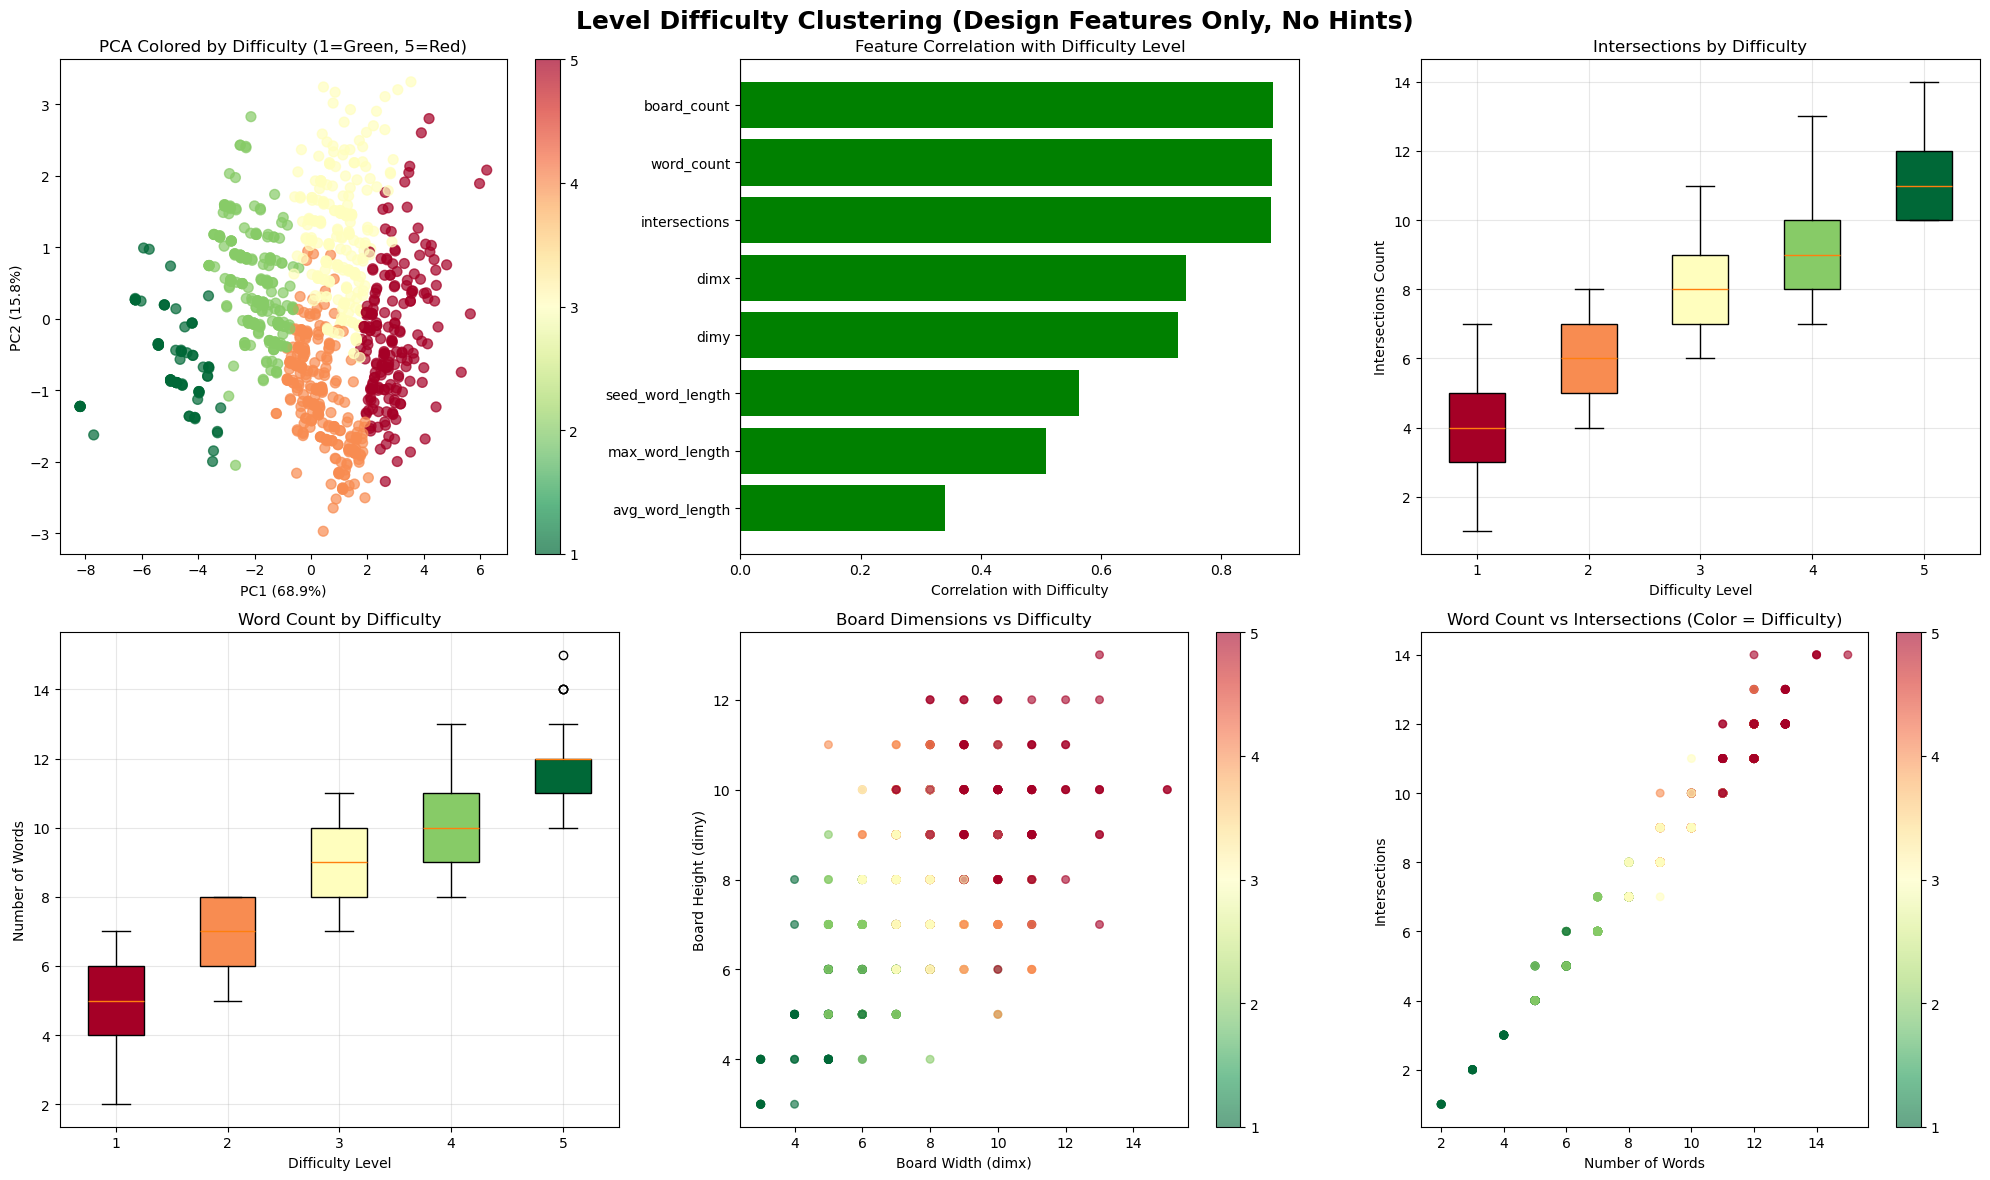


DETAILED DIFFICULTY PROFILES

Difficulty Level 1:
  Count: 81 levels
  Avg. Board Count: 4.69
  Avg. Dimensions: 4.8 x 4.8
  Avg. Words: 4.7
  Avg. Intersections: 3.8
  Avg. Word Length: 3.3
  Avg. Seed Word Length: 3.9

Difficulty Level 2:
  Count: 247 levels
  Avg. Board Count: 6.73
  Avg. Dimensions: 6.6 x 6.5
  Avg. Words: 6.7
  Avg. Intersections: 5.9
  Avg. Word Length: 3.6
  Avg. Seed Word Length: 5.0

Difficulty Level 3:
  Count: 226 levels
  Avg. Board Count: 9.13
  Avg. Dimensions: 7.9 x 8.2
  Avg. Words: 9.1
  Avg. Intersections: 8.3
  Avg. Word Length: 3.8
  Avg. Seed Word Length: 6.1

Difficulty Level 4:
  Count: 251 levels
  Avg. Board Count: 10.14
  Avg. Dimensions: 8.1 x 8.2
  Avg. Words: 10.1
  Avg. Intersections: 9.3
  Avg. Word Length: 3.6
  Avg. Seed Word Length: 5.0

Difficulty Level 5:
  Count: 195 levels
  Avg. Board Count: 11.83
  Avg. Dimensions: 9.7 x 9.4
  Avg. Words: 11.8
  Avg. Intersections: 11.2
  Avg. Word Length: 3.8
  Avg. Seed Word Length: 6.0

EXAMP

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Read data
data = pd.read_csv('filled_dataset.csv')

print("=" * 80)
print("LEVEL DIFFICULTY CLUSTERING (First 250 Levels per Levelset) – Design Features Only")
print("=" * 80)

def extract_level_features(level_data_str):
    try:
        words_info = json.loads(level_data_str)
    except:
        return {
            'word_count': 0, 'total_letters': 0, 'avg_word_length': 0,
            'intersections': 0, 'max_word_length': 0, 'min_word_length': 0
        }
    if not words_info:
        return {
            'word_count': 0, 'total_letters': 0, 'avg_word_length': 0,
            'intersections': 0, 'max_word_length': 0, 'min_word_length': 0
        }

    word_positions = []
    for w in words_info:
        x, y = w['x'], w['y']
        is_horizontal = w.get('IsHorizontal', w.get('isHorizontal', True))
        length = len(w['Word'])
        positions = []
        for i in range(length):
            if is_horizontal:
                positions.append((x + i, y))
            else:
                positions.append((x, y + i))
        word_positions.append(positions)

    word_count = len(word_positions)
    word_lengths = [len(pos) for pos in word_positions]
    total_letters = sum(word_lengths)
    avg_word_length = total_letters / word_count if word_count > 0 else 0

    all_cells = {}
    for positions in word_positions:
        for pos in positions:
            all_cells[pos] = all_cells.get(pos, 0) + 1
    intersections = sum(1 for cnt in all_cells.values() if cnt >= 2)

    max_word_length = max(word_lengths) if word_lengths else 0
    min_word_length = min(word_lengths) if word_lengths else 0

    return {
        'word_count': word_count,
        'total_letters': total_letters,
        'avg_word_length': avg_word_length,
        'intersections': intersections,
        'max_word_length': max_word_length,
        'min_word_length': min_word_length
    }

# Filter first 250 levels per levelset
filtered_data = []
for levelset_id in data['Levelset_ID'].unique():
    ls_data = data[data['Levelset_ID'] == levelset_id].sort_values('level_no')
    ls_data = ls_data[ls_data['level_no'] <= 250]
    filtered_data.append(ls_data)

data_filtered = pd.concat(filtered_data, ignore_index=True)
print(f"Total levels for analysis: {len(data_filtered)}")
print(f"Unique levelsets: {data_filtered['Levelset_ID'].nunique()}")

# Apply feature extraction
print("\nExtracting features from level_data...")
features_df = data_filtered.copy()
extracted = features_df['level_data'].apply(extract_level_features)
features_df = pd.concat([features_df, pd.DataFrame(extracted.tolist())], axis=1)

# Add seed_word length as feature
features_df['seed_word_length'] = features_df['seed_word'].fillna('').astype(str).apply(len)

# Drop hint columns if present
if 'avg_hint' in features_df.columns:
    features_df.drop('avg_hint', axis=1, inplace=True)
if 'sum_hint' in features_df.columns:
    features_df.drop('sum_hint', axis=1, inplace=True)

# Design features only – no hints, no Zipf
feature_columns = [
    'board_count',        # number of boards
    'dimx', 'dimy',       # board dimensions
    'word_count',         # total words
    'avg_word_length',    # average length of words
    'intersections',      # overlapping cells between words
    'max_word_length',
    'seed_word_length'
]

# Handle missing values and ensure numeric
features_df[feature_columns] = features_df[feature_columns].fillna(0)
for col in feature_columns:
    features_df[col] = pd.to_numeric(features_df[col], errors='coerce').fillna(0)

X = features_df[feature_columns].copy()

print("\nFeature matrix shape:", X.shape)
print("\nFeature descriptions (all controllable by design):")
print("- board_count: Number of separate boards")
print("- dimx, dimy: Board dimensions (width, height)")
print("- word_count: Total number of words")
print("- avg_word_length: Average length of words")
print("- intersections: Overlapping letter cells between words")
print("- max_word_length: Length of longest word")
print("- seed_word_length: Length of seed word shown")

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans clustering
print("\nPerforming KMeans clustering with 5 clusters...")
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
features_df['cluster'] = kmeans.fit_predict(X_scaled)

centers_scaled = kmeans.cluster_centers_
centers = scaler.inverse_transform(centers_scaled)
centers_df = pd.DataFrame(centers, columns=feature_columns)

# Difficulty score based on design features (higher = harder)
difficulty_features = ['board_count', 'word_count', 'intersections', 'dimx', 'dimy']
centers_df['difficulty_score'] = centers_df[difficulty_features].mean(axis=1)

# Order clusters by difficulty (1=easiest, 5=hardest)
cluster_order = centers_df['difficulty_score'].sort_values().index
difficulty_mapping = {cluster: i+1 for i, cluster in enumerate(cluster_order)}
features_df['difficulty'] = features_df['cluster'].map(difficulty_mapping)

centers_df['difficulty'] = centers_df.index.map(difficulty_mapping)
centers_df = centers_df.sort_values('difficulty').reset_index(drop=True)

print("\n" + "=" * 80)
print("CLUSTER CENTROIDS (Unscaled) – Ordered by Difficulty (1=Easiest, 5=Hardest)")
print("=" * 80)
print(centers_df.round(2).to_string())

print("\n" + "=" * 80)
print("DIFFICULTY DISTRIBUTION")
print("=" * 80)
dist = features_df['difficulty'].value_counts().sort_index()
for d in range(1, 6):
    count = dist.get(d, 0)
    pct = count / len(features_df) * 100
    print(f"Difficulty {d}: {count} levels ({pct:.1f}%)")

# Visualizations
fig = plt.figure(figsize=(20, 12))

# 1. PCA
ax1 = plt.subplot(2, 3, 1)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
scatter = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=features_df['difficulty'],
                      cmap='RdYlGn_r', s=50, alpha=0.7)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax1.set_title('PCA Colored by Difficulty (1=Green, 5=Red)')
plt.colorbar(scatter, ax=ax1, ticks=range(1, 6))

# 2. Feature correlation with difficulty
ax2 = plt.subplot(2, 3, 2)
corr = X.apply(lambda col: col.corr(features_df['difficulty'])).sort_values()
colors_bar = ['red' if c < 0 else 'green' for c in corr]
ax2.barh(range(len(corr)), corr.values, color=colors_bar)
ax2.set_yticks(range(len(corr)))
ax2.set_yticklabels(corr.index)
ax2.set_xlabel('Correlation with Difficulty')
ax2.set_title('Feature Correlation with Difficulty Level')
ax2.axvline(0, color='black', linewidth=0.8)

# 3. Intersections boxplot
ax3 = plt.subplot(2, 3, 3)
data_by_diff = [features_df[features_df['difficulty'] == i+1]['intersections'].values for i in range(5)]
bp = ax3.boxplot(data_by_diff, labels=[f'{i+1}' for i in range(5)], patch_artist=True)
for patch, i in zip(bp['boxes'], range(5)):
    patch.set_facecolor(plt.cm.RdYlGn_r((4-i)/4))
ax3.set_xlabel('Difficulty Level')
ax3.set_ylabel('Intersections Count')
ax3.set_title('Intersections by Difficulty')
ax3.grid(True, alpha=0.3)

# 4. Word count boxplot
ax4 = plt.subplot(2, 3, 4)
data_by_diff = [features_df[features_df['difficulty'] == i+1]['word_count'].values for i in range(5)]
bp = ax4.boxplot(data_by_diff, labels=[f'{i+1}' for i in range(5)], patch_artist=True)
for patch, i in zip(bp['boxes'], range(5)):
    patch.set_facecolor(plt.cm.RdYlGn_r((4-i)/4))
ax4.set_xlabel('Difficulty Level')
ax4.set_ylabel('Number of Words')
ax4.set_title('Word Count by Difficulty')
ax4.grid(True, alpha=0.3)

# 5. Board dimensions scatter
ax5 = plt.subplot(2, 3, 5)
sc = ax5.scatter(features_df['dimx'], features_df['dimy'],
                 c=features_df['difficulty'], cmap='RdYlGn_r', s=30, alpha=0.6)
ax5.set_xlabel('Board Width (dimx)')
ax5.set_ylabel('Board Height (dimy)')
ax5.set_title('Board Dimensions vs Difficulty')
plt.colorbar(sc, ax=ax5, ticks=range(1, 6))

# 6. Word count vs intersections
ax6 = plt.subplot(2, 3, 6)
sc = ax6.scatter(features_df['word_count'], features_df['intersections'],
                 c=features_df['difficulty'], cmap='RdYlGn_r', s=30, alpha=0.6)
ax6.set_xlabel('Number of Words')
ax6.set_ylabel('Intersections')
ax6.set_title('Word Count vs Intersections (Color = Difficulty)')
plt.colorbar(sc, ax=ax6, ticks=range(1, 6))

plt.suptitle('Level Difficulty Clustering (Design Features Only, No Hints)', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

# Detailed difficulty profiles
print("\n" + "=" * 80)
print("DETAILED DIFFICULTY PROFILES")
print("=" * 80)
for d in range(1, 6):
    subset = features_df[features_df['difficulty'] == d]
    print(f"\nDifficulty Level {d}:")
    print(f"  Count: {len(subset)} levels")
    print(f"  Avg. Board Count: {subset['board_count'].mean():.2f}")
    print(f"  Avg. Dimensions: {subset['dimx'].mean():.1f} x {subset['dimy'].mean():.1f}")
    print(f"  Avg. Words: {subset['word_count'].mean():.1f}")
    print(f"  Avg. Intersections: {subset['intersections'].mean():.1f}")
    print(f"  Avg. Word Length: {subset['avg_word_length'].mean():.1f}")
    print(f"  Avg. Seed Word Length: {subset['seed_word_length'].mean():.1f}")

# Example levels
print("\n" + "=" * 80)
print("EXAMPLE LEVELS FOR EACH DIFFICULTY")
print("=" * 80)
for d in range(1, 6):
    subset = features_df[features_df['difficulty'] == d]
    if len(subset) > 0:
        sample = subset.sample(min(3, len(subset)))
        print(f"\nDifficulty {d} Examples:")
        for _, row in sample.iterrows():
            print(f"  Levelset {row['Levelset_ID']} Level {row['level_no']}: "
                  f"words={row['word_count']}, intersections={row['intersections']}, "
                  f"dim={row['dimx']}x{row['dimy']}")

AVERAGE DIFFICULTY BY PHASE PER LEVELSET (CHRONOLOGICAL)

Average Difficulty Score (1=Easiest, 5=Hardest):
phase        Onboarding  Early Game  Mid Game  Late Game
Levelset_ID                                             
1367                1.0         1.0      2.33       3.72
1421                1.0         1.0      2.21       4.11
1661                1.0         1.0      1.91       3.67
1671                1.0         1.0      1.81       3.64

Number of Levels per Phase:
phase        Onboarding  Early Game  Mid Game  Late Game
Levelset_ID                                             
1367                  3           8        64        175
1421                  3           5        67        175
1661                  3           4        68        175
1671                  3           4        68        175

STATISTICAL COMPARISON: BEST (1367) vs WORST (1661) RETENTION

Onboarding:
  Best Retention (ID 1367): Mean = 1.00 (n=3)
  Worst Retention (ID 1661): Mean = 1.00 (n=3)
  t-test p 

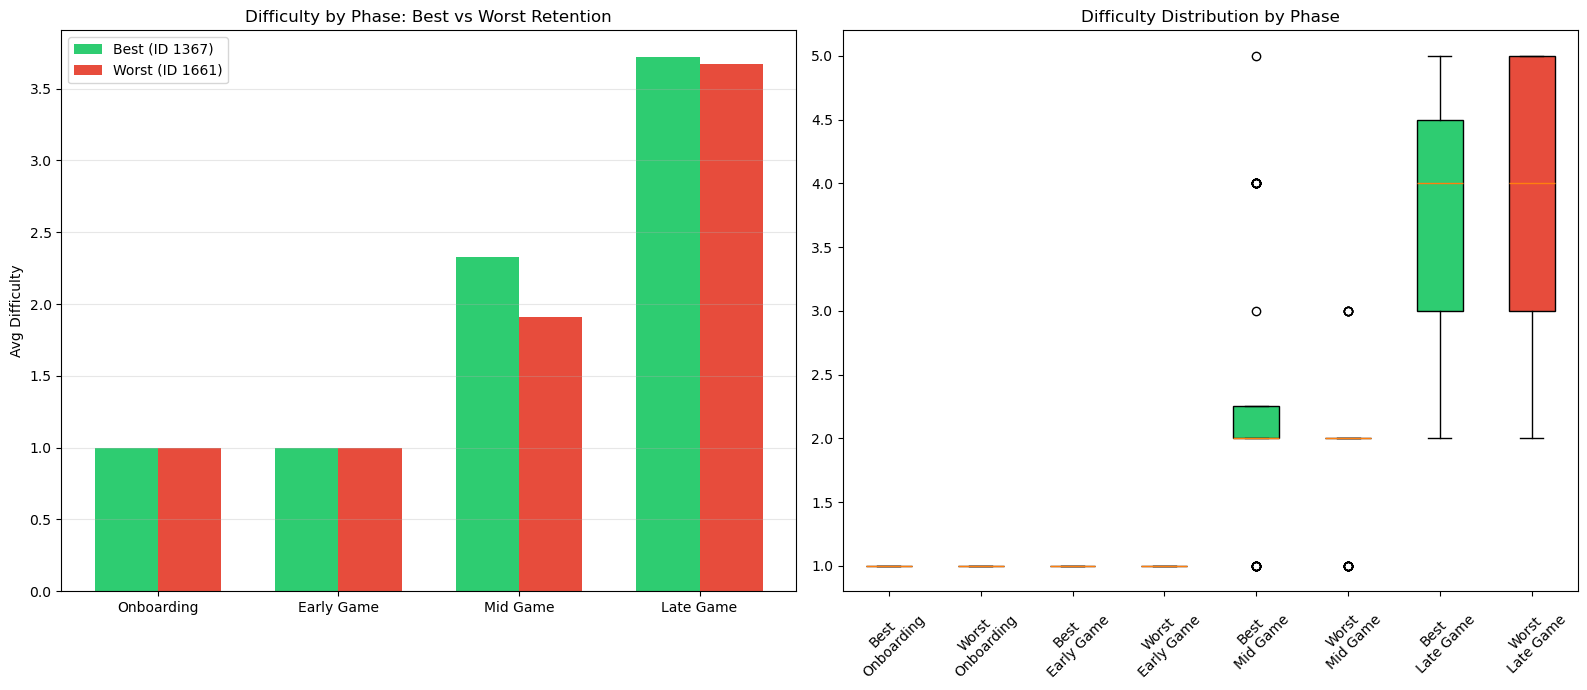


STATISTICAL SUMMARY TABLE
     Phase  Best Mean  Worst Mean  Best n  Worst n  t-test p  M-W p
Onboarding     1.0000      1.0000       3        3       NaN 1.0000
Early Game     1.0000      1.0000       8        4       NaN 1.0000
  Mid Game     2.3281      1.9118      64       68    0.0049 0.0631
 Late Game     3.7200      3.6686     175      175    0.6237 0.8046


In [7]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# 1. SETUP CATEGORICAL ORDERING
# This is the "secret sauce" that fixes the ordering everywhere
phase_order = ['Onboarding', 'Early Game', 'Mid Game', 'Late Game']

# Ensure 'phase' is a categorical type with the fixed order
data_classified['phase'] = pd.Categorical(data_classified['phase'], categories=phase_order, ordered=True)

# 2. MERGE DATA
merged_df = pd.merge(
    data_classified[['Levelset_ID', 'level_no', 'phase']],
    features_df[['Levelset_ID', 'level_no', 'difficulty']],
    on=['Levelset_ID', 'level_no'],
    how='inner'
)

# 3. CALCULATE SUMMARY STATISTICS
print("=" * 80)
print("AVERAGE DIFFICULTY BY PHASE PER LEVELSET (CHRONOLOGICAL)")
print("=" * 80)

# Observed=False ensures all phases show up even if a levelset is missing one
phase_difficulty_summary = merged_df.groupby(['Levelset_ID', 'phase'], observed=False)['difficulty'].agg(['mean', 'count', 'std']).round(2)
phase_difficulty_summary = phase_difficulty_summary.reset_index()

# Pivot for high-level view (Columns will now follow phase_order)
pivot_diff = phase_difficulty_summary.pivot(index='Levelset_ID', columns='phase', values='mean')
pivot_count = phase_difficulty_summary.pivot(index='Levelset_ID', columns='phase', values='count')

print("\nAverage Difficulty Score (1=Easiest, 5=Hardest):")
print(pivot_diff.to_string())

print("\nNumber of Levels per Phase:")
print(pivot_count.fillna(0).astype(int).to_string())

# 4. STATISTICAL COMPARISON: BEST VS WORST
best_retention_levelset = 1367   
worst_retention_levelset = 1661

print("\n" + "=" * 80)
print(f"STATISTICAL COMPARISON: BEST ({best_retention_levelset}) vs WORST ({worst_retention_levelset}) RETENTION")
print("=" * 80)

comparison_results = []
for phase in phase_order:
    best_scores = merged_df[(merged_df['Levelset_ID'] == best_retention_levelset) & 
                            (merged_df['phase'] == phase)]['difficulty'].values
    worst_scores = merged_df[(merged_df['Levelset_ID'] == worst_retention_levelset) & 
                             (merged_df['phase'] == phase)]['difficulty'].values
    
    if len(best_scores) > 0 and len(worst_scores) > 0:
        t_stat, p_value = stats.ttest_ind(best_scores, worst_scores, equal_var=False)
        u_stat, mw_p = stats.mannwhitneyu(best_scores, worst_scores, alternative='two-sided')
        
        comparison_results.append({
            'Phase': phase,
            'Best Mean': np.mean(best_scores),
            'Worst Mean': np.mean(worst_scores),
            'Best n': len(best_scores),
            'Worst n': len(worst_scores),
            't-test p': p_value,
            'M-W p': mw_p
        })
        
        print(f"\n{phase}:")
        print(f"  Best Retention (ID {best_retention_levelset}): Mean = {np.mean(best_scores):.2f} (n={len(best_scores)})")
        print(f"  Worst Retention (ID {worst_retention_levelset}): Mean = {np.mean(worst_scores):.2f} (n={len(worst_scores)})")
        print(f"  t-test p = {p_value:.4f}, Mann-Whitney p = {mw_p:.4f}")
        if p_value < 0.05:
            print("  → Significant difference detected")

# 5. VISUALIZATION
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Bar Chart (Ordered)
ax1 = axes[0]
x = np.arange(len(phase_order))
width = 0.35

best_means = [merged_df[(merged_df['Levelset_ID'] == best_retention_levelset) & (merged_df['phase'] == p)]['difficulty'].mean() for p in phase_order]
worst_means = [merged_df[(merged_df['Levelset_ID'] == worst_retention_levelset) & (merged_df['phase'] == p)]['difficulty'].mean() for p in phase_order]

ax1.bar(x - width/2, best_means, width, label=f'Best (ID {best_retention_levelset})', color='#2ECC71')
ax1.bar(x + width/2, worst_means, width, label=f'Worst (ID {worst_retention_levelset})', color='#E74C3C')

ax1.set_ylabel('Avg Difficulty')
ax1.set_title('Difficulty by Phase: Best vs Worst Retention')
ax1.set_xticks(x)
ax1.set_xticklabels(phase_order)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Boxplot (Ordered)
ax2 = axes[1]
plot_data = []
plot_labels = []

for phase in phase_order:
    # Adding data in pairs (Best then Worst) for each phase
    b_data = merged_df[(merged_df['Levelset_ID'] == best_retention_levelset) & (merged_df['phase'] == phase)]['difficulty'].dropna()
    w_data = merged_df[(merged_df['Levelset_ID'] == worst_retention_levelset) & (merged_df['phase'] == phase)]['difficulty'].dropna()
    
    if not b_data.empty:
        plot_data.append(b_data)
        plot_labels.append(f"Best\n{phase}")
    if not w_data.empty:
        plot_data.append(w_data)
        plot_labels.append(f"Worst\n{phase}")

bp = ax2.boxplot(plot_data, labels=plot_labels, patch_artist=True)
colors = ['#2ECC71', '#E74C3C'] * (len(plot_data)//2)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax2.set_title('Difficulty Distribution by Phase')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 6. FINAL STAT SUMMARY TABLE
if comparison_results:
    print("\n" + "=" * 80)
    print("STATISTICAL SUMMARY TABLE")
    print("=" * 80)
    print(pd.DataFrame(comparison_results).round(4).to_string(index=False))

MID GAME DIFFICULTY PROGRESSION: BEST (1367) vs WORST (1661) RETENTION
Rows represent the sequential order of levels within the Mid Game phase.
No NaNs because they are aligned by position in the phase, not by absolute level number.

 mid_seq  Best_1367_Diff  Worst_1661_Diff
       1             1.0                1
       2             1.0                1
       3             1.0                1
       4             2.0                2
       5             1.0                1
       6             2.0                2
       7             2.0                1
       8             2.0                2
       9             1.0                2
      10             2.0                1
      11             2.0                1
      12             4.0                2
      13             2.0                2
      14             2.0                2
      15             1.0                2
      16             2.0                2
      17             2.0                1
      18  

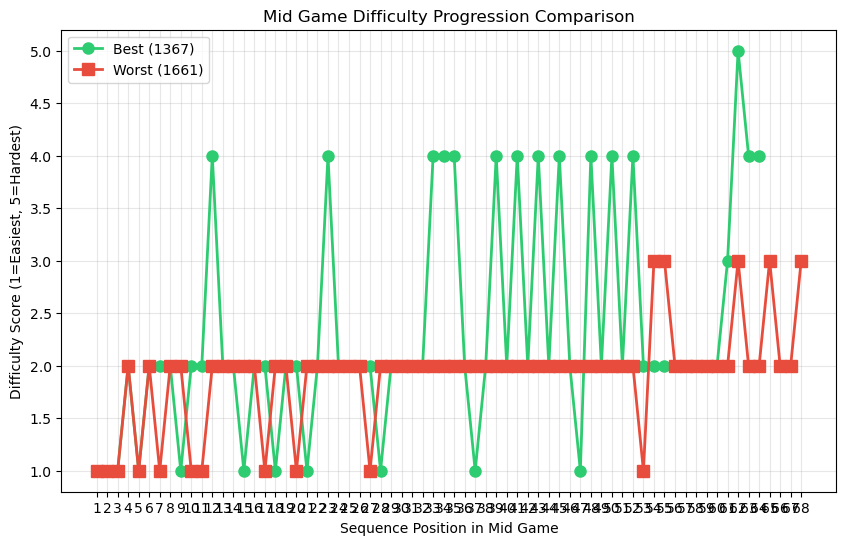


MID GAME DIFFICULTY SUMMARY
Best (1367):  Mean=2.33, Std=1.05, Min=1, Max=5
Worst (1661): Mean=1.91, Std=0.48, Min=1, Max=3


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Assuming merged_df is available from previous steps
best_id = 1367
worst_id = 1661

# Extract Mid Game data for both
best_mid = merged_df[(merged_df['Levelset_ID'] == best_id) & (merged_df['phase'] == 'Mid Game')].copy()
worst_mid = merged_df[(merged_df['Levelset_ID'] == worst_id) & (merged_df['phase'] == 'Mid Game')].copy()

# Sort by level number and add a sequence number (1,2,3,...) for Mid Game progression
best_mid = best_mid.sort_values('level_no').reset_index(drop=True)
worst_mid = worst_mid.sort_values('level_no').reset_index(drop=True)

best_mid['mid_seq'] = best_mid.index + 1
worst_mid['mid_seq'] = worst_mid.index + 1

# Prepare dataframes with just sequence and difficulty
best_seq_df = best_mid[['mid_seq', 'difficulty']].rename(columns={'difficulty': f'Best_{best_id}_Diff'})
worst_seq_df = worst_mid[['mid_seq', 'difficulty']].rename(columns={'difficulty': f'Worst_{worst_id}_Diff'})

# Merge on sequence (outer join to handle different lengths)
comparison_seq = pd.merge(best_seq_df, worst_seq_df, on='mid_seq', how='outer')
comparison_seq['mid_seq'] = comparison_seq['mid_seq'].astype(int)

print("=" * 100)
print(f"MID GAME DIFFICULTY PROGRESSION: BEST ({best_id}) vs WORST ({worst_id}) RETENTION")
print("=" * 100)
print("Rows represent the sequential order of levels within the Mid Game phase.")
print("No NaNs because they are aligned by position in the phase, not by absolute level number.\n")
print(comparison_seq.to_string(index=False))

# Optionally, show the actual level numbers alongside for reference
best_levels = best_mid[['mid_seq', 'level_no']].rename(columns={'level_no': f'Level_{best_id}'})
worst_levels = worst_mid[['mid_seq', 'level_no']].rename(columns={'level_no': f'Level_{worst_id}'})
level_ref = pd.merge(best_levels, worst_levels, on='mid_seq', how='outer')
print("\n" + "=" * 100)
print("REFERENCE: Actual level numbers corresponding to the sequences above")
print("=" * 100)
print(level_ref.to_string(index=False))

# Visualize the progression
plt.figure(figsize=(10, 6))
plt.plot(comparison_seq['mid_seq'], comparison_seq[f'Best_{best_id}_Diff'], 
         'o-', color='#2ECC71', linewidth=2, markersize=8, label=f'Best ({best_id})')
plt.plot(comparison_seq['mid_seq'], comparison_seq[f'Worst_{worst_id}_Diff'], 
         's-', color='#E74C3C', linewidth=2, markersize=8, label=f'Worst ({worst_id})')
plt.xlabel('Sequence Position in Mid Game')
plt.ylabel('Difficulty Score (1=Easiest, 5=Hardest)')
plt.title('Mid Game Difficulty Progression Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(comparison_seq['mid_seq'].dropna().astype(int))
plt.show()

# Summary statistics for Mid Game difficulty
print("\n" + "=" * 100)
print("MID GAME DIFFICULTY SUMMARY")
print("=" * 100)
print(f"Best ({best_id}):  Mean={best_mid['difficulty'].mean():.2f}, Std={best_mid['difficulty'].std():.2f}, "
      f"Min={best_mid['difficulty'].min()}, Max={best_mid['difficulty'].max()}")
print(f"Worst ({worst_id}): Mean={worst_mid['difficulty'].mean():.2f}, Std={worst_mid['difficulty'].std():.2f}, "
      f"Min={worst_mid['difficulty'].min()}, Max={worst_mid['difficulty'].max()}")

In [16]:
import pandas as pd
import numpy as np
import json
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ------------------------------------------------------------
# 1. Re-run difficulty clustering with 10 clusters (1-10 scale)
# ------------------------------------------------------------
# (Assumes 'data' is already loaded and features_df prepared as before)
# We'll reuse the feature extraction and cleaning from previous steps.

# If features_df is not in memory, re-create it:
data = pd.read_csv('filled_dataset.csv')

def extract_level_features(level_data_str):
    try:
        words_info = json.loads(level_data_str)
    except:
        return {'word_count':0, 'total_letters':0, 'avg_word_length':0,
                'intersections':0, 'max_word_length':0, 'min_word_length':0}
    if not words_info:
        return {'word_count':0, 'total_letters':0, 'avg_word_length':0,
                'intersections':0, 'max_word_length':0, 'min_word_length':0}
    word_positions = []
    for w in words_info:
        word = w['Word']
        x, y = w['x'], w['y']
        is_horizontal = w.get('IsHorizontal', w.get('isHorizontal', True))
        length = len(word)
        positions = []
        for i in range(length):
            if is_horizontal:
                positions.append((x + i, y))
            else:
                positions.append((x, y + i))
        word_positions.append(positions)
    word_count = len(word_positions)
    word_lengths = [len(pos) for pos in word_positions]
    total_letters = sum(word_lengths)
    avg_word_length = total_letters / word_count if word_count else 0
    all_cells = {}
    for positions in word_positions:
        for pos in positions:
            all_cells[pos] = all_cells.get(pos, 0) + 1
    intersections = sum(1 for count in all_cells.values() if count >= 2)
    max_word_length = max(word_lengths) if word_lengths else 0
    min_word_length = min(word_lengths) if word_lengths else 0
    return {'word_count':word_count, 'total_letters':total_letters,
            'avg_word_length':avg_word_length, 'intersections':intersections,
            'max_word_length':max_word_length, 'min_word_length':min_word_length}

filtered_data = []
for levelset_id in data['Levelset_ID'].unique():
    ls_data = data[data['Levelset_ID'] == levelset_id].sort_values('level_no')
    ls_data = ls_data[ls_data['level_no'] <= 250]
    filtered_data.append(ls_data)
data_filtered = pd.concat(filtered_data, ignore_index=True)

features_df = data_filtered.copy()
extracted = features_df['level_data'].apply(extract_level_features)
features_df = pd.concat([features_df, pd.DataFrame(extracted.tolist())], axis=1)
features_df['seed_word_length'] = features_df['seed_word'].fillna('').astype(str).apply(len)

def clean_numeric(x):
    if isinstance(x, str):
        return float(x.replace(',', '.'))
    return float(x) if pd.notna(x) else 0.0

features_df['avg_hint'] = features_df['avg_hint'].apply(clean_numeric)
if 'sum_hint' in features_df.columns:
    features_df['sum_hint'] = features_df['sum_hint'].apply(clean_numeric)

feature_columns = ['avg_hint', 'board_count', 'dimx', 'dimy', 'word_count',
                   'avg_word_length', 'intersections', 'max_word_length', 'seed_word_length']
features_df[feature_columns] = features_df[feature_columns].fillna(0)
for col in feature_columns:
    features_df[col] = pd.to_numeric(features_df[col], errors='coerce').fillna(0)

X = features_df[feature_columns].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Use 10 clusters
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)
features_df['cluster'] = cluster_labels

centers_scaled = kmeans.cluster_centers_
centers = scaler.inverse_transform(centers_scaled)
centers_df = pd.DataFrame(centers, columns=feature_columns)

difficulty_features = ['avg_hint', 'board_count', 'word_count', 'intersections', 'dimx', 'dimy']
centers_df['difficulty_score'] = centers_df[difficulty_features].mean(axis=1)

# Order clusters by difficulty score and map to 1-10
cluster_order = centers_df['difficulty_score'].sort_values().index
difficulty_mapping = {cluster: i+1 for i, cluster in enumerate(cluster_order)}
features_df['difficulty_10'] = features_df['cluster'].map(difficulty_mapping)

# ------------------------------------------------------------
# 2. Merge with phase classification (assume data_classified exists)
# ------------------------------------------------------------
merged_df_10 = pd.merge(
    data_classified[['Levelset_ID', 'level_no', 'phase']],
    features_df[['Levelset_ID', 'level_no', 'difficulty_10']],
    on=['Levelset_ID', 'level_no'],
    how='inner'
)

# ------------------------------------------------------------
# 3. Extract Mid Game comparison for best (1367) and worst (1661)
# ------------------------------------------------------------
best_id = 1367
worst_id = 1661

best_mid = merged_df_10[(merged_df_10['Levelset_ID'] == best_id) & (merged_df_10['phase'] == 'Mid Game')].copy()
worst_mid = merged_df_10[(merged_df_10['Levelset_ID'] == worst_id) & (merged_df_10['phase'] == 'Mid Game')].copy()

best_mid = best_mid.sort_values('level_no').reset_index(drop=True)
worst_mid = worst_mid.sort_values('level_no').reset_index(drop=True)

best_mid['mid_seq'] = best_mid.index + 1
worst_mid['mid_seq'] = worst_mid.index + 1

best_seq_df = best_mid[['mid_seq', 'difficulty_10']].rename(columns={'difficulty_10': f'Best_{best_id}_Diff'})
worst_seq_df = worst_mid[['mid_seq', 'difficulty_10']].rename(columns={'difficulty_10': f'Worst_{worst_id}_Diff'})

comparison_seq = pd.merge(best_seq_df, worst_seq_df, on='mid_seq', how='outer')
comparison_seq['mid_seq'] = comparison_seq['mid_seq'].astype(int)

print("=" * 100)
print(f"MID GAME DIFFICULTY PROGRESSION (Scale 1-10): BEST ({best_id}) vs WORST ({worst_id}) RETENTION")
print("=" * 100)
print(comparison_seq.to_string(index=False))

# Reference levels
best_levels = best_mid[['mid_seq', 'level_no']].rename(columns={'level_no': f'Level_{best_id}'})
worst_levels = worst_mid[['mid_seq', 'level_no']].rename(columns={'level_no': f'Level_{worst_id}'})
level_ref = pd.merge(best_levels, worst_levels, on='mid_seq', how='outer')
print("\n" + "=" * 100)
print("REFERENCE: Actual level numbers")
print("=" * 100)
print(level_ref.to_string(index=False))

# Summary stats
print("\n" + "=" * 100)
print("MID GAME DIFFICULTY SUMMARY (1-10 scale)")
print("=" * 100)
print(f"Best ({best_id}):  Mean={best_mid['difficulty_10'].mean():.2f}, Std={best_mid['difficulty_10'].std():.2f}, "
      f"Min={best_mid['difficulty_10'].min()}, Max={best_mid['difficulty_10'].max()}")
print(f"Worst ({worst_id}): Mean={worst_mid['difficulty_10'].mean():.2f}, Std={worst_mid['difficulty_10'].std():.2f}, "
      f"Min={worst_mid['difficulty_10'].min()}, Max={worst_mid['difficulty_10'].max()}")

MID GAME DIFFICULTY PROGRESSION (Scale 1-10): BEST (1367) vs WORST (1661) RETENTION
 mid_seq  Best_1367_Diff  Worst_1661_Diff
       1             1.0                1
       2             1.0                1
       3             1.0                1
       4             2.0                2
       5             1.0                1
       6             2.0                2
       7             2.0                1
       8             2.0                2
       9             1.0                2
      10             5.0                1
      11             5.0                1
      12             8.0                2
      13             2.0                2
      14             2.0                2
      15             1.0                2
      16             4.0                2
      17             2.0                1
      18             1.0                2
      19             4.0                2
      20             2.0                1
      21             1.0          

MID GAME DIFFICULTY PROGRESSION (Scale 1-10): BEST (1367) vs WORST (1661) RETENTION
 mid_seq  Best_1367_Diff  Worst_1661_Diff
       1             1.0                1
       2             1.0                1
       3             1.0                1
       4             2.0                2
       5             1.0                1
       6             2.0                2
       7             2.0                1
       8             2.0                2
       9             1.0                2
      10             5.0                1
      11             5.0                1
      12             8.0                2
      13             2.0                2
      14             2.0                2
      15             1.0                2
      16             4.0                2
      17             2.0                1
      18             1.0                2
      19             4.0                2
      20             2.0                1
      21             1.0          

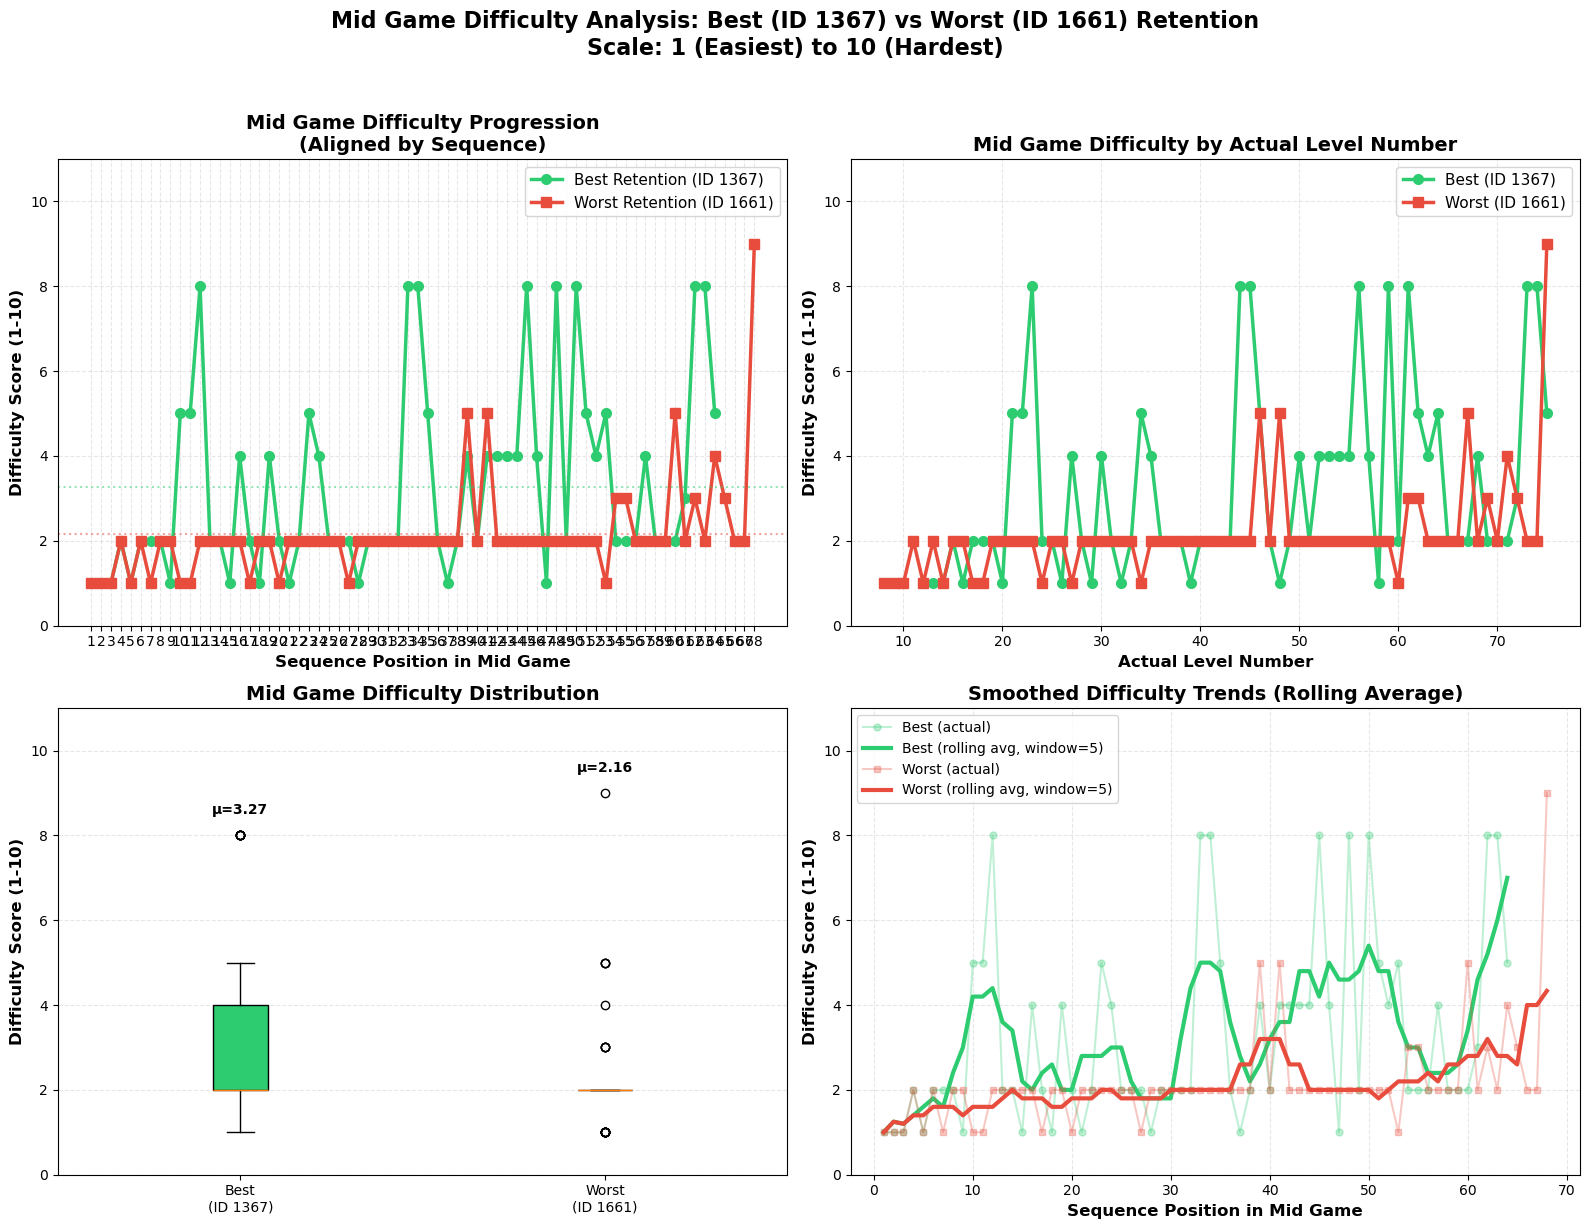

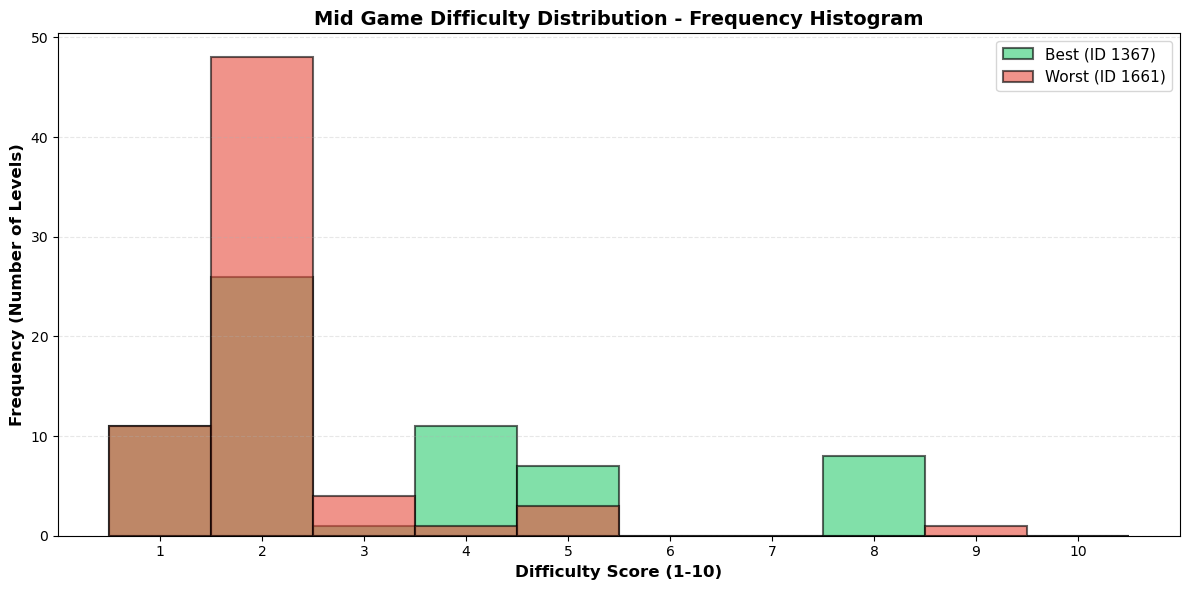

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ------------------------------------------------------------
# 1. Re-run difficulty clustering with 10 clusters (1-10 scale)
# ------------------------------------------------------------
data = pd.read_csv('filled_dataset.csv')

def extract_level_features(level_data_str):
    try:
        words_info = json.loads(level_data_str)
    except:
        return {'word_count':0, 'total_letters':0, 'avg_word_length':0,
                'intersections':0, 'max_word_length':0, 'min_word_length':0}
    if not words_info:
        return {'word_count':0, 'total_letters':0, 'avg_word_length':0,
                'intersections':0, 'max_word_length':0, 'min_word_length':0}
    word_positions = []
    for w in words_info:
        word = w['Word']
        x, y = w['x'], w['y']
        is_horizontal = w.get('IsHorizontal', w.get('isHorizontal', True))
        length = len(word)
        positions = []
        for i in range(length):
            if is_horizontal:
                positions.append((x + i, y))
            else:
                positions.append((x, y + i))
        word_positions.append(positions)
    word_count = len(word_positions)
    word_lengths = [len(pos) for pos in word_positions]
    total_letters = sum(word_lengths)
    avg_word_length = total_letters / word_count if word_count else 0
    all_cells = {}
    for positions in word_positions:
        for pos in positions:
            all_cells[pos] = all_cells.get(pos, 0) + 1
    intersections = sum(1 for count in all_cells.values() if count >= 2)
    max_word_length = max(word_lengths) if word_lengths else 0
    min_word_length = min(word_lengths) if word_lengths else 0
    return {'word_count':word_count, 'total_letters':total_letters,
            'avg_word_length':avg_word_length, 'intersections':intersections,
            'max_word_length':max_word_length, 'min_word_length':min_word_length}

filtered_data = []
for levelset_id in data['Levelset_ID'].unique():
    ls_data = data[data['Levelset_ID'] == levelset_id].sort_values('level_no')
    ls_data = ls_data[ls_data['level_no'] <= 250]
    filtered_data.append(ls_data)
data_filtered = pd.concat(filtered_data, ignore_index=True)

features_df = data_filtered.copy()
extracted = features_df['level_data'].apply(extract_level_features)
features_df = pd.concat([features_df, pd.DataFrame(extracted.tolist())], axis=1)
features_df['seed_word_length'] = features_df['seed_word'].fillna('').astype(str).apply(len)

def clean_numeric(x):
    if isinstance(x, str):
        return float(x.replace(',', '.'))
    return float(x) if pd.notna(x) else 0.0

features_df['avg_hint'] = features_df['avg_hint'].apply(clean_numeric)
if 'sum_hint' in features_df.columns:
    features_df['sum_hint'] = features_df['sum_hint'].apply(clean_numeric)

feature_columns = ['avg_hint', 'board_count', 'dimx', 'dimy', 'word_count',
                   'avg_word_length', 'intersections', 'max_word_length', 'seed_word_length']
features_df[feature_columns] = features_df[feature_columns].fillna(0)
for col in feature_columns:
    features_df[col] = pd.to_numeric(features_df[col], errors='coerce').fillna(0)

X = features_df[feature_columns].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Use 10 clusters
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)
features_df['cluster'] = cluster_labels

centers_scaled = kmeans.cluster_centers_
centers = scaler.inverse_transform(centers_scaled)
centers_df = pd.DataFrame(centers, columns=feature_columns)

difficulty_features = ['avg_hint', 'board_count', 'word_count', 'intersections', 'dimx', 'dimy']
centers_df['difficulty_score'] = centers_df[difficulty_features].mean(axis=1)

# Order clusters by difficulty score and map to 1-10
cluster_order = centers_df['difficulty_score'].sort_values().index
difficulty_mapping = {cluster: i+1 for i, cluster in enumerate(cluster_order)}
features_df['difficulty_10'] = features_df['cluster'].map(difficulty_mapping)

# ------------------------------------------------------------
# 2. Merge with phase classification (assume data_classified exists)
# ------------------------------------------------------------
merged_df_10 = pd.merge(
    data_classified[['Levelset_ID', 'level_no', 'phase']],
    features_df[['Levelset_ID', 'level_no', 'difficulty_10']],
    on=['Levelset_ID', 'level_no'],
    how='inner'
)

# ------------------------------------------------------------
# 3. Extract Mid Game comparison for best (1367) and worst (1661)
# ------------------------------------------------------------
best_id = 1367
worst_id = 1661

best_mid = merged_df_10[(merged_df_10['Levelset_ID'] == best_id) & (merged_df_10['phase'] == 'Mid Game')].copy()
worst_mid = merged_df_10[(merged_df_10['Levelset_ID'] == worst_id) & (merged_df_10['phase'] == 'Mid Game')].copy()

best_mid = best_mid.sort_values('level_no').reset_index(drop=True)
worst_mid = worst_mid.sort_values('level_no').reset_index(drop=True)

best_mid['mid_seq'] = best_mid.index + 1
worst_mid['mid_seq'] = worst_mid.index + 1

best_seq_df = best_mid[['mid_seq', 'difficulty_10']].rename(columns={'difficulty_10': f'Best_{best_id}_Diff'})
worst_seq_df = worst_mid[['mid_seq', 'difficulty_10']].rename(columns={'difficulty_10': f'Worst_{worst_id}_Diff'})

comparison_seq = pd.merge(best_seq_df, worst_seq_df, on='mid_seq', how='outer')
comparison_seq['mid_seq'] = comparison_seq['mid_seq'].astype(int)

print("=" * 100)
print(f"MID GAME DIFFICULTY PROGRESSION (Scale 1-10): BEST ({best_id}) vs WORST ({worst_id}) RETENTION")
print("=" * 100)
print(comparison_seq.to_string(index=False))

# Reference levels
best_levels = best_mid[['mid_seq', 'level_no']].rename(columns={'level_no': f'Level_{best_id}'})
worst_levels = worst_mid[['mid_seq', 'level_no']].rename(columns={'level_no': f'Level_{worst_id}'})
level_ref = pd.merge(best_levels, worst_levels, on='mid_seq', how='outer')
print("\n" + "=" * 100)
print("REFERENCE: Actual level numbers")
print("=" * 100)
print(level_ref.to_string(index=False))

# Summary stats
print("\n" + "=" * 100)
print("MID GAME DIFFICULTY SUMMARY (1-10 scale)")
print("=" * 100)
print(f"Best ({best_id}):  Mean={best_mid['difficulty_10'].mean():.2f}, Std={best_mid['difficulty_10'].std():.2f}, "
      f"Min={best_mid['difficulty_10'].min()}, Max={best_mid['difficulty_10'].max()}")
print(f"Worst ({worst_id}): Mean={worst_mid['difficulty_10'].mean():.2f}, Std={worst_mid['difficulty_10'].std():.2f}, "
      f"Min={worst_mid['difficulty_10'].min()}, Max={worst_mid['difficulty_10'].max()}")

# ------------------------------------------------------------
# 4. GRAPH: Mid Game Difficulty Progression (1-10 scale)
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Line plot - Difficulty progression by sequence
ax1 = axes[0, 0]
ax1.plot(comparison_seq['mid_seq'], comparison_seq[f'Best_{best_id}_Diff'], 
         'o-', color='#2ECC71', linewidth=2.5, markersize=7, label=f'Best Retention (ID {best_id})')
ax1.plot(comparison_seq['mid_seq'], comparison_seq[f'Worst_{worst_id}_Diff'], 
         's-', color='#E74C3C', linewidth=2.5, markersize=7, label=f'Worst Retention (ID {worst_id})')
ax1.set_xlabel('Sequence Position in Mid Game', fontsize=12, fontweight='bold')
ax1.set_ylabel('Difficulty Score (1-10)', fontsize=12, fontweight='bold')
ax1.set_title('Mid Game Difficulty Progression\n(Aligned by Sequence)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xticks(comparison_seq['mid_seq'].dropna().astype(int))
ax1.set_ylim([0, 11])
ax1.axhline(y=best_mid['difficulty_10'].mean(), color='#2ECC71', linestyle=':', alpha=0.5, label=f'Best Mean={best_mid["difficulty_10"].mean():.1f}')
ax1.axhline(y=worst_mid['difficulty_10'].mean(), color='#E74C3C', linestyle=':', alpha=0.5, label=f'Worst Mean={worst_mid["difficulty_10"].mean():.1f}')

# Plot 2: Line plot - Difficulty by actual level number
ax2 = axes[0, 1]
ax2.plot(best_mid['level_no'], best_mid['difficulty_10'], 
         'o-', color='#2ECC71', linewidth=2.5, markersize=7, label=f'Best (ID {best_id})')
ax2.plot(worst_mid['level_no'], worst_mid['difficulty_10'], 
         's-', color='#E74C3C', linewidth=2.5, markersize=7, label=f'Worst (ID {worst_id})')
ax2.set_xlabel('Actual Level Number', fontsize=12, fontweight='bold')
ax2.set_ylabel('Difficulty Score (1-10)', fontsize=12, fontweight='bold')
ax2.set_title('Mid Game Difficulty by Actual Level Number', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_ylim([0, 11])

# Plot 3: Box plot comparison
ax3 = axes[1, 0]
box_data = [best_mid['difficulty_10'].values, worst_mid['difficulty_10'].values]
bp = ax3.boxplot(box_data, labels=[f'Best\n(ID {best_id})', f'Worst\n(ID {worst_id})'], 
                  patch_artist=True)
bp['boxes'][0].set_facecolor('#2ECC71')
bp['boxes'][1].set_facecolor('#E74C3C')
ax3.set_ylabel('Difficulty Score (1-10)', fontsize=12, fontweight='bold')
ax3.set_title('Mid Game Difficulty Distribution', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3, linestyle='--', axis='y')
ax3.set_ylim([0, 11])

# Add mean values as text
ax3.text(1, best_mid['difficulty_10'].max() + 0.5, f'μ={best_mid["difficulty_10"].mean():.2f}', 
         ha='center', fontsize=10, fontweight='bold')
ax3.text(2, worst_mid['difficulty_10'].max() + 0.5, f'μ={worst_mid["difficulty_10"].mean():.2f}', 
         ha='center', fontsize=10, fontweight='bold')

# Plot 4: Smoothed trend (rolling average)
ax4 = axes[1, 1]
window = 5
best_rolling = best_mid['difficulty_10'].rolling(window=window, center=True, min_periods=1).mean()
worst_rolling = worst_mid['difficulty_10'].rolling(window=window, center=True, min_periods=1).mean()

ax4.plot(best_mid['mid_seq'], best_mid['difficulty_10'], 'o-', color='#2ECC71', alpha=0.3, markersize=5, label='Best (actual)')
ax4.plot(best_mid['mid_seq'], best_rolling, '-', color='#2ECC71', linewidth=3, label=f'Best (rolling avg, window={window})')
ax4.plot(worst_mid['mid_seq'], worst_mid['difficulty_10'], 's-', color='#E74C3C', alpha=0.3, markersize=5, label='Worst (actual)')
ax4.plot(worst_mid['mid_seq'], worst_rolling, '-', color='#E74C3C', linewidth=3, label=f'Worst (rolling avg, window={window})')

ax4.set_xlabel('Sequence Position in Mid Game', fontsize=12, fontweight='bold')
ax4.set_ylabel('Difficulty Score (1-10)', fontsize=12, fontweight='bold')
ax4.set_title('Smoothed Difficulty Trends (Rolling Average)', fontsize=14, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.set_ylim([0, 11])

plt.suptitle(f'Mid Game Difficulty Analysis: Best (ID {best_id}) vs Worst (ID {worst_id}) Retention\nScale: 1 (Easiest) to 10 (Hardest)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Additional: Difficulty frequency distribution
fig, ax = plt.subplots(figsize=(12, 6))
bins = np.arange(1, 12) - 0.5
ax.hist(best_mid['difficulty_10'], bins=bins, alpha=0.6, color='#2ECC71', 
        edgecolor='black', linewidth=1.5, label=f'Best (ID {best_id})')
ax.hist(worst_mid['difficulty_10'], bins=bins, alpha=0.6, color='#E74C3C', 
        edgecolor='black', linewidth=1.5, label=f'Worst (ID {worst_id})')
ax.set_xlabel('Difficulty Score (1-10)', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency (Number of Levels)', fontsize=12, fontweight='bold')
ax.set_title('Mid Game Difficulty Distribution - Frequency Histogram', fontsize=14, fontweight='bold')
ax.set_xticks(range(1, 11))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--', axis='y')
plt.tight_layout()
plt.show()

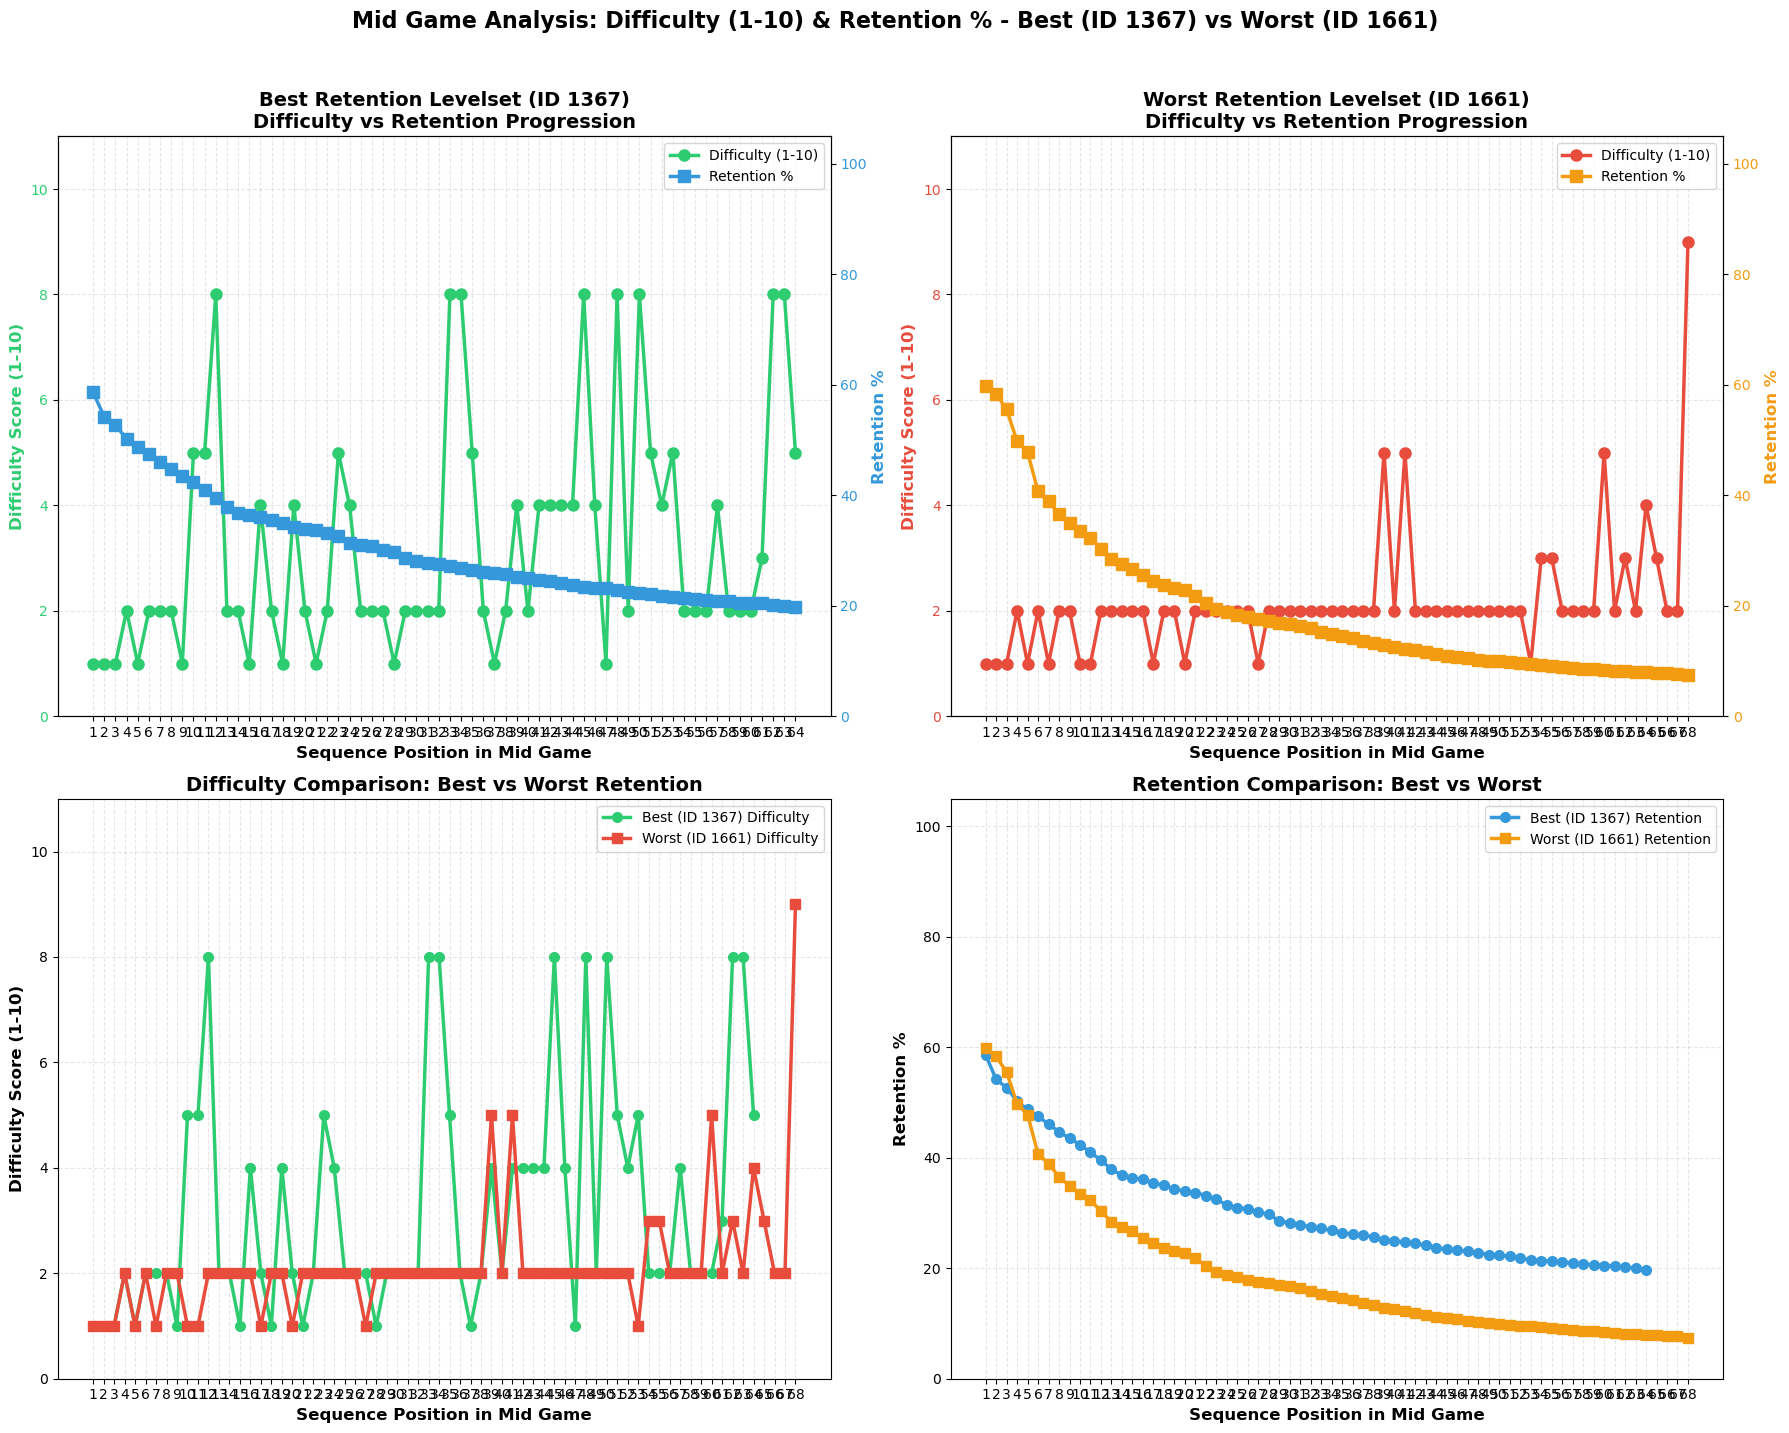


SPIKE ANALYSIS: Difficulty Increases vs Retention Changes

BEST Retention (ID 1367):
--------------------------------------------------------------------------------
  Seq 10 (Level 21): Difficulty ↑ +4 (from 1 to 5), Retention ↓ -1.2%
  Seq 12 (Level 23): Difficulty ↑ +3 (from 5 to 8), Retention ↓ -1.4%
  Seq 13 (Level 24): Difficulty ↓ -6 (from 8 to 2), Retention ↓ -1.7%
  Seq 16 (Level 27): Difficulty ↑ +3 (from 1 to 4), Retention ↓ -0.3%
  Seq 17 (Level 28): Difficulty ↓ -2 (from 4 to 2), Retention ↓ -0.7%
  Seq 19 (Level 30): Difficulty ↑ +3 (from 1 to 4), Retention ↓ -0.7%
  Seq 20 (Level 31): Difficulty ↓ -2 (from 4 to 2), Retention ↓ -0.3%
  Seq 23 (Level 34): Difficulty ↑ +3 (from 2 to 5), Retention ↓ -0.6%
  Seq 25 (Level 36): Difficulty ↓ -2 (from 4 to 2), Retention ↓ -0.4%
  Seq 33 (Level 44): Difficulty ↑ +6 (from 2 to 8), Retention ↓ -0.3%
  Seq 35 (Level 46): Difficulty ↓ -3 (from 8 to 5), Retention ↓ -0.4%
  Seq 36 (Level 47): Difficulty ↓ -3 (from 5 to 2), Retention ↓

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ------------------------------------------------------------
# 1. Re-run difficulty clustering with 10 clusters (1-10 scale)
# ------------------------------------------------------------
data = pd.read_csv('filled_dataset.csv')

def extract_level_features(level_data_str):
    try:
        words_info = json.loads(level_data_str)
    except:
        return {'word_count':0, 'total_letters':0, 'avg_word_length':0,
                'intersections':0, 'max_word_length':0, 'min_word_length':0}
    if not words_info:
        return {'word_count':0, 'total_letters':0, 'avg_word_length':0,
                'intersections':0, 'max_word_length':0, 'min_word_length':0}
    word_positions = []
    for w in words_info:
        word = w['Word']
        x, y = w['x'], w['y']
        is_horizontal = w.get('IsHorizontal', w.get('isHorizontal', True))
        length = len(word)
        positions = []
        for i in range(length):
            if is_horizontal:
                positions.append((x + i, y))
            else:
                positions.append((x, y + i))
        word_positions.append(positions)
    word_count = len(word_positions)
    word_lengths = [len(pos) for pos in word_positions]
    total_letters = sum(word_lengths)
    avg_word_length = total_letters / word_count if word_count else 0
    all_cells = {}
    for positions in word_positions:
        for pos in positions:
            all_cells[pos] = all_cells.get(pos, 0) + 1
    intersections = sum(1 for count in all_cells.values() if count >= 2)
    max_word_length = max(word_lengths) if word_lengths else 0
    min_word_length = min(word_lengths) if word_lengths else 0
    return {'word_count':word_count, 'total_letters':total_letters,
            'avg_word_length':avg_word_length, 'intersections':intersections,
            'max_word_length':max_word_length, 'min_word_length':min_word_length}

filtered_data = []
for levelset_id in data['Levelset_ID'].unique():
    ls_data = data[data['Levelset_ID'] == levelset_id].sort_values('level_no')
    ls_data = ls_data[ls_data['level_no'] <= 250]
    filtered_data.append(ls_data)
data_filtered = pd.concat(filtered_data, ignore_index=True)

features_df = data_filtered.copy()
extracted = features_df['level_data'].apply(extract_level_features)
features_df = pd.concat([features_df, pd.DataFrame(extracted.tolist())], axis=1)
features_df['seed_word_length'] = features_df['seed_word'].fillna('').astype(str).apply(len)

def clean_numeric(x):
    if isinstance(x, str):
        return float(x.replace(',', '.'))
    return float(x) if pd.notna(x) else 0.0

features_df['avg_hint'] = features_df['avg_hint'].apply(clean_numeric)
if 'sum_hint' in features_df.columns:
    features_df['sum_hint'] = features_df['sum_hint'].apply(clean_numeric)

feature_columns = ['avg_hint', 'board_count', 'dimx', 'dimy', 'word_count',
                   'avg_word_length', 'intersections', 'max_word_length', 'seed_word_length']
features_df[feature_columns] = features_df[feature_columns].fillna(0)
for col in feature_columns:
    features_df[col] = pd.to_numeric(features_df[col], errors='coerce').fillna(0)

X = features_df[feature_columns].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Use 10 clusters
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)
features_df['cluster'] = cluster_labels

centers_scaled = kmeans.cluster_centers_
centers = scaler.inverse_transform(centers_scaled)
centers_df = pd.DataFrame(centers, columns=feature_columns)

difficulty_features = ['avg_hint', 'board_count', 'word_count', 'intersections', 'dimx', 'dimy']
centers_df['difficulty_score'] = centers_df[difficulty_features].mean(axis=1)

# Order clusters by difficulty score and map to 1-10
cluster_order = centers_df['difficulty_score'].sort_values().index
difficulty_mapping = {cluster: i+1 for i, cluster in enumerate(cluster_order)}
features_df['difficulty_10'] = features_df['cluster'].map(difficulty_mapping)

# Calculate retention % for each level (same as before)
data['retention_pct'] = 0.0
for levelset_id in data['Levelset_ID'].unique():
    mask = data['Levelset_ID'] == levelset_id
    levelset_data = data[mask].sort_values('level_no')
    if len(levelset_data) > 0:
        initial_users = levelset_data.iloc[0]['total_users']
        data.loc[mask, 'retention_pct'] = (data.loc[mask, 'total_users'] / initial_users) * 100

# Merge retention into features_df
features_df = pd.merge(
    features_df,
    data[['Levelset_ID', 'level_no', 'retention_pct']],
    on=['Levelset_ID', 'level_no'],
    how='left'
)

# ------------------------------------------------------------
# 2. Merge with phase classification (assume data_classified exists)
# ------------------------------------------------------------
merged_df_10 = pd.merge(
    data_classified[['Levelset_ID', 'level_no', 'phase']],
    features_df[['Levelset_ID', 'level_no', 'difficulty_10', 'retention_pct']],
    on=['Levelset_ID', 'level_no'],
    how='inner'
)

# ------------------------------------------------------------
# 3. Extract Mid Game comparison for best (1367) and worst (1661)
# ------------------------------------------------------------
best_id = 1367
worst_id = 1661

best_mid = merged_df_10[(merged_df_10['Levelset_ID'] == best_id) & (merged_df_10['phase'] == 'Mid Game')].copy()
worst_mid = merged_df_10[(merged_df_10['Levelset_ID'] == worst_id) & (merged_df_10['phase'] == 'Mid Game')].copy()

best_mid = best_mid.sort_values('level_no').reset_index(drop=True)
worst_mid = worst_mid.sort_values('level_no').reset_index(drop=True)

best_mid['mid_seq'] = best_mid.index + 1
worst_mid['mid_seq'] = worst_mid.index + 1

# ------------------------------------------------------------
# 4. GRAPHS WITH BOTH DIFFICULTY AND RETENTION %
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Plot 1: Best Retention Levelset - Difficulty + Retention
ax1 = axes[0, 0]
ax1_twin = ax1.twinx()

# Difficulty line (left y-axis)
line1 = ax1.plot(best_mid['mid_seq'], best_mid['difficulty_10'], 
                  'o-', color='#2ECC71', linewidth=2.5, markersize=8, label='Difficulty (1-10)')
ax1.set_xlabel('Sequence Position in Mid Game', fontsize=12, fontweight='bold')
ax1.set_ylabel('Difficulty Score (1-10)', fontsize=12, fontweight='bold', color='#2ECC71')
ax1.tick_params(axis='y', labelcolor='#2ECC71')
ax1.set_ylim([0, 11])

# Retention line (right y-axis)
line2 = ax1_twin.plot(best_mid['mid_seq'], best_mid['retention_pct'], 
                       's-', color='#3498DB', linewidth=2.5, markersize=8, label='Retention %')
ax1_twin.set_ylabel('Retention %', fontsize=12, fontweight='bold', color='#3498DB')
ax1_twin.tick_params(axis='y', labelcolor='#3498DB')
ax1_twin.set_ylim([0, 105])

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right', fontsize=10)
ax1.set_title(f'Best Retention Levelset (ID {best_id})\nDifficulty vs Retention Progression', 
              fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xticks(best_mid['mid_seq'])

# Plot 2: Worst Retention Levelset - Difficulty + Retention
ax2 = axes[0, 1]
ax2_twin = ax2.twinx()

# Difficulty line (left y-axis)
line1 = ax2.plot(worst_mid['mid_seq'], worst_mid['difficulty_10'], 
                  'o-', color='#E74C3C', linewidth=2.5, markersize=8, label='Difficulty (1-10)')
ax2.set_xlabel('Sequence Position in Mid Game', fontsize=12, fontweight='bold')
ax2.set_ylabel('Difficulty Score (1-10)', fontsize=12, fontweight='bold', color='#E74C3C')
ax2.tick_params(axis='y', labelcolor='#E74C3C')
ax2.set_ylim([0, 11])

# Retention line (right y-axis)
line2 = ax2_twin.plot(worst_mid['mid_seq'], worst_mid['retention_pct'], 
                       's-', color='#F39C12', linewidth=2.5, markersize=8, label='Retention %')
ax2_twin.set_ylabel('Retention %', fontsize=12, fontweight='bold', color='#F39C12')
ax2_twin.tick_params(axis='y', labelcolor='#F39C12')
ax2_twin.set_ylim([0, 105])

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc='upper right', fontsize=10)
ax2.set_title(f'Worst Retention Levelset (ID {worst_id})\nDifficulty vs Retention Progression', 
              fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xticks(worst_mid['mid_seq'])

# Plot 3: Overlay Comparison - Difficulty
ax3 = axes[1, 0]
ax3.plot(best_mid['mid_seq'], best_mid['difficulty_10'], 
         'o-', color='#2ECC71', linewidth=2.5, markersize=7, label=f'Best (ID {best_id}) Difficulty')
ax3.plot(worst_mid['mid_seq'], worst_mid['difficulty_10'], 
         's-', color='#E74C3C', linewidth=2.5, markersize=7, label=f'Worst (ID {worst_id}) Difficulty')
ax3.set_xlabel('Sequence Position in Mid Game', fontsize=12, fontweight='bold')
ax3.set_ylabel('Difficulty Score (1-10)', fontsize=12, fontweight='bold')
ax3.set_title('Difficulty Comparison: Best vs Worst Retention', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_ylim([0, 11])
ax3.set_xticks(sorted(set(best_mid['mid_seq'].tolist() + worst_mid['mid_seq'].tolist())))

# Plot 4: Overlay Comparison - Retention %
ax4 = axes[1, 1]
ax4.plot(best_mid['mid_seq'], best_mid['retention_pct'], 
         'o-', color='#3498DB', linewidth=2.5, markersize=7, label=f'Best (ID {best_id}) Retention')
ax4.plot(worst_mid['mid_seq'], worst_mid['retention_pct'], 
         's-', color='#F39C12', linewidth=2.5, markersize=7, label=f'Worst (ID {worst_id}) Retention')
ax4.set_xlabel('Sequence Position in Mid Game', fontsize=12, fontweight='bold')
ax4.set_ylabel('Retention %', fontsize=12, fontweight='bold')
ax4.set_title('Retention Comparison: Best vs Worst', fontsize=14, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.set_ylim([0, 105])
ax4.set_xticks(sorted(set(best_mid['mid_seq'].tolist() + worst_mid['mid_seq'].tolist())))

plt.suptitle(f'Mid Game Analysis: Difficulty (1-10) & Retention % - Best (ID {best_id}) vs Worst (ID {worst_id})', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. Detailed spike analysis - Identify where difficulty increases and retention drops
# ------------------------------------------------------------
print("\n" + "=" * 100)
print("SPIKE ANALYSIS: Difficulty Increases vs Retention Changes")
print("=" * 100)

def analyze_spikes(df, levelset_name, levelset_id):
    print(f"\n{levelset_name} (ID {levelset_id}):")
    print("-" * 80)
    
    for i in range(1, len(df)):
        diff_change = df.iloc[i]['difficulty_10'] - df.iloc[i-1]['difficulty_10']
        ret_change = df.iloc[i]['retention_pct'] - df.iloc[i-1]['retention_pct']
        
        if diff_change >= 2:  # Significant difficulty spike (increase of 2+ points)
            print(f"  Seq {df.iloc[i]['mid_seq']:2d} (Level {df.iloc[i]['level_no']:.0f}): "
                  f"Difficulty ↑ {diff_change:+.0f} (from {df.iloc[i-1]['difficulty_10']:.0f} to {df.iloc[i]['difficulty_10']:.0f}), "
                  f"Retention {'↓' if ret_change < 0 else '↑'} {ret_change:+.1f}%")
        elif diff_change <= -2:  # Significant difficulty drop
            print(f"  Seq {df.iloc[i]['mid_seq']:2d} (Level {df.iloc[i]['level_no']:.0f}): "
                  f"Difficulty ↓ {diff_change:+.0f} (from {df.iloc[i-1]['difficulty_10']:.0f} to {df.iloc[i]['difficulty_10']:.0f}), "
                  f"Retention {'↓' if ret_change < 0 else '↑'} {ret_change:+.1f}%")

analyze_spikes(best_mid, "BEST Retention", best_id)
analyze_spikes(worst_mid, "WORST Retention", worst_id)

# ------------------------------------------------------------
# 6. Correlation between difficulty and retention in Mid Game
# ------------------------------------------------------------
print("\n" + "=" * 100)
print("CORRELATION: Difficulty vs Retention in Mid Game")
print("=" * 100)

best_corr = best_mid['difficulty_10'].corr(best_mid['retention_pct'])
worst_corr = worst_mid['difficulty_10'].corr(worst_mid['retention_pct'])

print(f"\nBest Retention (ID {best_id}):")
print(f"  Correlation coefficient: {best_corr:.3f}")
print(f"  Interpretation: ", end="")
if best_corr < -0.5:
    print("Strong negative - higher difficulty → lower retention")
elif best_corr < -0.3:
    print("Moderate negative - difficulty somewhat reduces retention")
elif best_corr < 0:
    print("Weak negative - slight tendency for difficulty to reduce retention")
else:
    print("No clear negative relationship")

print(f"\nWorst Retention (ID {worst_id}):")
print(f"  Correlation coefficient: {worst_corr:.3f}")
print(f"  Interpretation: ", end="")
if worst_corr < -0.5:
    print("Strong negative - higher difficulty → lower retention")
elif worst_corr < -0.3:
    print("Moderate negative - difficulty somewhat reduces retention")
elif worst_corr < 0:
    print("Weak negative - slight tendency for difficulty to reduce retention")
else:
    print("No clear negative relationship")

# ------------------------------------------------------------
# 7. Display the data table with both difficulty and retention
# ------------------------------------------------------------
print("\n" + "=" * 100)
print(f"COMPLETE MID GAME DATA: BEST ({best_id}) - Difficulty & Retention %")
print("=" * 100)
best_display = best_mid[['mid_seq', 'level_no', 'difficulty_10', 'retention_pct']].copy()
best_display.columns = ['Seq', 'Level', 'Difficulty (1-10)', 'Retention %']
print(best_display.to_string(index=False))

print("\n" + "=" * 100)
print(f"COMPLETE MID GAME DATA: WORST ({worst_id}) - Difficulty & Retention %")
print("=" * 100)
worst_display = worst_mid[['mid_seq', 'level_no', 'difficulty_10', 'retention_pct']].copy()
worst_display.columns = ['Seq', 'Level', 'Difficulty (1-10)', 'Retention %']
print(worst_display.to_string(index=False))

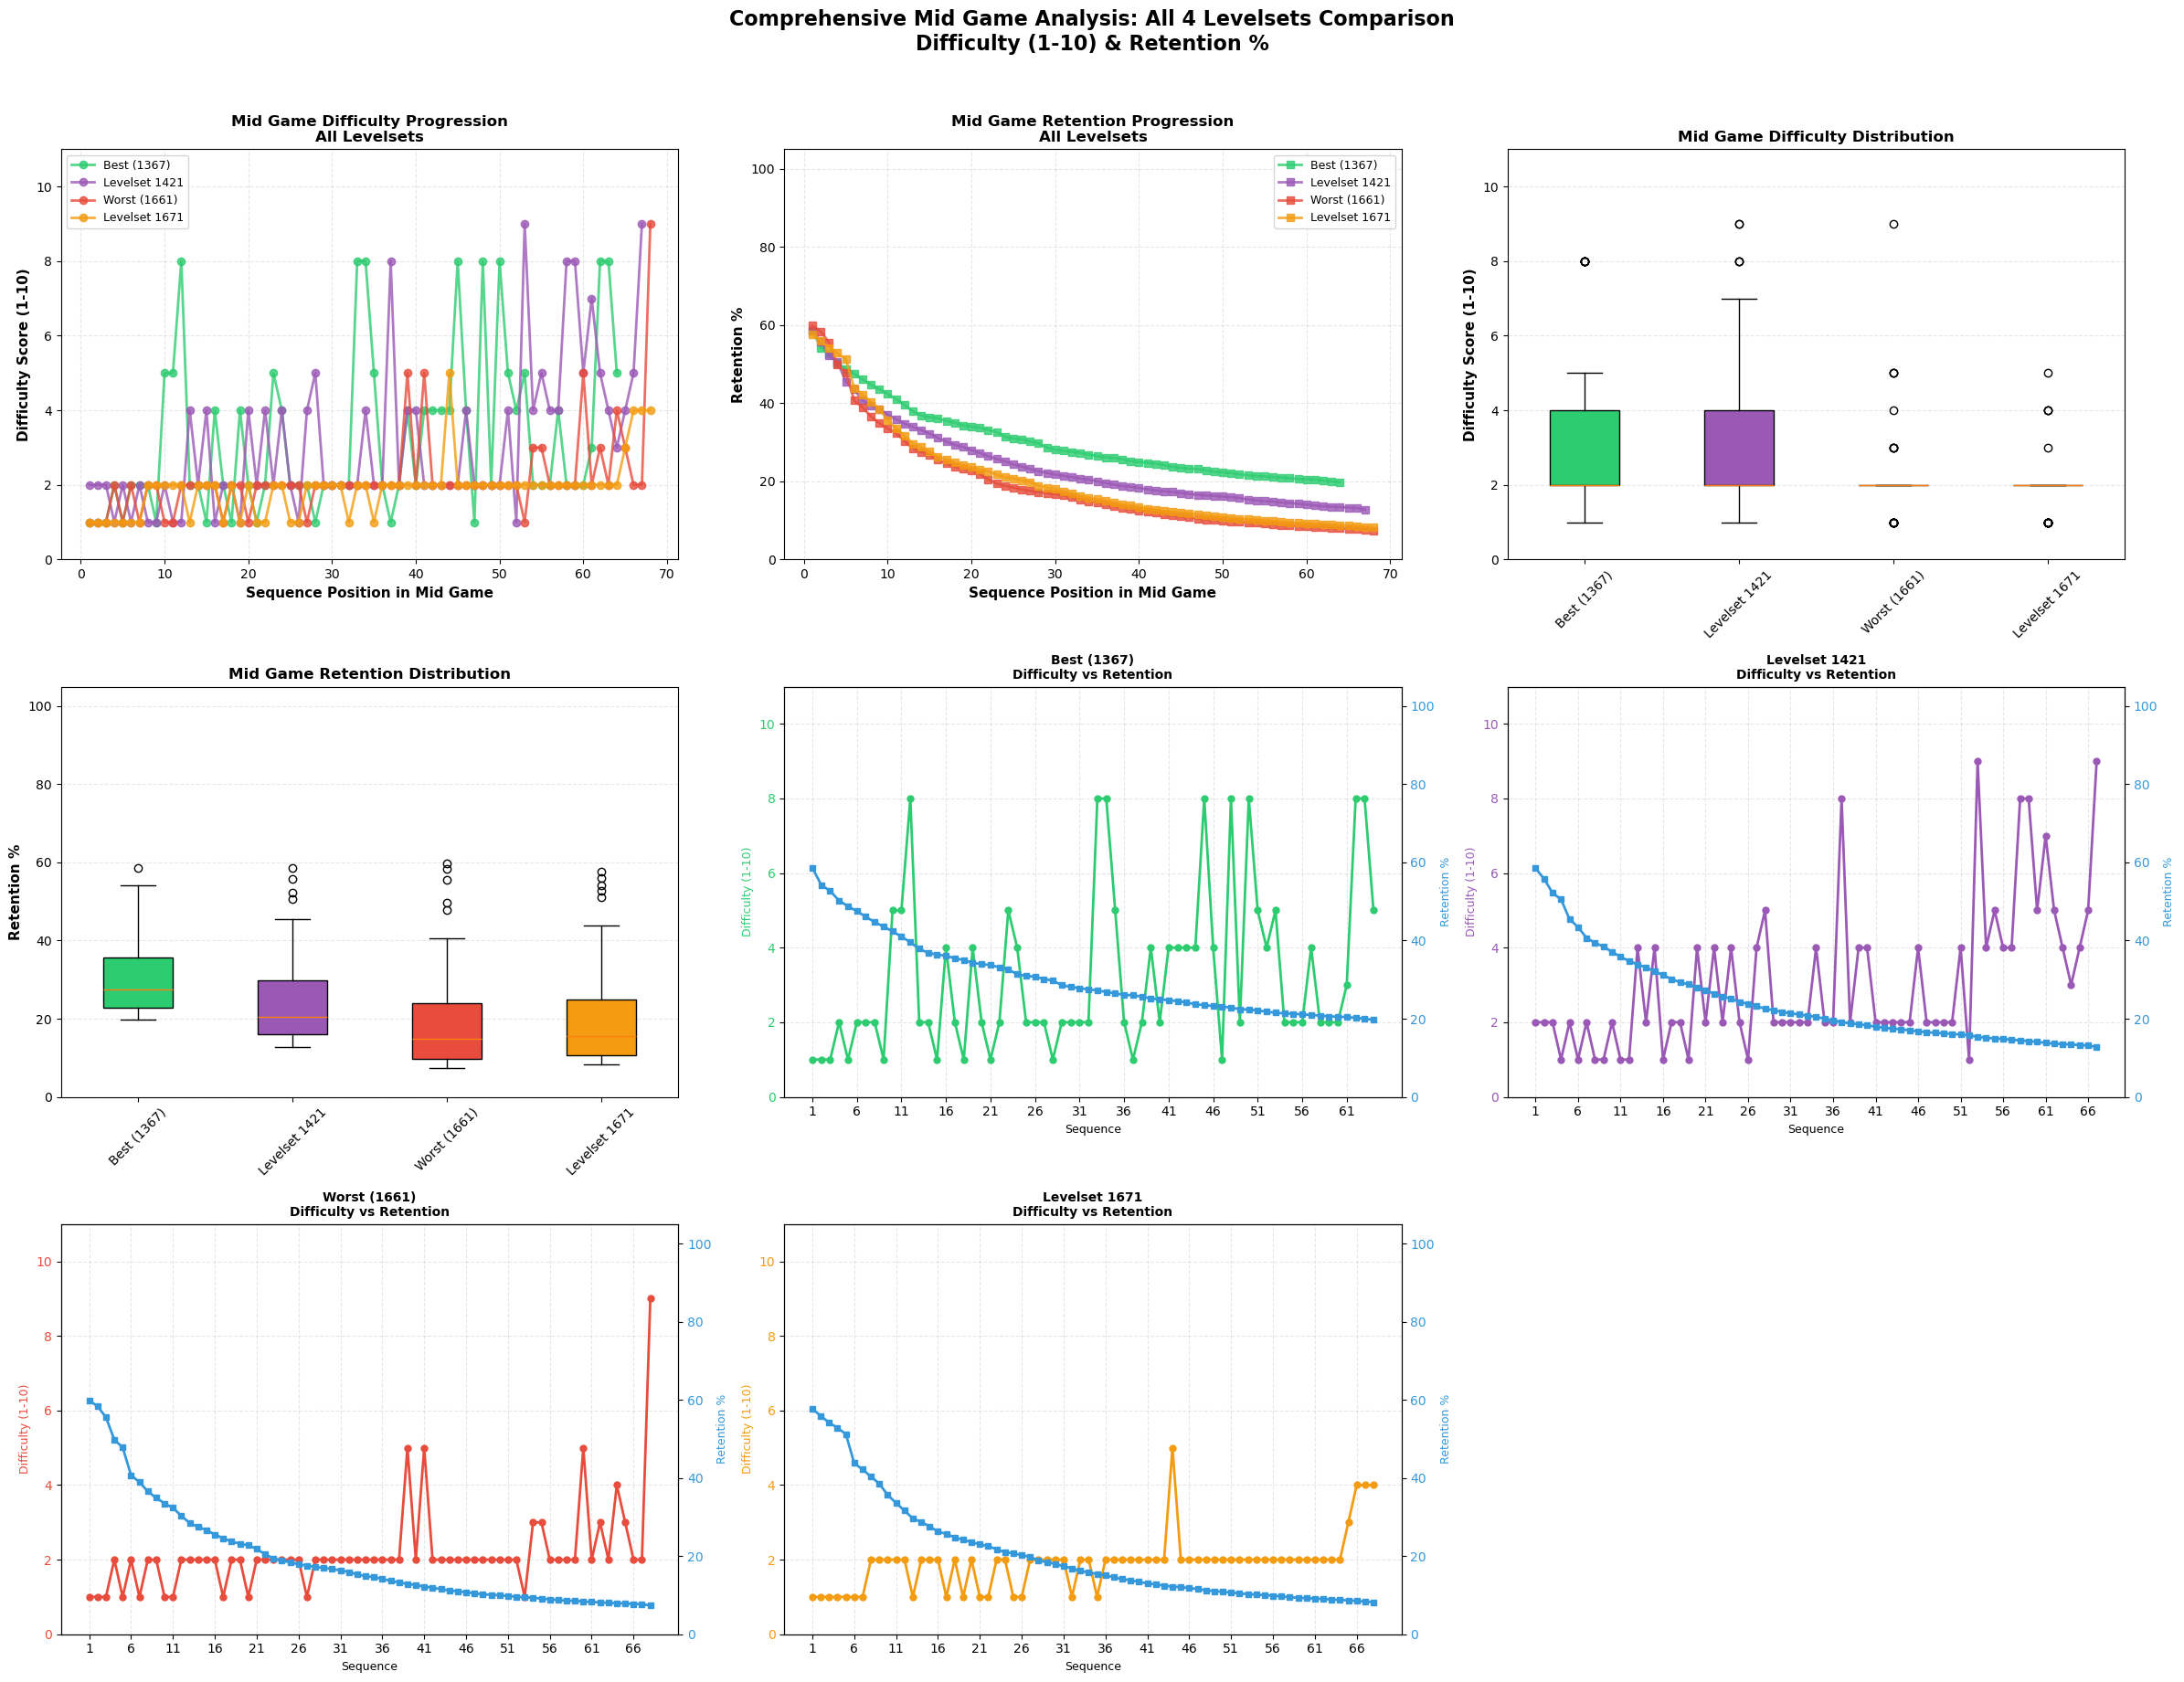


STATISTICAL COMPARISON: Best (1367) vs All Other Levelsets - Mid Game

Best (1367) vs Levelset 1421

DIFFICULTY:
  Best (1367):      Mean = 3.27, Std = 2.20
  Levelset 1421:   Mean = 3.12, Std = 2.01
  t-test: t = 0.397, p = 0.6923
  Mann-Whitney U: p = 0.8755
  → No significant difference in difficulty

RETENTION:
  Best (1367):      Mean = 30.6%
  Levelset 1421:   Mean = 24.4%
  t-test: t = 3.359, p = 0.0010
  → Best has SIGNIFICANTLY HIGHER retention

DIFFICULTY-RETENTION CORRELATION:
  Best (1367):      r = -0.356
  Levelset 1421:   r = -0.471

Best (1367) vs Levelset 1661

DIFFICULTY:
  Best (1367):      Mean = 3.27, Std = 2.20
  Levelset 1661:   Mean = 2.16, Std = 1.18
  t-test: t = 3.563, p = 0.0006
  Mann-Whitney U: p = 0.0058
  → Best is SIGNIFICANTLY HARDER in Mid Game

RETENTION:
  Best (1367):      Mean = 30.6%
  Levelset 1661:   Mean = 19.3%
  t-test: t = 5.603, p = 0.0000
  → Best has SIGNIFICANTLY HIGHER retention

DIFFICULTY-RETENTION CORRELATION:
  Best (1367):      r

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy import stats

# ------------------------------------------------------------
# 1. Re-run difficulty clustering with 10 clusters (1-10 scale)
# ------------------------------------------------------------
data = pd.read_csv('filled_dataset.csv')

def extract_level_features(level_data_str):
    try:
        words_info = json.loads(level_data_str)
    except:
        return {'word_count':0, 'total_letters':0, 'avg_word_length':0,
                'intersections':0, 'max_word_length':0, 'min_word_length':0}
    if not words_info:
        return {'word_count':0, 'total_letters':0, 'avg_word_length':0,
                'intersections':0, 'max_word_length':0, 'min_word_length':0}
    word_positions = []
    for w in words_info:
        word = w['Word']
        x, y = w['x'], w['y']
        is_horizontal = w.get('IsHorizontal', w.get('isHorizontal', True))
        length = len(word)
        positions = []
        for i in range(length):
            if is_horizontal:
                positions.append((x + i, y))
            else:
                positions.append((x, y + i))
        word_positions.append(positions)
    word_count = len(word_positions)
    word_lengths = [len(pos) for pos in word_positions]
    total_letters = sum(word_lengths)
    avg_word_length = total_letters / word_count if word_count else 0
    all_cells = {}
    for positions in word_positions:
        for pos in positions:
            all_cells[pos] = all_cells.get(pos, 0) + 1
    intersections = sum(1 for count in all_cells.values() if count >= 2)
    max_word_length = max(word_lengths) if word_lengths else 0
    min_word_length = min(word_lengths) if word_lengths else 0
    return {'word_count':word_count, 'total_letters':total_letters,
            'avg_word_length':avg_word_length, 'intersections':intersections,
            'max_word_length':max_word_length, 'min_word_length':min_word_length}

filtered_data = []
for levelset_id in data['Levelset_ID'].unique():
    ls_data = data[data['Levelset_ID'] == levelset_id].sort_values('level_no')
    ls_data = ls_data[ls_data['level_no'] <= 250]
    filtered_data.append(ls_data)
data_filtered = pd.concat(filtered_data, ignore_index=True)

features_df = data_filtered.copy()
extracted = features_df['level_data'].apply(extract_level_features)
features_df = pd.concat([features_df, pd.DataFrame(extracted.tolist())], axis=1)
features_df['seed_word_length'] = features_df['seed_word'].fillna('').astype(str).apply(len)

def clean_numeric(x):
    if isinstance(x, str):
        return float(x.replace(',', '.'))
    return float(x) if pd.notna(x) else 0.0

features_df['avg_hint'] = features_df['avg_hint'].apply(clean_numeric)
if 'sum_hint' in features_df.columns:
    features_df['sum_hint'] = features_df['sum_hint'].apply(clean_numeric)

feature_columns = ['avg_hint', 'board_count', 'dimx', 'dimy', 'word_count',
                   'avg_word_length', 'intersections', 'max_word_length', 'seed_word_length']
features_df[feature_columns] = features_df[feature_columns].fillna(0)
for col in feature_columns:
    features_df[col] = pd.to_numeric(features_df[col], errors='coerce').fillna(0)

X = features_df[feature_columns].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Use 10 clusters
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)
features_df['cluster'] = cluster_labels

centers_scaled = kmeans.cluster_centers_
centers = scaler.inverse_transform(centers_scaled)
centers_df = pd.DataFrame(centers, columns=feature_columns)

difficulty_features = ['avg_hint', 'board_count', 'word_count', 'intersections', 'dimx', 'dimy']
centers_df['difficulty_score'] = centers_df[difficulty_features].mean(axis=1)

# Order clusters by difficulty score and map to 1-10
cluster_order = centers_df['difficulty_score'].sort_values().index
difficulty_mapping = {cluster: i+1 for i, cluster in enumerate(cluster_order)}
features_df['difficulty_10'] = features_df['cluster'].map(difficulty_mapping)

# Calculate retention % for each level
data['retention_pct'] = 0.0
for levelset_id in data['Levelset_ID'].unique():
    mask = data['Levelset_ID'] == levelset_id
    levelset_data = data[mask].sort_values('level_no')
    if len(levelset_data) > 0:
        initial_users = levelset_data.iloc[0]['total_users']
        data.loc[mask, 'retention_pct'] = (data.loc[mask, 'total_users'] / initial_users) * 100

# Merge retention into features_df
features_df = pd.merge(
    features_df,
    data[['Levelset_ID', 'level_no', 'retention_pct']],
    on=['Levelset_ID', 'level_no'],
    how='left'
)

# ------------------------------------------------------------
# 2. Merge with phase classification
# ------------------------------------------------------------
merged_df_10 = pd.merge(
    data_classified[['Levelset_ID', 'level_no', 'phase']],
    features_df[['Levelset_ID', 'level_no', 'difficulty_10', 'retention_pct']],
    on=['Levelset_ID', 'level_no'],
    how='inner'
)

# ------------------------------------------------------------
# 3. Extract Mid Game data for ALL levelsets
# ------------------------------------------------------------
all_levelsets = [1367, 1421, 1661, 1671]
levelset_colors = {
    1367: '#2ECC71',  # Green - Best
    1421: '#9B59B6',  # Purple
    1661: '#E74C3C',  # Red - Worst
    1671: '#F39C12'   # Orange
}
levelset_labels = {
    1367: 'Best (1367)',
    1421: 'Levelset 1421',
    1661: 'Worst (1661)',
    1671: 'Levelset 1671'
}

midgame_data = {}
for ls_id in all_levelsets:
    ls_mid = merged_df_10[(merged_df_10['Levelset_ID'] == ls_id) & 
                          (merged_df_10['phase'] == 'Mid Game')].copy()
    ls_mid = ls_mid.sort_values('level_no').reset_index(drop=True)
    ls_mid['mid_seq'] = ls_mid.index + 1
    midgame_data[ls_id] = ls_mid

# ------------------------------------------------------------
# 4. COMPREHENSIVE VISUALIZATIONS - All 4 Levelsets
# ------------------------------------------------------------
fig = plt.figure(figsize=(24, 18))

# Plot 1: All levelsets - Difficulty progression
ax1 = plt.subplot(3, 3, 1)
for ls_id in all_levelsets:
    ls_data = midgame_data[ls_id]
    ax1.plot(ls_data['mid_seq'], ls_data['difficulty_10'], 
             'o-', color=levelset_colors[ls_id], linewidth=2, markersize=6, 
             label=levelset_labels[ls_id], alpha=0.8)
ax1.set_xlabel('Sequence Position in Mid Game', fontsize=11, fontweight='bold')
ax1.set_ylabel('Difficulty Score (1-10)', fontsize=11, fontweight='bold')
ax1.set_title('Mid Game Difficulty Progression\nAll Levelsets', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_ylim([0, 11])

# Plot 2: All levelsets - Retention progression
ax2 = plt.subplot(3, 3, 2)
for ls_id in all_levelsets:
    ls_data = midgame_data[ls_id]
    ax2.plot(ls_data['mid_seq'], ls_data['retention_pct'], 
             's-', color=levelset_colors[ls_id], linewidth=2, markersize=6, 
             label=levelset_labels[ls_id], alpha=0.8)
ax2.set_xlabel('Sequence Position in Mid Game', fontsize=11, fontweight='bold')
ax2.set_ylabel('Retention %', fontsize=11, fontweight='bold')
ax2.set_title('Mid Game Retention Progression\nAll Levelsets', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_ylim([0, 105])

# Plot 3: Difficulty Box Plot Comparison
ax3 = plt.subplot(3, 3, 3)
box_data = [midgame_data[ls_id]['difficulty_10'].values for ls_id in all_levelsets]
bp = ax3.boxplot(box_data, labels=[levelset_labels[ls_id] for ls_id in all_levelsets], 
                  patch_artist=True)
for patch, ls_id in zip(bp['boxes'], all_levelsets):
    patch.set_facecolor(levelset_colors[ls_id])
ax3.set_ylabel('Difficulty Score (1-10)', fontsize=11, fontweight='bold')
ax3.set_title('Mid Game Difficulty Distribution', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, linestyle='--', axis='y')
ax3.tick_params(axis='x', rotation=45)
ax3.set_ylim([0, 11])

# Plot 4: Retention Box Plot Comparison
ax4 = plt.subplot(3, 3, 4)
box_data = [midgame_data[ls_id]['retention_pct'].values for ls_id in all_levelsets]
bp = ax4.boxplot(box_data, labels=[levelset_labels[ls_id] for ls_id in all_levelsets], 
                  patch_artist=True)
for patch, ls_id in zip(bp['boxes'], all_levelsets):
    patch.set_facecolor(levelset_colors[ls_id])
ax4.set_ylabel('Retention %', fontsize=11, fontweight='bold')
ax4.set_title('Mid Game Retention Distribution', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, linestyle='--', axis='y')
ax4.tick_params(axis='x', rotation=45)
ax4.set_ylim([0, 105])

# Plot 5: Individual subplots for each levelset - Difficulty + Retention
for idx, ls_id in enumerate(all_levelsets):
    ax = plt.subplot(3, 3, 5 + idx)
    ax_twin = ax.twinx()
    ls_data = midgame_data[ls_id]
    
    # Difficulty
    line1 = ax.plot(ls_data['mid_seq'], ls_data['difficulty_10'], 
                     'o-', color=levelset_colors[ls_id], linewidth=2, markersize=5, 
                     label='Difficulty')
    ax.set_xlabel('Sequence', fontsize=9)
    ax.set_ylabel('Difficulty (1-10)', fontsize=9, color=levelset_colors[ls_id])
    ax.tick_params(axis='y', labelcolor=levelset_colors[ls_id])
    ax.set_ylim([0, 11])
    
    # Retention
    line2 = ax_twin.plot(ls_data['mid_seq'], ls_data['retention_pct'], 
                          's-', color='#3498DB', linewidth=2, markersize=5, 
                          label='Retention %')
    ax_twin.set_ylabel('Retention %', fontsize=9, color='#3498DB')
    ax_twin.tick_params(axis='y', labelcolor='#3498DB')
    ax_twin.set_ylim([0, 105])
    
    ax.set_title(f'{levelset_labels[ls_id]}\nDifficulty vs Retention', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xticks(ls_data['mid_seq'][::5])

plt.suptitle('Comprehensive Mid Game Analysis: All 4 Levelsets Comparison\nDifficulty (1-10) & Retention %', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. Statistical Comparison: Best vs Each Other Levelset
# ------------------------------------------------------------
print("\n" + "=" * 100)
print("STATISTICAL COMPARISON: Best (1367) vs All Other Levelsets - Mid Game")
print("=" * 100)

best_id = 1367
best_data = midgame_data[best_id]

for other_id in [1421, 1661, 1671]:
    other_data = midgame_data[other_id]
    
    print(f"\n{'='*50}")
    print(f"Best ({best_id}) vs Levelset {other_id}")
    print(f"{'='*50}")
    
    # Difficulty comparison
    t_stat_diff, p_value_diff = stats.ttest_ind(best_data['difficulty_10'], 
                                                 other_data['difficulty_10'], 
                                                 equal_var=False)
    u_stat_diff, mw_p_diff = stats.mannwhitneyu(best_data['difficulty_10'], 
                                                 other_data['difficulty_10'], 
                                                 alternative='two-sided')
    
    print(f"\nDIFFICULTY:")
    print(f"  Best ({best_id}):      Mean = {best_data['difficulty_10'].mean():.2f}, Std = {best_data['difficulty_10'].std():.2f}")
    print(f"  Levelset {other_id}:   Mean = {other_data['difficulty_10'].mean():.2f}, Std = {other_data['difficulty_10'].std():.2f}")
    print(f"  t-test: t = {t_stat_diff:.3f}, p = {p_value_diff:.4f}")
    print(f"  Mann-Whitney U: p = {mw_p_diff:.4f}")
    if p_value_diff < 0.05:
        if best_data['difficulty_10'].mean() > other_data['difficulty_10'].mean():
            print(f"  → Best is SIGNIFICANTLY HARDER in Mid Game")
        else:
            print(f"  → Best is SIGNIFICANTLY EASIER in Mid Game")
    else:
        print(f"  → No significant difference in difficulty")
    
    # Retention comparison
    t_stat_ret, p_value_ret = stats.ttest_ind(best_data['retention_pct'], 
                                               other_data['retention_pct'], 
                                               equal_var=False)
    
    print(f"\nRETENTION:")
    print(f"  Best ({best_id}):      Mean = {best_data['retention_pct'].mean():.1f}%")
    print(f"  Levelset {other_id}:   Mean = {other_data['retention_pct'].mean():.1f}%")
    print(f"  t-test: t = {t_stat_ret:.3f}, p = {p_value_ret:.4f}")
    if p_value_ret < 0.05:
        if best_data['retention_pct'].mean() > other_data['retention_pct'].mean():
            print(f"  → Best has SIGNIFICANTLY HIGHER retention")
        else:
            print(f"  → Best has SIGNIFICANTLY LOWER retention")
    else:
        print(f"  → No significant difference in retention")
    
    # Correlation comparison
    best_corr = best_data['difficulty_10'].corr(best_data['retention_pct'])
    other_corr = other_data['difficulty_10'].corr(other_data['retention_pct'])
    print(f"\nDIFFICULTY-RETENTION CORRELATION:")
    print(f"  Best ({best_id}):      r = {best_corr:.3f}")
    print(f"  Levelset {other_id}:   r = {other_corr:.3f}")

# ------------------------------------------------------------
# 6. Summary Table
# ------------------------------------------------------------
print("\n" + "=" * 100)
print("SUMMARY TABLE - Mid Game Metrics for All Levelsets")
print("=" * 100)

summary_data = []
for ls_id in all_levelsets:
    ls_data = midgame_data[ls_id]
    summary_data.append({
        'Levelset': ls_id,
        'Label': levelset_labels[ls_id],
        'N_Levels': len(ls_data),
        'Diff_Mean': ls_data['difficulty_10'].mean(),
        'Diff_Std': ls_data['difficulty_10'].std(),
        'Diff_Min': ls_data['difficulty_10'].min(),
        'Diff_Max': ls_data['difficulty_10'].max(),
        'Ret_Mean': ls_data['retention_pct'].mean(),
        'Ret_Std': ls_data['retention_pct'].std(),
        'Ret_Min': ls_data['retention_pct'].min(),
        'Ret_Max': ls_data['retention_pct'].max(),
        'Correlation': ls_data['difficulty_10'].corr(ls_data['retention_pct'])
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('Ret_Mean', ascending=False)
print(summary_df.round(3).to_string(index=False))

# ------------------------------------------------------------
# 7. Difficulty Pattern Analysis for Each Levelset
# ------------------------------------------------------------
print("\n" + "=" * 100)
print("DIFFICULTY PATTERN ANALYSIS - How Mid Game Starts and Progresses")
print("=" * 100)

for ls_id in all_levelsets:
    ls_data = midgame_data[ls_id]
    first_5 = ls_data.head(5)['difficulty_10'].mean()
    last_5 = ls_data.tail(5)['difficulty_10'].mean()
    trend = "Increasing" if last_5 > first_5 + 0.5 else "Decreasing" if last_5 < first_5 - 0.5 else "Stable"
    
    print(f"\n{levelset_labels[ls_id]}:")
    print(f"  Starts with difficulty: {first_5:.2f} (avg of first 5 levels)")
    print(f"  Ends with difficulty:   {last_5:.2f} (avg of last 5 levels)")
    print(f"  Overall trend: {trend}")
    print(f"  Difficulty spikes (≥2 point increase): ", end="")
    spikes = []
    for i in range(1, len(ls_data)):
        if ls_data.iloc[i]['difficulty_10'] - ls_data.iloc[i-1]['difficulty_10'] >= 2:
            spikes.append(f"Seq {ls_data.iloc[i]['mid_seq']} (+{ls_data.iloc[i]['difficulty_10'] - ls_data.iloc[i-1]['difficulty_10']:.0f})")
    if spikes:
        print(", ".join(spikes))
    else:
        print("None")

# ------------------------------------------------------------
# 8. Ranking of Levelsets by Mid Game Performance
# ------------------------------------------------------------
print("\n" + "=" * 100)
print("RANKING: Levelsets by Mid Game Performance")
print("=" * 100)

rankings = summary_df.copy()
rankings['Retention_Rank'] = rankings['Ret_Mean'].rank(ascending=False).astype(int)
rankings['Difficulty_Rank'] = rankings['Diff_Mean'].rank(ascending=True).astype(int)
rankings['Consistency_Rank'] = rankings['Diff_Std'].rank(ascending=True).astype(int)

print("\nRetention Ranking (Higher is Better):")
for _, row in rankings.sort_values('Retention_Rank').iterrows():
    print(f"  {row['Retention_Rank']}. Levelset {row['Levelset']}: {row['Ret_Mean']:.1f}% retention")

print("\nDifficulty Ranking (Lower is Easier):")
for _, row in rankings.sort_values('Difficulty_Rank').iterrows():
    print(f"  {row['Difficulty_Rank']}. Levelset {row['Levelset']}: {row['Diff_Mean']:.2f} difficulty")

print("\nConsistency Ranking (Lower Std Dev = More Consistent Difficulty):")
for _, row in rankings.sort_values('Consistency_Rank').iterrows():
    print(f"  {row['Consistency_Rank']}. Levelset {row['Levelset']}: std = {row['Diff_Std']:.2f}")

### Repeated Word Analysis 

In [13]:
import pandas as pd
import numpy as np
import json
from scipy import stats

# Load data
data = pd.read_csv('filled_dataset.csv')

# Sort by levelset and level
data = data.sort_values(['Levelset_ID', 'level_no']).reset_index(drop=True)

# Function to extract list of words from level_data JSON
def extract_words(level_data_str):
    try:
        words_info = json.loads(level_data_str)
        return [w['Word'] for w in words_info]
    except:
        return []

# Precompute words for all rows (to speed up repeated lookups)
data['words_list'] = data['level_data'].apply(extract_words)

# We'll process per levelset
results = []
churn_data_all = []  # store (levelset, churn, repeated) for overall analysis

for levelset_id, group in data.groupby('Levelset_ID'):
    # ensure sorted by level
    group = group.sort_values('level_no')
    
    # compute churn: percentage drop from previous level
    # for first level, churn is NaN
    group['churn'] = group['total_users'].pct_change() * (-100)  # negative pct_change * -100 = drop percentage
    # pct_change = (t - t-1)/t-1, so negative when drop. Multiplying by -100 gives positive drop percentage
    # This matches: churn = (prev - curr) / prev * 100
    
    # For first level, churn will be NaN, we can ignore later.
    
    # Compute repeated word flag: any word in current level appears in any of last 10 levels
    repeated_flags = []
    words_history = []  # list of sets of words from previous levels (up to 10)
    
    for idx, row in group.iterrows():
        current_words = set(row['words_list'])
        # check against history (last 10 levels)
        if len(words_history) > 0:
            repeated = any(current_words & past_words for past_words in words_history)
            repeated_flags.append(1 if repeated else 0)
        else:
            # first level of levelset, no history
            repeated_flags.append(0)
        
        # update history: add current words to front, keep only last 10
        words_history.insert(0, current_words)
        if len(words_history) > 10:
            words_history.pop()
    
    group['repeated_word'] = repeated_flags
    
    # Collect data for analysis: exclude first row where churn is NaN
    valid = group.dropna(subset=['churn'])
    # Also, technically repeated_word is defined for all but churn is NaN for first, so ignore
    levelset_results = {
        'Levelset_ID': levelset_id,
        'num_levels_analyzed': len(valid),
        'num_repeated': (valid['repeated_word'] == 1).sum(),
        'num_not_repeated': (valid['repeated_word'] == 0).sum(),
        'avg_churn_repeated': valid[valid['repeated_word'] == 1]['churn'].mean(),
        'avg_churn_not_repeated': valid[valid['repeated_word'] == 0]['churn'].mean(),
        'churn_diff': valid[valid['repeated_word'] == 1]['churn'].mean() - valid[valid['repeated_word'] == 0]['churn'].mean()
    }
    
    # Perform t-test if both groups have at least 2 elements
    if levelset_results['num_repeated'] >= 2 and levelset_results['num_not_repeated'] >= 2:
        t_stat, p_value = stats.ttest_ind(
            valid[valid['repeated_word'] == 1]['churn'],
            valid[valid['repeated_word'] == 0]['churn'],
            equal_var=False
        )
        levelset_results['t_stat'] = t_stat
        levelset_results['p_value'] = p_value
    else:
        levelset_results['t_stat'] = np.nan
        levelset_results['p_value'] = np.nan
    
    results.append(levelset_results)
    
    # Store for overall analysis
    valid['Levelset_ID'] = levelset_id
    churn_data_all.append(valid[['Levelset_ID', 'churn', 'repeated_word']])

# Print per-levelset results
print("Per-Levelset Analysis: Effect of Repeated Words on Churn")
print("=" * 80)
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Overall aggregation
all_data = pd.concat(churn_data_all, ignore_index=True)
print("\n" + "=" * 80)
print("Overall Aggregation (All Levelsets Combined)")
print("=" * 80)
repeated_churn = all_data[all_data['repeated_word'] == 1]['churn']
not_repeated_churn = all_data[all_data['repeated_word'] == 0]['churn']

print(f"Number of levels with repeated words: {len(repeated_churn)}")
print(f"Number of levels without repeated words: {len(not_repeated_churn)}")
print(f"Average churn when repeated words present: {repeated_churn.mean():.2f}%")
print(f"Average churn when no repeated words:     {not_repeated_churn.mean():.2f}%")
print(f"Difference (repeated - not repeated): {repeated_churn.mean() - not_repeated_churn.mean():.2f}%")

# T-test overall
t_stat, p_val = stats.ttest_ind(repeated_churn, not_repeated_churn, equal_var=False)
print(f"\nT-test: t = {t_stat:.3f}, p = {p_val:.4f}")
if p_val < 0.05:
    print("→ Significant difference: repeated words are associated with a change in churn.")
else:
    print("→ No significant difference in churn based on word repetition (p >= 0.05).")

# Also show median and distribution info
print(f"\nMedian churn with repeated words: {repeated_churn.median():.2f}%")
print(f"Median churn without repeated words: {not_repeated_churn.median():.2f}%")

Per-Levelset Analysis: Effect of Repeated Words on Churn
 Levelset_ID  num_levels_analyzed  num_repeated  num_not_repeated  avg_churn_repeated  avg_churn_not_repeated  churn_diff    t_stat      p_value
        1367                 1999          1274               725            0.157851                0.393749   -0.235898 -5.711830 1.491133e-08
        1421                 1999          1525               474            0.194038                0.600435   -0.406396 -6.664486 6.896217e-11
        1661                 1999          1274               725            0.240511                0.691815   -0.451303 -7.042519 3.082072e-12
        1671                 1999          1165               834            0.191416                0.690191   -0.498775 -4.177643 3.072453e-05

Overall Aggregation (All Levelsets Combined)
Number of levels with repeated words: 5238
Number of levels without repeated words: 2758
Average churn when repeated words present: 0.20%
Average churn when no repeated wor

In [15]:
import pandas as pd
import numpy as np
import json
from scipy import stats

# ------------------------------------------------------------
# 1. Load data and compute required features (independent of history window)
# ------------------------------------------------------------
data = pd.read_csv('filled_dataset.csv')
data = data.sort_values(['Levelset_ID', 'level_no']).reset_index(drop=True)

def extract_words(level_data_str):
    try:
        words_info = json.loads(level_data_str)
        return [w['Word'] for w in words_info]
    except:
        return []

data['words_list'] = data['level_data'].apply(extract_words)

# ------------------------------------------------------------
# 2. Phase classification (unchanged)
# ------------------------------------------------------------
data['retention_pct'] = np.nan
for ls_id in data['Levelset_ID'].unique():
    mask = data['Levelset_ID'] == ls_id
    ls_data = data[mask].sort_values('level_no')
    if len(ls_data) > 0:
        initial_users = ls_data.iloc[0]['total_users']
        data.loc[mask, 'retention_pct'] = (ls_data['total_users'] / initial_users) * 100

def classify_levelset_phases(levelset_df):
    levelset_df = levelset_df.sort_values('level_no').copy()
    levelset_df = levelset_df[levelset_df['level_no'] <= 250].copy()
    if len(levelset_df) < 3:
        return None
    max_level = levelset_df['level_no'].max()
    levels = levelset_df['level_no'].values
    retention = levelset_df['retention_pct'].values
    phases = np.array([''] * len(levelset_df), dtype=object)

    onboarding_mask = (levels <= 3) | (retention >= 85)
    phases[onboarding_mask] = 'Onboarding'
    retention_below_60 = np.where(retention < 60)[0]
    first_major_drop = retention_below_60[0] if len(retention_below_60) > 0 else len(levels)
    early_mask = (~onboarding_mask) & (np.arange(len(levels)) < first_major_drop)
    phases[early_mask] = 'Early Game'
    mid_mask = (phases == '') & ((retention >= 30) | (levels <= max_level * 0.3))
    phases[mid_mask] = 'Mid Game'
    late_mask = (phases == '')
    phases[late_mask] = 'Late Game'

    levelset_df['phase'] = phases
    return levelset_df

classified_dfs = []
for ls_id in data['Levelset_ID'].unique():
    ls_df = data[data['Levelset_ID'] == ls_id].copy()
    classified = classify_levelset_phases(ls_df)
    if classified is not None:
        classified_dfs.append(classified)

data_classified = pd.concat(classified_dfs, ignore_index=True)

# ------------------------------------------------------------
# 3. Compute churn (does not depend on history window)
# ------------------------------------------------------------
base_analysis = data_classified[['Levelset_ID', 'level_no', 'total_users', 'words_list', 'phase']].copy()

base_analysis['churn'] = np.nan
for ls_id, grp in base_analysis.groupby('Levelset_ID'):
    grp = grp.sort_values('level_no')
    prev_users = grp['total_users'].shift(1)
    churn_vals = ((prev_users - grp['total_users']) / prev_users) * 100.0
    base_analysis.loc[churn_vals.index, 'churn'] = churn_vals.values

# Remove first level of each levelset (churn NaN) - this will be common
base_analysis = base_analysis.dropna(subset=['churn']).reset_index(drop=True)

# ------------------------------------------------------------
# 4. Auxiliary regression function
# ------------------------------------------------------------
def compute_regression_metrics(y, X_binary):
    """Return intercept, coef, R² for churn ~ repeated_word (binary)"""
    mask0 = X_binary == 0
    mask1 = X_binary == 1
    if mask1.sum() == 0 or mask0.sum() == 0:
        return np.nan, np.nan, np.nan
    intercept = y[mask0].mean()
    coef = y[mask1].mean() - intercept
    y_pred = intercept + coef * X_binary
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan
    return intercept, coef, r2

# ------------------------------------------------------------
# 5. Loop over history windows
# ------------------------------------------------------------
history_windows = [10, 15, 20]
phase_order = ['Onboarding', 'Early Game', 'Mid Game', 'Late Game']

for history_window in history_windows:
    print("\n" + "#" * 100)
    print(f"### ANALYSIS FOR HISTORY WINDOW = {history_window} LEVELS ###")
    print("#" * 100)
    
    # Copy the base DataFrame and add the repeated_word flag for this window
    analysis_df = base_analysis.copy()
    analysis_df['repeated_word'] = 0
    
    for ls_id, grp in analysis_df.groupby('Levelset_ID'):
        grp = grp.sort_values('level_no')
        history = []          # list of sets of words from previous levels
        flags = []
        for idx, row in grp.iterrows():
            current_words = set(row['words_list'])
            if history:
                is_repeated = any(current_words & past_words for past_words in history)
                flags.append(1 if is_repeated else 0)
            else:
                flags.append(0)
            # update history with this level's words, keep only last `history_window` levels
            history.insert(0, current_words)
            if len(history) > history_window:
                history.pop()
        analysis_df.loc[grp.index, 'repeated_word'] = flags

    # --- Per-levelset, per-phase regression ---
    print("\n" + "=" * 100)
    print(f"PHASE-WISE REGRESSION: CHURN ~ REPEATED WORD (history={history_window})")
    print("=" * 100)
    
    for levelset_id in sorted(analysis_df['Levelset_ID'].unique()):
        ls_data = analysis_df[analysis_df['Levelset_ID'] == levelset_id]
        print(f"\n{'='*40} Levelset {levelset_id} {'='*40}")
        for phase in phase_order:
            subset = ls_data[ls_data['phase'] == phase]
            n = len(subset)
            if n < 3:
                print(f"  {phase:12s}: n={n:3d} → not enough data")
                continue
            
            y = subset['churn'].values
            X = subset['repeated_word'].values
            intercept, coef, r2 = compute_regression_metrics(y, X)
            
            n_rep = np.sum(X == 1)
            n_nrep = np.sum(X == 0)
            
            if np.isnan(coef):
                print(f"  {phase:12s}: n={n:3d} (rep={n_rep}, nrep={n_nrep}) → only one class, cannot compute coefficient")
            else:
                # t-test for significance
                if n_rep >= 2 and n_nrep >= 2:
                    t_stat, p_val = stats.ttest_ind(y[X==1], y[X==0], equal_var=False)
                else:
                    t_stat, p_val = np.nan, np.nan
                significance = " * significant" if (not np.isnan(p_val) and p_val < 0.05) else ""
                print(f"  {phase:12s}: n={n:3d} (rep={n_rep}, nrep={n_nrep}) | "
                      f"Equation: Churn = {intercept:.2f} + ({coef:+.2f})*Repeated | "
                      f"R² = {r2:.4f} | "
                      f"t = {t_stat:.3f}, p = {p_val:.4f}{significance}")

    # --- Overall pooled regression per phase ---
    print("\n" + "=" * 100)
    print(f"OVERALL REGRESSION BY PHASE (POOLED, history={history_window})")
    print("=" * 100)
    for phase in phase_order:
        pooled = analysis_df[analysis_df['phase'] == phase]
        if len(pooled) < 3:
            print(f"  {phase:12s}: not enough data")
            continue
        y = pooled['churn'].values
        X = pooled['repeated_word'].values
        intercept, coef, r2 = compute_regression_metrics(y, X)
        if np.isnan(coef):
            print(f"  {phase:12s}: n={len(pooled):4d} → only one class")
            continue
        mask1 = X == 1
        mask0 = X == 0
        if mask1.sum() >= 2 and mask0.sum() >= 2:
            t_stat, p_val = stats.ttest_ind(y[mask1], y[mask0], equal_var=False)
        else:
            t_stat, p_val = np.nan, np.nan
        significance = " * significant" if (not np.isnan(p_val) and p_val < 0.05) else ""
        print(f"  {phase:12s}: n={len(pooled):4d} | "
              f"Equation: Churn = {intercept:.2f} + ({coef:+.2f})*Repeated | "
              f"R² = {r2:.4f} | "
              f"t = {t_stat:.3f}, p = {p_val:.4f}{significance}")


####################################################################################################
### ANALYSIS FOR HISTORY WINDOW = 10 LEVELS ###
####################################################################################################

PHASE-WISE REGRESSION: CHURN ~ REPEATED WORD (history=10)

======================================== Levelset 1367 ========================================
  Onboarding  : n=  2 → not enough data
  Early Game  : n=  8 (rep=0, nrep=8) → only one class, cannot compute coefficient
  Mid Game    : n= 64 (rep=3, nrep=61) | Equation: Churn = 1.78 + (-0.73)*Repeated | R² = 0.0147 | t = -3.415, p = 0.0050 * significant
  Late Game   : n=175 (rep=92, nrep=83) | Equation: Churn = 0.66 + (-0.17)*Repeated | R² = 0.0329 | t = -2.398, p = 0.0176 * significant

======================================== Levelset 1421 ========================================
  Onboarding  : n=  2 → not enough data
  Early Game  : n=  5 (rep=0, nrep=5) → only one class, cann

### Zipf Analysis

AVERAGE AVG_ZIPF BY PHASE PER LEVELSET

Average avg_zipf per phase:
phase        Onboarding  Early Game  Mid Game  Late Game
Levelset_ID                                             
1367               4.24        4.40      4.36       4.33
1421               5.48        4.02      4.30       4.04
1661               5.38        5.28      4.65       4.29
1671               4.95        4.41      4.47       4.42

Number of levels per phase:
phase        Onboarding  Early Game  Mid Game  Late Game
Levelset_ID                                             
1367                  3           8        64        175
1421                  3           5        67        175
1661                  3           4        68        175
1671                  3           4        68        175

STATISTICAL COMPARISON: BEST (1367) vs WORST (1661) RETENTION

Onboarding:
  Best Retention (ID 1367): Mean avg_zipf = 4.24 (n=3)
  Worst Retention (ID 1661): Mean avg_zipf = 5.38 (n=3)
  t‑test p = 0.0320, Mann‑Whitne

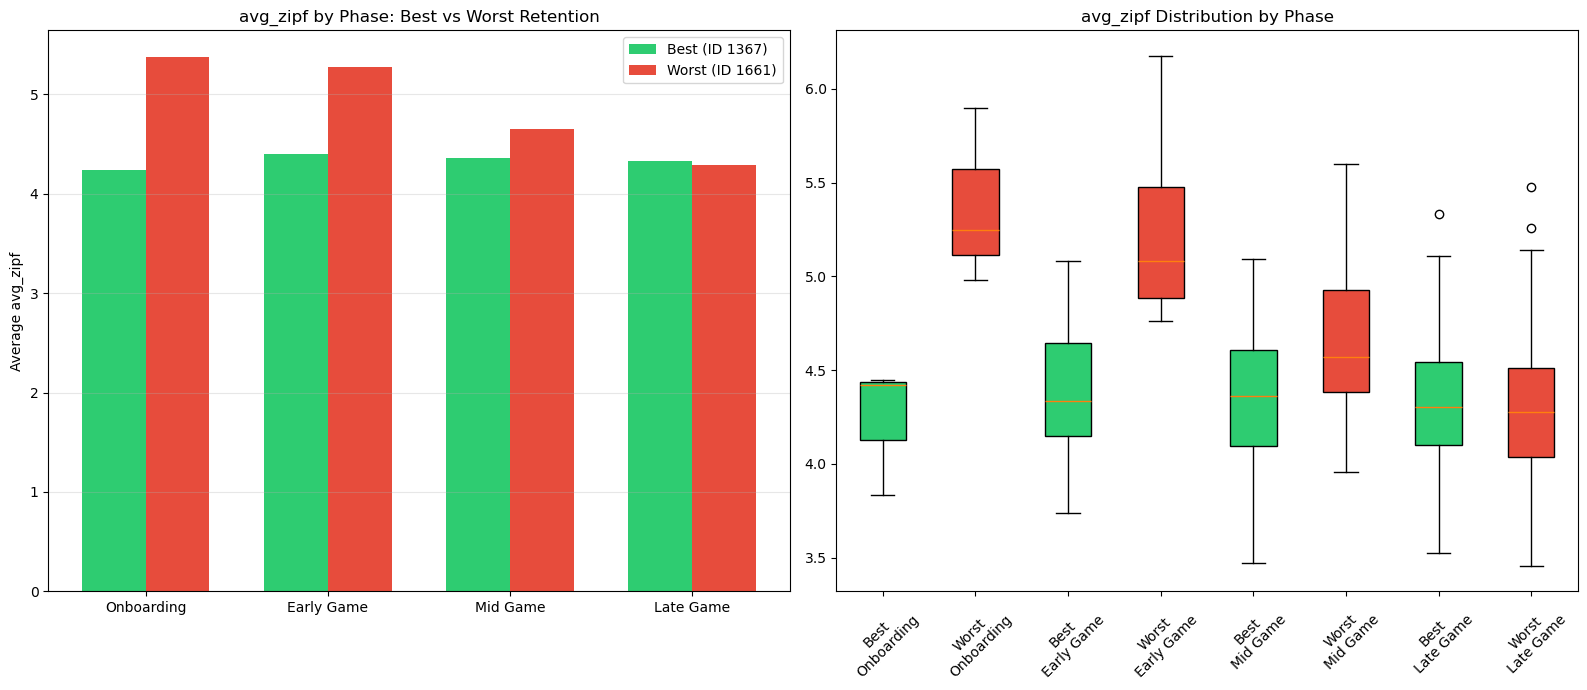


STATISTICAL SUMMARY TABLE
     Phase  Best (1367) Mean  Worst (1661) Mean  Best n  Worst n  t-test p  M-W p
Onboarding            4.2350             5.3767       3        3    0.0320 0.1000
Early Game            4.4031             5.2775       8        4    0.0608 0.0485
  Mid Game            4.3566             4.6544      64       68    0.0000 0.0001
 Late Game            4.3345             4.2916     175      175    0.2459 0.1579


In [18]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0. Ensure phase is an ordered categorical (for consistent ordering)
# ------------------------------------------------------------
phase_order = ['Onboarding', 'Early Game', 'Mid Game', 'Late Game']
data_classified['phase'] = pd.Categorical(
    data_classified['phase'], categories=phase_order, ordered=True
)

# ------------------------------------------------------------
# 1. Choose the Zipf metric to analyse (you can switch to min_zipf / max_zipf / seed_zipf)
# ------------------------------------------------------------
ZIPF_COL = 'avg_zipf'

# ------------------------------------------------------------
# 2. Per‑levelset, per‑phase summary of average Zipf
# ------------------------------------------------------------
print("=" * 80)
print(f"AVERAGE {ZIPF_COL.upper()} BY PHASE PER LEVELSET")
print("=" * 80)

# Group by Levelset_ID and phase (observed=False keeps all phases even if missing)
phase_zipf_summary = (
    data_classified.groupby(['Levelset_ID', 'phase'], observed=False)[ZIPF_COL]
    .agg(['mean', 'count', 'std'])
    .round(2)
    .reset_index()
)

# Pivot tables for a high‑level view (columns follow phase_order automatically)
pivot_zipf = phase_zipf_summary.pivot(index='Levelset_ID', columns='phase', values='mean')
pivot_count = phase_zipf_summary.pivot(index='Levelset_ID', columns='phase', values='count')

print(f"\nAverage {ZIPF_COL} per phase:")
print(pivot_zipf.to_string())

print("\nNumber of levels per phase:")
print(pivot_count.fillna(0).astype(int).to_string())

# ------------------------------------------------------------
# 3. Statistical comparison: best (1367) vs worst (1661) retention
# ------------------------------------------------------------
best_retention_levelset = 1367
worst_retention_levelset = 1661

print("\n" + "=" * 80)
print(f"STATISTICAL COMPARISON: BEST ({best_retention_levelset}) vs WORST ({worst_retention_levelset}) RETENTION")
print("=" * 80)

comparison_results = []
for phase in phase_order:
    best_scores = data_classified[
        (data_classified['Levelset_ID'] == best_retention_levelset) & 
        (data_classified['phase'] == phase)
    ][ZIPF_COL].dropna().values

    worst_scores = data_classified[
        (data_classified['Levelset_ID'] == worst_retention_levelset) & 
        (data_classified['phase'] == phase)
    ][ZIPF_COL].dropna().values

    if len(best_scores) > 0 and len(worst_scores) > 0:
        t_stat, p_value = stats.ttest_ind(best_scores, worst_scores, equal_var=False)
        u_stat, mw_p = stats.mannwhitneyu(best_scores, worst_scores, alternative='two-sided')

        comparison_results.append({
            'Phase': phase,
            f'Best ({best_retention_levelset}) Mean': np.mean(best_scores),
            f'Worst ({worst_retention_levelset}) Mean': np.mean(worst_scores),
            'Best n': len(best_scores),
            'Worst n': len(worst_scores),
            't-test p': p_value,
            'M-W p': mw_p
        })

        print(f"\n{phase}:")
        print(f"  Best Retention (ID {best_retention_levelset}): Mean {ZIPF_COL} = {np.mean(best_scores):.2f} (n={len(best_scores)})")
        print(f"  Worst Retention (ID {worst_retention_levelset}): Mean {ZIPF_COL} = {np.mean(worst_scores):.2f} (n={len(worst_scores)})")
        print(f"  t‑test p = {p_value:.4f}, Mann‑Whitney p = {mw_p:.4f}")
        if p_value < 0.05:
            print("  → Significant difference (p < 0.05)")

# ------------------------------------------------------------
# 4. Visualisations
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Bar chart
ax1 = axes[0]
x = np.arange(len(phase_order))
width = 0.35

best_means = [
    data_classified[
        (data_classified['Levelset_ID'] == best_retention_levelset) & 
        (data_classified['phase'] == phase)
    ][ZIPF_COL].mean()
    for phase in phase_order
]
worst_means = [
    data_classified[
        (data_classified['Levelset_ID'] == worst_retention_levelset) & 
        (data_classified['phase'] == phase)
    ][ZIPF_COL].mean()
    for phase in phase_order
]

ax1.bar(x - width/2, best_means, width, label=f'Best (ID {best_retention_levelset})', color='#2ECC71')
ax1.bar(x + width/2, worst_means, width, label=f'Worst (ID {worst_retention_levelset})', color='#E74C3C')

ax1.set_ylabel(f'Average {ZIPF_COL}')
ax1.set_title(f'{ZIPF_COL} by Phase: Best vs Worst Retention')
ax1.set_xticks(x)
ax1.set_xticklabels(phase_order)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Boxplots
ax2 = axes[1]
plot_data, plot_labels = [], []
for phase in phase_order:
    b_data = data_classified[
        (data_classified['Levelset_ID'] == best_retention_levelset) & 
        (data_classified['phase'] == phase)
    ][ZIPF_COL].dropna()
    w_data = data_classified[
        (data_classified['Levelset_ID'] == worst_retention_levelset) & 
        (data_classified['phase'] == phase)
    ][ZIPF_COL].dropna()

    if not b_data.empty:
        plot_data.append(b_data)
        plot_labels.append(f"Best\n{phase}")
    if not w_data.empty:
        plot_data.append(w_data)
        plot_labels.append(f"Worst\n{phase}")

bp = ax2.boxplot(plot_data, labels=plot_labels, patch_artist=True)
# Colour alternating best (green) / worst (red)
colors = ['#2ECC71', '#E74C3C'] * (len(plot_data) // 2)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax2.set_title(f'{ZIPF_COL} Distribution by Phase')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. Summary table
# ------------------------------------------------------------
if comparison_results:
    print("\n" + "=" * 80)
    print("STATISTICAL SUMMARY TABLE")
    print("=" * 80)
    summary_df = pd.DataFrame(comparison_results).round(4)
    print(summary_df.to_string(index=False))

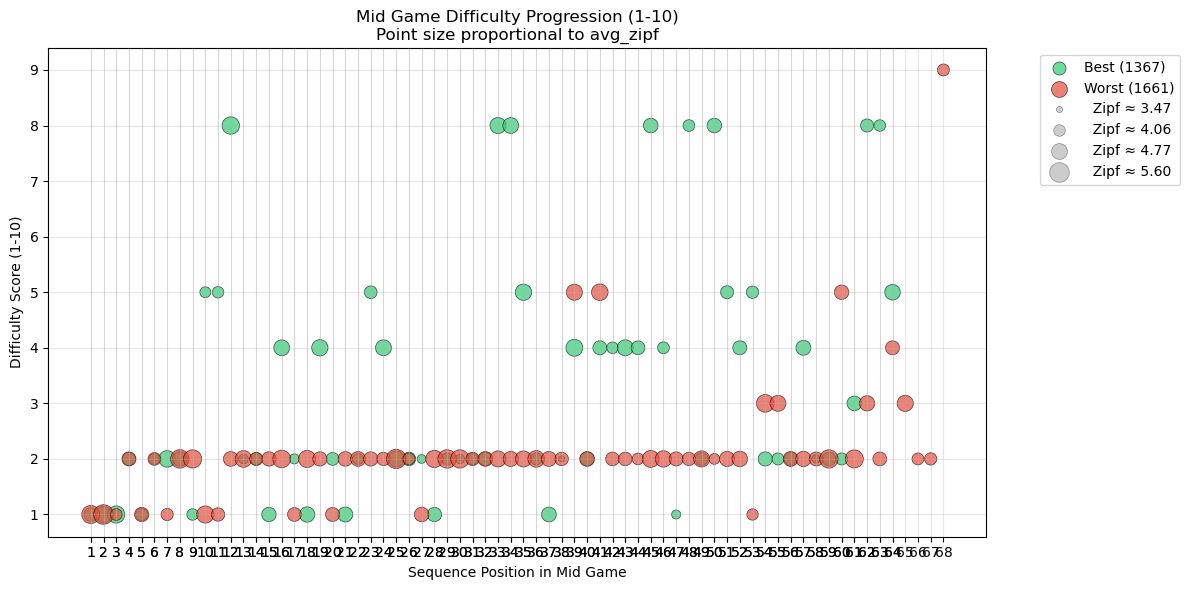

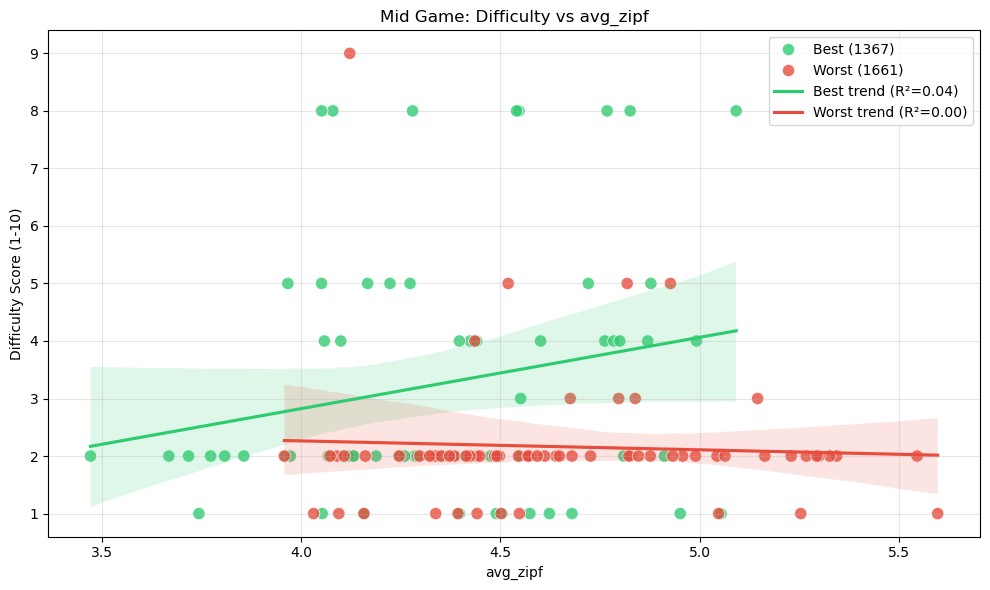

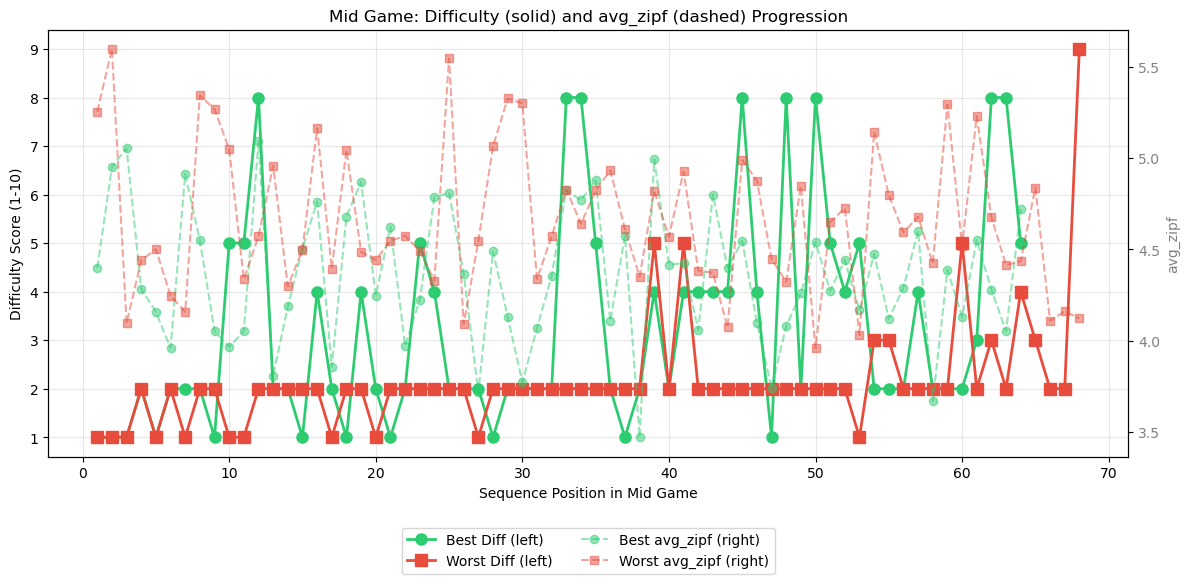


MID GAME SUMMARY: Difficulty (1-10) AND avg_zipf
Best (1367):
  Difficulty: Mean=3.27, Std=2.20, Min=1, Max=8
  avg_zipf: Mean=4.36, Std=0.37, Min=3.47, Max=5.09
  Correlation (Diff vs avg_zipf): 0.210

Worst (1661):
  Difficulty: Mean=2.16, Std=1.18, Min=1, Max=9
  avg_zipf: Mean=4.65, Std=0.40, Min=3.96, Max=5.60
  Correlation (Diff vs avg_zipf): -0.052

T‑test for avg_zipf difference: t = -4.454, p = 0.0000
  → Significant difference in word frequency between the two levelsets.


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ------------------------------------------------------------
# 0. Build a DataFrame with difficulty (1‑10) AND Zipf columns
# ------------------------------------------------------------
# The 10‑cluster run already produced features_df['difficulty_10'].
merged_df = pd.merge(
    data_classified,         # has Levelset_ID, level_no, phase, avg_zipf, min_zipf, etc.
    features_df[['Levelset_ID', 'level_no', 'difficulty_10']],
    on=['Levelset_ID', 'level_no'],
    how='inner'
)

# To keep the code clean, rename the difficulty column to a generic name
merged_df.rename(columns={'difficulty_10': 'difficulty'}, inplace=True)

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------
best_id = 1367
worst_id = 1661
phase_name = 'Mid Game'
zipf_metric = 'avg_zipf'        # change to 'min_zipf', 'max_zipf', 'seed_zipf' as needed

# ------------------------------------------------------------
# Extract Mid Game data and add sequential position
# ------------------------------------------------------------
best_mid = merged_df[(merged_df['Levelset_ID'] == best_id) & 
                     (merged_df['phase'] == phase_name)].copy()
worst_mid = merged_df[(merged_df['Levelset_ID'] == worst_id) & 
                      (merged_df['phase'] == phase_name)].copy()

best_mid = best_mid.sort_values('level_no').reset_index(drop=True)
worst_mid = worst_mid.sort_values('level_no').reset_index(drop=True)
best_mid['mid_seq'] = best_mid.index + 1
worst_mid['mid_seq'] = worst_mid.index + 1

# DataFrames for plotting
best_plot = best_mid[['mid_seq', 'difficulty', zipf_metric]].copy()
worst_plot = worst_mid[['mid_seq', 'difficulty', zipf_metric]].copy()
best_plot['Levelset'] = f'Best ({best_id})'
worst_plot['Levelset'] = f'Worst ({worst_id})'
all_mid = pd.concat([best_plot, worst_plot], ignore_index=True)

# ------------------------------------------------------------
# Plot 1: Bubble chart – difficulty vs. sequence, bubble size = Zipf
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))

min_z = all_mid[zipf_metric].min()
max_z = all_mid[zipf_metric].max()
size_scale = lambda z: 20 + 180 * (z - min_z) / (max_z - min_z + 1e-6)

for levelset, grp in all_mid.groupby('Levelset'):
    sizes = size_scale(grp[zipf_metric])
    if levelset == f'Best ({best_id})':
        plt.scatter(grp['mid_seq'], grp['difficulty'], s=sizes,
                    alpha=0.7, label=levelset, color='#2ECC71',
                    edgecolors='black', linewidth=0.5)
    else:
        plt.scatter(grp['mid_seq'], grp['difficulty'], s=sizes,
                    alpha=0.7, label=levelset, color='#E74C3C',
                    edgecolors='black', linewidth=0.5)

plt.xlabel('Sequence Position in Mid Game')
plt.ylabel('Difficulty Score (1-10)')
plt.title(f'Mid Game Difficulty Progression (1-10)\nPoint size proportional to {zipf_metric}')
plt.grid(True, alpha=0.3)
plt.xticks(all_mid['mid_seq'].dropna().astype(int))

# Legend for marker sizes
handles, labels = plt.gca().get_legend_handles_labels()
size_values = [20, 70, 130, 200]
for sv in size_values:
    z_val = min_z + (sv - 20) / 180 * (max_z - min_z)
    plt.scatter([], [], s=sv, c='gray', alpha=0.4, edgecolors='black', linewidth=0.5,
                label=f'  Zipf ≈ {z_val:.2f}')
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot 2: Scatter difficulty vs Zipf with regression lines
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.scatterplot(data=all_mid, x=zipf_metric, y='difficulty', hue='Levelset',
                palette=['#2ECC71', '#E74C3C'], s=80, alpha=0.8)
sns.regplot(data=best_plot, x=zipf_metric, y='difficulty', scatter=False,
            color='#2ECC71',
            label=f'Best trend (R²={best_plot[zipf_metric].corr(best_plot["difficulty"])**2:.2f})')
sns.regplot(data=worst_plot, x=zipf_metric, y='difficulty', scatter=False,
            color='#E74C3C',
            label=f'Worst trend (R²={worst_plot[zipf_metric].corr(worst_plot["difficulty"])**2:.2f})')
plt.xlabel(f'{zipf_metric}')
plt.ylabel('Difficulty Score (1-10)')
plt.title(f'Mid Game: Difficulty vs {zipf_metric}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot 3: Dual‑axis line chart – difficulty & Zipf across the sequence
# ------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(best_plot['mid_seq'], best_plot['difficulty'], 'o-', color='#2ECC71',
         linewidth=2, markersize=8, label=f'Best Diff (left)')
ax1.plot(worst_plot['mid_seq'], worst_plot['difficulty'], 's-', color='#E74C3C',
         linewidth=2, markersize=8, label=f'Worst Diff (left)')
ax1.set_xlabel('Sequence Position in Mid Game')
ax1.set_ylabel('Difficulty Score (1-10)', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(best_plot['mid_seq'], best_plot[zipf_metric], 'o--', color='#2ECC71',
         alpha=0.5, linewidth=1.5, markersize=6, label=f'Best {zipf_metric} (right)')
ax2.plot(worst_plot['mid_seq'], worst_plot[zipf_metric], 's--', color='#E74C3C',
         alpha=0.5, linewidth=1.5, markersize=6, label=f'Worst {zipf_metric} (right)')
ax2.set_ylabel(f'{zipf_metric}', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center',
           bbox_to_anchor=(0.5, -0.15), ncol=2)

plt.title(f'Mid Game: Difficulty (solid) and {zipf_metric} (dashed) Progression')
fig.tight_layout()
plt.show()

# ------------------------------------------------------------
# Summary statistics and correlation
# ------------------------------------------------------------
print("\n" + "=" * 100)
print(f"MID GAME SUMMARY: Difficulty (1-10) AND {zipf_metric}")
print("=" * 100)
print(f"Best ({best_id}):")
print(f"  Difficulty: Mean={best_mid['difficulty'].mean():.2f}, Std={best_mid['difficulty'].std():.2f}, "
      f"Min={best_mid['difficulty'].min()}, Max={best_mid['difficulty'].max()}")
print(f"  {zipf_metric}: Mean={best_mid[zipf_metric].mean():.2f}, Std={best_mid[zipf_metric].std():.2f}, "
      f"Min={best_mid[zipf_metric].min():.2f}, Max={best_mid[zipf_metric].max():.2f}")
print(f"  Correlation (Diff vs {zipf_metric}): {best_mid['difficulty'].corr(best_mid[zipf_metric]):.3f}")

print(f"\nWorst ({worst_id}):")
print(f"  Difficulty: Mean={worst_mid['difficulty'].mean():.2f}, Std={worst_mid['difficulty'].std():.2f}, "
      f"Min={worst_mid['difficulty'].min()}, Max={worst_mid['difficulty'].max()}")
print(f"  {zipf_metric}: Mean={worst_mid[zipf_metric].mean():.2f}, Std={worst_mid[zipf_metric].std():.2f}, "
      f"Min={worst_mid[zipf_metric].min():.2f}, Max={worst_mid[zipf_metric].max():.2f}")
print(f"  Correlation (Diff vs {zipf_metric}): {worst_mid['difficulty'].corr(worst_mid[zipf_metric]):.3f}")

# T‑test comparing average Zipf between the two levelsets
t_stat_z, p_z = stats.ttest_ind(best_mid[zipf_metric], worst_mid[zipf_metric], equal_var=False)
print(f"\nT‑test for {zipf_metric} difference: t = {t_stat_z:.3f}, p = {p_z:.4f}")
if p_z < 0.05:
    print("  → Significant difference in word frequency between the two levelsets.")
else:
    print("  → No significant difference.")

CORRELATION: DIFFICULTY (1‑10) vs ZIPF METRICS

Overall (all phases combined):
  difficulty_10 vs avg_zipf    : r = -0.2506
  difficulty_10 vs min_zipf    : r = -0.4124
  difficulty_10 vs max_zipf    : r = +0.1050
  difficulty_10 vs seed_zipf   : r = -0.2294

Onboarding:
  difficulty_10 vs avg_zipf    : r = +nan
  difficulty_10 vs min_zipf    : r = +nan
  difficulty_10 vs max_zipf    : r = +nan
  difficulty_10 vs seed_zipf   : r = +nan

Early Game:
  difficulty_10 vs avg_zipf    : r = +nan
  difficulty_10 vs min_zipf    : r = +nan
  difficulty_10 vs max_zipf    : r = +nan
  difficulty_10 vs seed_zipf   : r = +nan

Mid Game:
  difficulty_10 vs avg_zipf    : r = -0.0550
  difficulty_10 vs min_zipf    : r = -0.1929
  difficulty_10 vs max_zipf    : r = +0.1125
  difficulty_10 vs seed_zipf   : r = -0.0188

Late Game:
  difficulty_10 vs avg_zipf    : r = -0.1776
  difficulty_10 vs min_zipf    : r = -0.2930
  difficulty_10 vs max_zipf    : r = +0.0163
  difficulty_10 vs seed_zipf   : r = -0.1

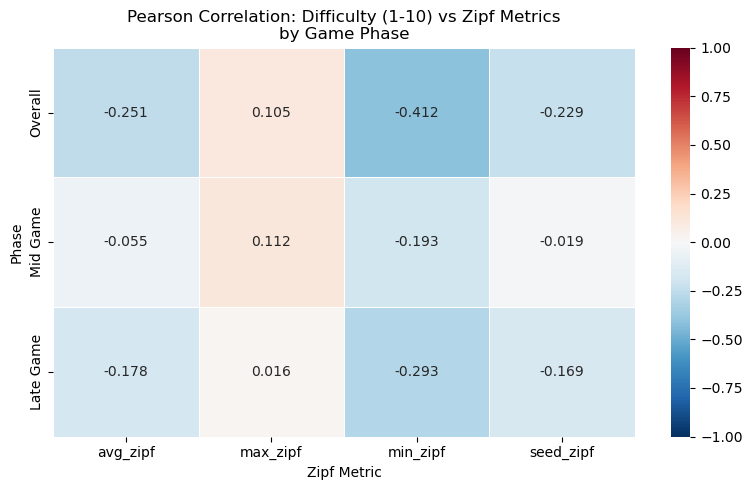


STRONG CORRELATIONS (|r| > 0.7)
No strong correlations detected. Difficulty and Zipf are largely independent.


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Merge difficulty_10 with zipf columns
# ------------------------------------------------------------
# data_classified contains: Levelset_ID, level_no, phase, avg_zipf, min_zipf, max_zipf, seed_zipf
# features_df contains: Levelset_ID, level_no, difficulty_10 (from 10‑cluster KMeans)
df_corr = pd.merge(
    data_classified[['Levelset_ID', 'level_no', 'phase', 'avg_zipf', 'min_zipf', 'max_zipf', 'seed_zipf']],
    features_df[['Levelset_ID', 'level_no', 'difficulty_10']],
    on=['Levelset_ID', 'level_no'],
    how='inner'
)

zipf_metrics = ['avg_zipf', 'min_zipf', 'max_zipf', 'seed_zipf']
phase_order = ['Onboarding', 'Early Game', 'Mid Game', 'Late Game']

# ------------------------------------------------------------
# 2. Compute correlations per phase and overall
# ------------------------------------------------------------
print("=" * 80)
print("CORRELATION: DIFFICULTY (1‑10) vs ZIPF METRICS")
print("=" * 80)

correlation_results = []

# Overall
print("\nOverall (all phases combined):")
for zm in zipf_metrics:
    r = df_corr['difficulty_10'].corr(df_corr[zm])
    print(f"  difficulty_10 vs {zm:12s}: r = {r:+.4f}")
    correlation_results.append({'Phase': 'Overall', 'Zipf Metric': zm, 'Correlation': r})

# Per phase
for phase in phase_order:
    phase_df = df_corr[df_corr['phase'] == phase]
    if len(phase_df) < 3:
        print(f"\n{phase}: not enough data")
        continue
    print(f"\n{phase}:")
    for zm in zipf_metrics:
        r = phase_df['difficulty_10'].corr(phase_df[zm])
        print(f"  difficulty_10 vs {zm:12s}: r = {r:+.4f}")
        correlation_results.append({'Phase': phase, 'Zipf Metric': zm, 'Correlation': r})

# ------------------------------------------------------------
# 3. Heatmap of correlations per phase
# ------------------------------------------------------------
# Prepare a pivot table: rows = Phase+Overall, columns = Zipf metric
corr_df = pd.DataFrame(correlation_results)
corr_pivot = corr_df.pivot_table(values='Correlation', index='Phase', columns='Zipf Metric')

# Reorder rows (Overall on top)
row_order = ['Overall'] + [p for p in phase_order if p in corr_pivot.index]
corr_pivot = corr_pivot.reindex(row_order)

plt.figure(figsize=(8, 5))
sns.heatmap(corr_pivot, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.5)
plt.title('Pearson Correlation: Difficulty (1-10) vs Zipf Metrics\nby Game Phase')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. Flag strong correlations (|r| > 0.7)
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("STRONG CORRELATIONS (|r| > 0.7)")
print("=" * 80)
strong = corr_df[corr_df['Correlation'].abs() > 0.7]
if len(strong) == 0:
    print("No strong correlations detected. Difficulty and Zipf are largely independent.")
else:
    for _, row in strong.iterrows():
        print(f"  {row['Phase']:12s} | {row['Zipf Metric']:12s} | r = {row['Correlation']:+.3f}")


####################################################################################################
### ANALYSIS: CHURN ~ AVG_ZIPF ###
####################################################################################################

PHASE-WISE REGRESSION: CHURN ~ AVG_ZIPF (per levelset)

======================================== Levelset 1367 ========================================
  Onboarding  : n=  2 → not enough data
  Early Game  : n=  8 | Equation: Churn = 26.66 + (-5.01)*avg_zipf | R² = 0.2619 | t = -1.459, p = 0.1948
  Mid Game    : n= 64 | Equation: Churn = -0.42 + (+0.50)*avg_zipf | R² = 0.0206 | t = 1.142, p = 0.2579
  Late Game   : n=175 | Equation: Churn = 1.28 + (-0.17)*avg_zipf | R² = 0.0125 | t = -1.479, p = 0.1411

======================================== Levelset 1421 ========================================
  Onboarding  : n=  2 → not enough data
  Early Game  : n=  5 | Equation: Churn = 42.15 + (-9.01)*avg_zipf | R² = 0.4533 | t = -1.577, p = 0.2129
  Mid Game

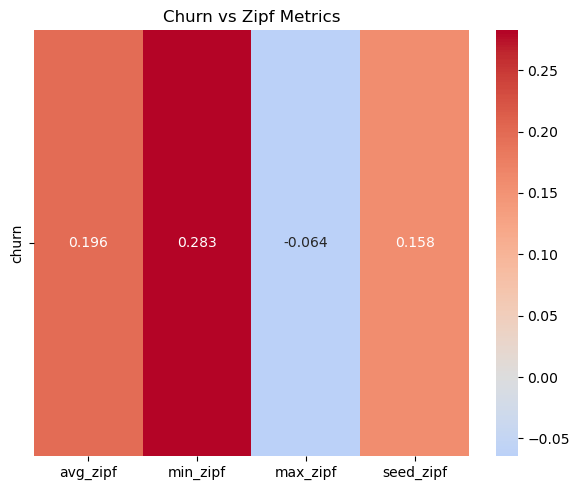

In [24]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Build the analysis DataFrame with churn + Zipf metrics
# ------------------------------------------------------------
# base_analysis already exists from previous steps and contains:
# Levelset_ID, level_no, churn, phase
# We need to merge in Zipf columns from data_classified.

zipf_cols = ['avg_zipf', 'min_zipf', 'max_zipf', 'seed_zipf']
# data_classified has these columns; ensure they are present.
df_churn_zipf = pd.merge(
    base_analysis[['Levelset_ID', 'level_no', 'phase', 'churn']],
    data_classified[['Levelset_ID', 'level_no'] + zipf_cols],
    on=['Levelset_ID', 'level_no'],
    how='inner'
)

# ------------------------------------------------------------
# 2. Auxiliary function for linear regression (continuous predictor)
# ------------------------------------------------------------
def regress_churn_on_zipf(y, X_cont):
    """Return intercept, slope, R², t-stat, p-value for churn ~ zipf"""
    mask = ~np.isnan(X_cont) & ~np.isnan(y)
    y, X_cont = y[mask], X_cont[mask]
    if len(y) < 3:
        return np.nan, np.nan, np.nan, np.nan, np.nan
    slope, intercept, r_value, p_val, std_err = stats.linregress(X_cont, y)
    r2 = r_value ** 2
    # t-statistic for slope
    t_stat = slope / std_err if std_err != 0 else np.nan
    return intercept, slope, r2, t_stat, p_val

# ------------------------------------------------------------
# 3. Loop over Zipf metrics
# ------------------------------------------------------------
phase_order = ['Onboarding', 'Early Game', 'Mid Game', 'Late Game']

for zipf_metric in zipf_cols:
    print("\n" + "#" * 100)
    print(f"### ANALYSIS: CHURN ~ {zipf_metric.upper()} ###")
    print("#" * 100)

    # --- Per-levelset, per-phase regression ---
    print("\n" + "=" * 100)
    print(f"PHASE-WISE REGRESSION: CHURN ~ {zipf_metric.upper()} (per levelset)")
    print("=" * 100)

    for levelset_id in sorted(df_churn_zipf['Levelset_ID'].unique()):
        ls_data = df_churn_zipf[df_churn_zipf['Levelset_ID'] == levelset_id]
        print(f"\n{'='*40} Levelset {levelset_id} {'='*40}")
        for phase in phase_order:
            subset = ls_data[ls_data['phase'] == phase]
            n = len(subset)
            if n < 3:
                print(f"  {phase:12s}: n={n:3d} → not enough data")
                continue

            intercept, slope, r2, t_stat, p_val = regress_churn_on_zipf(
                subset['churn'].values, subset[zipf_metric].values
            )

            if np.isnan(intercept):
                print(f"  {phase:12s}: n={n:3d} → regression failed")
                continue

            significance = " * significant" if (not np.isnan(p_val) and p_val < 0.05) else ""
            print(f"  {phase:12s}: n={n:3d} | "
                  f"Equation: Churn = {intercept:.2f} + ({slope:+.2f})*{zipf_metric} | "
                  f"R² = {r2:.4f} | "
                  f"t = {t_stat:.3f}, p = {p_val:.4f}{significance}")

    # --- Overall pooled regression per phase ---
    print("\n" + "=" * 100)
    print(f"OVERALL REGRESSION BY PHASE (POOLED): CHURN ~ {zipf_metric.upper()}")
    print("=" * 100)
    for phase in phase_order:
        pooled = df_churn_zipf[df_churn_zipf['phase'] == phase]
        if len(pooled) < 3:
            print(f"  {phase:12s}: not enough data")
            continue
        intercept, slope, r2, t_stat, p_val = regress_churn_on_zipf(
            pooled['churn'].values, pooled[zipf_metric].values
        )
        if np.isnan(intercept):
            print(f"  {phase:12s}: n={len(pooled):4d} → regression failed")
            continue
        significance = " * significant" if (not np.isnan(p_val) and p_val < 0.05) else ""
        print(f"  {phase:12s}: n={len(pooled):4d} | "
              f"Equation: Churn = {intercept:.2f} + ({slope:+.2f})*{zipf_metric} | "
              f"R² = {r2:.4f} | "
              f"t = {t_stat:.3f}, p = {p_val:.4f}{significance}")

    # --- Overall (all phases together) ---
    print("\n--- Overall (all phases) ---")
    intercept, slope, r2, t_stat, p_val = regress_churn_on_zipf(
        df_churn_zipf['churn'].values, df_churn_zipf[zipf_metric].values
    )
    if not np.isnan(intercept):
        print(f"  n={len(df_churn_zipf):4d} | "
              f"Equation: Churn = {intercept:.2f} + ({slope:+.2f})*{zipf_metric} | "
              f"R² = {r2:.4f} | "
              f"t = {t_stat:.3f}, p = {p_val:.4f}")

# ------------------------------------------------------------
# 4. Quick correlation matrix (churn vs all Zipf metrics)
# ------------------------------------------------------------
print("\n" + "=" * 100)
print("CORRELATION MATRIX: CHURN vs ZIPF METRICS")
print("=" * 100)
corr_matrix = df_churn_zipf[['churn'] + zipf_cols].corr()
print(corr_matrix.round(3))

# Optional: heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix.loc[['churn'], zipf_cols], annot=True, cmap='coolwarm', center=0, fmt='.3f')
plt.title('Churn vs Zipf Metrics')
plt.tight_layout()
plt.show()

### Regression Analysis

In [44]:
##############################################################################
# COMBINED ANALYSIS
#   1) Retention OLS (per-levelset & pooled) – klasik fakat yanıltıcı olabilir
#   2) Churn GEE (pooled by phase) – daha güvenilir
#   Difficulty clustering: DESIGN FEATURES ONLY (no avg_hint)
##############################################################################
import pandas as pd
import numpy as np
import json
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import statsmodels.api as sm
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.cov_struct import Autoregressive
import warnings
warnings.filterwarnings('ignore')

# ── 1. LOAD & PREPARE ────────────────────────────────────────────────────────
raw = pd.read_csv('filled_dataset.csv')
raw = raw.sort_values(['Levelset_ID', 'level_no']).reset_index(drop=True)
raw = raw.loc[:, ~raw.columns.duplicated()]

# ── 2. RETENTION % ───────────────────────────────────────────────────────────
raw['retention_pct'] = np.nan
for ls_id, grp in raw.groupby('Levelset_ID', sort=False):
    grp = grp.sort_values('level_no')
    initial = grp['total_users'].iloc[0]
    raw.loc[grp.index, 'retention_pct'] = raw.loc[grp.index, 'total_users'] / initial * 100

# ── 3. FIRST 250 LEVELS ONLY ─────────────────────────────────────────────────
data250 = raw[raw['level_no'] <= 250].copy().reset_index(drop=True)

# ── 4. PHASE CLASSIFICATION (RETENTION‑BASED, ORIGINAL) ──────────────────────
def classify_phases(df):
    df = df.sort_values('level_no').copy()
    lvl = df['level_no'].values
    ret = df['retention_pct'].values
    if len(df) < 3: return None
    ph = np.full(len(df), '', dtype=object)
    ph[(lvl <= 3) | (ret >= 85)] = 'Onboarding'
    below60 = np.where(ret < 60)[0]
    first_drop = below60[0] if len(below60) > 0 else len(lvl)
    ph[(ph == '') & (np.arange(len(lvl)) < first_drop)] = 'Early Game'
    ph[(ph == '') & ((ret >= 30) | (lvl <= lvl.max() * 0.3))] = 'Mid Game'
    ph[ph == ''] = 'Late Game'
    df['phase'] = ph
    return df

pieces = [classify_phases(data250[data250['Levelset_ID'] == ls].copy())
          for ls in data250['Levelset_ID'].unique()]
data250 = pd.concat([p for p in pieces if p is not None], ignore_index=True)

# ── 5. LEVEL DESIGN FEATURES (NO avg_hint) ───────────────────────────────────
def parse_level(s):
    try:    wi = json.loads(s)
    except: return dict(word_count=0, total_letters=0, avg_word_length=0,
                        intersections=0, max_word_length=0, min_word_length=0)
    if not wi:
        return dict(word_count=0, total_letters=0, avg_word_length=0,
                    intersections=0, max_word_length=0, min_word_length=0)
    wp = []
    for w in wi:
        x, y = w['x'], w['y']
        is_hor = w.get('IsHorizontal', w.get('isHorizontal', True))
        l = len(w['Word'])
        wp.append([(x + i, y) if is_hor else (x, y + i) for i in range(l)])
    wlens = [len(p) for p in wp]
    cells = {}
    for pl in wp:
        for pos in pl: cells[pos] = cells.get(pos, 0) + 1
    return dict(word_count       = len(wp),
                total_letters    = sum(wlens),
                avg_word_length  = sum(wlens) / len(wp),
                intersections    = sum(1 for c in cells.values() if c >= 2),
                max_word_length  = max(wlens),
                min_word_length  = min(wlens))

feats = pd.DataFrame(data250['level_data'].apply(parse_level).tolist())

def clean_num(x):
    if isinstance(x, str): return float(x.replace(',', '.'))
    return float(x) if pd.notna(x) else 0.0

# DESIGN‑ONLY features (no avg_hint)
feats['board_count']    = pd.to_numeric(data250['board_count'],  errors='coerce').fillna(0).values
feats['dimx']           = pd.to_numeric(data250['dimx'],         errors='coerce').fillna(0).values
feats['dimy']           = pd.to_numeric(data250['dimy'],         errors='coerce').fillna(0).values
feats['seed_word_len']  = data250['seed_word'].fillna('').astype(str).apply(len).values

FEAT_COLS = ['board_count', 'dimx', 'dimy', 'word_count',
             'avg_word_length', 'intersections', 'max_word_length', 'seed_word_len']
for c in FEAT_COLS:
    feats[c] = pd.to_numeric(feats[c], errors='coerce').fillna(0)

# ── 6. DIFFICULTY CLUSTERING (10 clusters, design only) ──────────────────────
scaler = StandardScaler()
X_sc = scaler.fit_transform(feats[FEAT_COLS])
km10 = KMeans(n_clusters=10, random_state=42, n_init=10)
feats['cluster'] = km10.fit_predict(X_sc)

ctr = pd.DataFrame(scaler.inverse_transform(km10.cluster_centers_), columns=FEAT_COLS)
DIFF_SCORE_COLS = ['board_count', 'word_count', 'intersections', 'dimx', 'dimy']
ctr['score'] = ctr[DIFF_SCORE_COLS].mean(axis=1)

diff_map = {c: i+1 for i, c in enumerate(ctr['score'].sort_values().index)}
data250['difficulty_10'] = feats['cluster'].map(diff_map).values

# ── 7. REPEATED WORD FLAG (window=20) ────────────────────────────────────────
data250['repeated_word'] = 0
for ls_id, grp in data250.groupby('Levelset_ID'):
    grp = grp.sort_values('level_no')
    history = []
    for idx, row in grp.iterrows():
        try:    cur_words = set(w['Word'] for w in json.loads(row['level_data']))
        except: cur_words = set()
        data250.at[idx, 'repeated_word'] = 1 if history and any(cur_words & h for h in history) else 0
        history.insert(0, cur_words)
        if len(history) > 20: history.pop()

# ── 8. MASD (Mean Absolute Successive Difference, PAST ONLY) ─────────────────
data250['diff_masd'] = np.nan
for ls_id, grp in data250.groupby('Levelset_ID'):
    grp = grp.sort_values('level_no')
    vals = grp['difficulty_10'].values.astype(float)
    masd = [np.nan]
    for i in range(1, len(vals)):
        abs_diff = np.abs(vals[i] - vals[i-1])
        if i == 1:
            new_masd = abs_diff
        else:
            new_masd = (masd[-1] * (i-1) + abs_diff) / i
        masd.append(new_masd)
    data250.loc[grp.index, 'diff_masd'] = masd

# ── 9. MIN_ZIPF ──────────────────────────────────────────────────────────────
data250['min_zipf'] = pd.to_numeric(data250['min_zipf'], errors='coerce')

# ── 10. CLEAN DATASET ────────────────────────────────────────────────────────
data250 = data250.loc[:, ~data250.columns.duplicated()].reset_index(drop=True)

PREDICTORS = ['level_no', 'difficulty_10', 'diff_masd', 'repeated_word', 'min_zipf']
PHASE_ORDER = ['Onboarding', 'Early Game', 'Mid Game', 'Late Game']

# =============================================================================
# ===== PART 1: RETENTION OLS (PER-LEVELSET & POOLED) =========================
# =============================================================================
reg = data250[['Levelset_ID', 'level_no', 'phase', 'retention_pct'] + PREDICTORS].copy()
reg = reg.dropna(subset=['retention_pct', 'difficulty_10', 'diff_masd', 'min_zipf']).reset_index(drop=True)

# Duplicate column check (level_no appears once because we cleaned)
print("="*100)
print("RETENTION OLS ANALYSIS")
print("="*100)
print(f"Dataset: {len(reg)} rows, columns: {reg.columns.tolist()}")
print(f"Phase counts:\n{reg['phase'].value_counts()}\n")

def run_ols(subset_df, label):
    n = len(subset_df)
    if n < 5:
        print(f"  {label:12s}: n={n} → not enough data")
        return None
    X_np = subset_df[PREDICTORS].values
    ones = np.ones((n, 1))
    X_full = np.hstack([ones, X_np])
    y_np = subset_df['retention_pct'].values
    col_nm = ['const'] + PREDICTORS
    model = sm.OLS(y_np, X_full).fit()
    model.model.exog_names[:] = col_nm
    print(f"\n  {label} (n={n})  R²={model.rsquared:.4f}")
    for name, coef, pval in zip(col_nm, model.params, model.pvalues):
        sig = " *" if pval < 0.05 else ""
        print(f"    {name:20s}: {coef:8.4f}  (p={pval:.4f}){sig}")
    return model, col_nm

# -- Per-levelset × phase --
all_coeffs_ret = []
for ls_id in sorted(reg['Levelset_ID'].unique()):
    ls_sub = reg[reg['Levelset_ID'] == ls_id]
    print(f"\n{'='*40} Levelset {ls_id} {'='*40}")
    for phase in PHASE_ORDER:
        sub = ls_sub[ls_sub['phase'] == phase]
        res = run_ols(sub, phase)
        if res is None: continue
        model, col_nm = res
        for name, coef, pval in zip(col_nm[1:], model.params[1:], model.pvalues[1:]):
            all_coeffs_ret.append(dict(Levelset_ID=ls_id, Phase=phase, Variable=name,
                                       Coefficient=coef, p_value=pval, R2=model.rsquared))

# -- Pooled per phase --
print("\n" + "-"*80)
print("POOLED OLS BY PHASE")
print("-"*80)
for phase in PHASE_ORDER:
    run_ols(reg[reg['phase'] == phase], phase)

# -- Significant effects summary (OLS) --
coeff_ret = pd.DataFrame(all_coeffs_ret)
sig_ret = coeff_ret[coeff_ret['p_value'] < 0.05]
print("\n" + "="*100)
print("SIGNIFICANT EFFECTS (p<0.05) - RETENTION OLS")
print("="*100)
if len(sig_ret) == 0:
    print("No significant effects.")
else:
    for (ls, ph), grp in sig_ret.groupby(['Levelset_ID', 'Phase']):
        print(f"\nLevelset {ls} | {ph}")
        for _, row in grp.iterrows():
            print(f"  {row['Variable']:20s}  coef={row['Coefficient']:+.4f}  p={row['p_value']:.4f}  R²={row['R2']:.4f}")

# =============================================================================
# ===== PART 2: CHURN GEE (POOLED BY PHASE, BINOMIAL) =========================
# =============================================================================
print("\n\n" + "="*100)
print("CHURN GEE ANALYSIS (Binomial, AR(1) within levelset)")
print("="*100)

# Build churn dataset
churn_rows = []
for ls_id, grp in data250.groupby('Levelset_ID'):
    grp = grp.sort_values('level_no')
    for i in range(len(grp) - 1):
        curr = grp.iloc[i]
        nxt  = grp.iloc[i+1]
        churned = curr['total_users'] - nxt['total_users']
        if churned < 0: churned = 0
        success = nxt['total_users']
        row = {
            'Levelset_ID': ls_id,
            'level_no': curr['level_no'],
            'phase': curr['phase'],
            'difficulty_10': curr['difficulty_10'],
            'diff_masd': curr['diff_masd'],
            'repeated_word': curr['repeated_word'],
            'min_zipf': curr['min_zipf'],
            'churned': churned,
            'success': success,
        }
        churn_rows.append(row)
churn_df = pd.DataFrame(churn_rows)
churn_df = churn_df.dropna(subset=['difficulty_10', 'diff_masd', 'min_zipf']).reset_index(drop=True)

print(f"Churn dataset: {len(churn_df)} rows")
print(f"Phase counts:\n{churn_df['phase'].value_counts()}\n")

for phase in PHASE_ORDER:
    sub = churn_df[churn_df['phase'] == phase]
    if len(sub) < 10:
        print(f"{phase}: n={len(sub)} → insufficient data\n")
        continue

    y = sub[['churned', 'success']].values
    X = sub[['level_no', 'difficulty_10', 'diff_masd', 'repeated_word', 'min_zipf']]
    X = sm.add_constant(X)
    groups = sub['Levelset_ID']

    model = sm.GEE(y, X, groups=groups, family=Binomial(), cov_struct=Autoregressive(grid=False))
    result = model.fit()
    print(f"Phase: {phase} (n={len(sub)})")
    print(result.summary())

    print("\nOdds Ratios:")
    for name, coef in zip(X.columns, result.params):
        or_val = np.exp(coef)
        print(f"  {name:20s}: {or_val:.4f}")
    print("-" * 80)

print("\nDone.")

RETENTION OLS ANALYSIS
Dataset: 996 rows, columns: ['Levelset_ID', 'level_no', 'phase', 'retention_pct', 'level_no', 'difficulty_10', 'diff_masd', 'repeated_word', 'min_zipf']
Phase counts:
phase
Late Game     700
Mid Game      267
Early Game     21
Onboarding      8
Name: count, dtype: int64


======================================== Levelset 1367 ========================================
  Onboarding  : n=2 → not enough data

  Early Game (n=8)  R²=0.7926
    const               :  45.5998  (p=0.0001) *
    level_no            :  -1.3089  (p=0.0113) *
    difficulty_10       :  -1.3089  (p=0.0113) *
    diff_masd           :  45.5998  (p=0.0001) *
    repeated_word       :   0.0000  (p=nan)
    min_zipf            :   0.0000  (p=nan)

  Mid Game (n=64)  R²=0.9579
    const               :  50.3896  (p=0.0000) *
    level_no            :  -0.0911  (p=0.0000) *
    difficulty_10       :  -0.0911  (p=0.0000) *
    diff_masd           :  -0.0372  (p=0.8269)
    repeated_word       : -14.9

In [43]:
##############################################################################
# ROBUST ANALYSIS — GEE (pooled) + HAC‑OLS (per levelset)
# Difficulty: 10‑cluster, DESIGN FEATURES ONLY (no avg_hint)
# Phases = original retention‑based (CAUTION: selection bias)
##############################################################################
import pandas as pd
import numpy as np
import json
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import statsmodels.api as sm
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.cov_struct import Autoregressive
import warnings
warnings.filterwarnings('ignore')

# ── 1. LOAD & PREPARE ────────────────────────────────────────────────────────
raw = pd.read_csv('filled_dataset.csv')
raw = raw.sort_values(['Levelset_ID', 'level_no']).reset_index(drop=True)
raw = raw.loc[:, ~raw.columns.duplicated()]

# ── 2. RETENTION % ───────────────────────────────────────────────────────────
raw['retention_pct'] = np.nan
for ls_id, grp in raw.groupby('Levelset_ID', sort=False):
    grp = grp.sort_values('level_no')
    initial = grp['total_users'].iloc[0]
    raw.loc[grp.index, 'retention_pct'] = raw.loc[grp.index, 'total_users'] / initial * 100

# ── 3. FIRST 250 LEVELS ONLY ─────────────────────────────────────────────────
data250 = raw[raw['level_no'] <= 250].copy().reset_index(drop=True)

# ── 4. PHASE CLASSIFICATION (RETENTION‑BASED, AS BEFORE) ─────────────────────
def classify_phases(df):
    df = df.sort_values('level_no').copy()
    lvl = df['level_no'].values
    ret = df['retention_pct'].values
    if len(df) < 3: return None
    ph = np.full(len(df), '', dtype=object)
    ph[(lvl <= 3) | (ret >= 85)] = 'Onboarding'
    below60 = np.where(ret < 60)[0]
    first_drop = below60[0] if len(below60) > 0 else len(lvl)
    ph[(ph == '') & (np.arange(len(lvl)) < first_drop)] = 'Early Game'
    ph[(ph == '') & ((ret >= 30) | (lvl <= lvl.max() * 0.3))] = 'Mid Game'
    ph[ph == ''] = 'Late Game'
    df['phase'] = ph
    return df

pieces = [classify_phases(data250[data250['Levelset_ID'] == ls].copy())
          for ls in data250['Levelset_ID'].unique()]
data250 = pd.concat([p for p in pieces if p is not None], ignore_index=True)

# ── 5. LEVEL FEATURES (NO avg_hint) & DIFFICULTY (10 CLUSTERS) ───────────────
def parse_level(s):
    try:    words_info = json.loads(s)
    except: return dict(word_count=0, total_letters=0, avg_word_length=0,
                        intersections=0, max_word_length=0, min_word_length=0)
    if not words_info:
        return dict(word_count=0, total_letters=0, avg_word_length=0,
                    intersections=0, max_word_length=0, min_word_length=0)
    wp = []
    for w in words_info:
        x, y = w['x'], w['y']
        is_hor = w.get('IsHorizontal', w.get('isHorizontal', True))
        length = len(w['Word'])
        wp.append([(x + i, y) if is_hor else (x, y + i) for i in range(length)])
    wlens = [len(p) for p in wp]
    cells = {}
    for pl in wp:
        for pos in pl: cells[pos] = cells.get(pos, 0) + 1
    return dict(word_count       = len(wp),
                total_letters    = sum(wlens),
                avg_word_length  = sum(wlens) / len(wp),
                intersections    = sum(1 for c in cells.values() if c >= 2),
                max_word_length  = max(wlens),
                min_word_length  = min(wlens))

feats = pd.DataFrame(data250['level_data'].apply(parse_level).tolist())

def clean_num(x):
    if isinstance(x, str): return float(x.replace(',', '.'))
    return float(x) if pd.notna(x) else 0.0

# DESIGN‑ONLY features (no avg_hint)
feats['board_count']    = pd.to_numeric(data250['board_count'],  errors='coerce').fillna(0).values
feats['dimx']           = pd.to_numeric(data250['dimx'],         errors='coerce').fillna(0).values
feats['dimy']           = pd.to_numeric(data250['dimy'],         errors='coerce').fillna(0).values
feats['seed_word_len']  = data250['seed_word'].fillna('').astype(str).apply(len).values

FEAT_COLS = ['board_count','dimx','dimy','word_count',
             'avg_word_length','intersections','max_word_length','seed_word_len']
for c in FEAT_COLS:
    feats[c] = pd.to_numeric(feats[c], errors='coerce').fillna(0)

# Standardize & KMeans (10 clusters)
scaler = StandardScaler()
X_sc = scaler.fit_transform(feats[FEAT_COLS])
km10 = KMeans(n_clusters=10, random_state=42, n_init=10)
feats['cluster'] = km10.fit_predict(X_sc)

# Compute difficulty score from cluster centers (design features only)
ctr_df = pd.DataFrame(scaler.inverse_transform(km10.cluster_centers_), columns=FEAT_COLS)
# The difficulty score uses board_count, word_count, intersections, dimx, dimy (same logic, minus hints)
DIFF_SCORE_COLS = ['board_count','word_count','intersections','dimx','dimy']
ctr_df['score'] = ctr_df[DIFF_SCORE_COLS].mean(axis=1)

# Map clusters to 1‑10 (1 = easiest)
diff_map = {c: i+1 for i, c in enumerate(ctr_df['score'].sort_values().index)}
data250['difficulty_10'] = feats['cluster'].map(diff_map).values

# ── 6. REPEATED WORD FLAG (window = 20) ──────────────────────────────────────
data250['repeated_word'] = 0
for ls_id, grp in data250.groupby('Levelset_ID'):
    grp = grp.sort_values('level_no')
    history = []
    for idx, row in grp.iterrows():
        try:    cur_words = set(w['Word'] for w in json.loads(row['level_data']))
        except: cur_words = set()
        data250.at[idx, 'repeated_word'] = 1 if history and any(cur_words & h for h in history) else 0
        history.insert(0, cur_words)
        if len(history) > 20: history.pop()

# ── 7. MASD (Mean Absolute Successive Difference, PAST ONLY) ─────────────────
data250['diff_masd'] = np.nan
for ls_id, grp in data250.groupby('Levelset_ID'):
    grp = grp.sort_values('level_no')
    vals = grp['difficulty_10'].values.astype(float)
    masd = [np.nan]
    for i in range(1, len(vals)):
        abs_diff = np.abs(vals[i] - vals[i-1])
        if i == 1:
            new_masd = abs_diff
        else:
            new_masd = (masd[-1] * (i-1) + abs_diff) / i
        masd.append(new_masd)
    data250.loc[grp.index, 'diff_masd'] = masd

# ── 8. MIN_ZIPF ──────────────────────────────────────────────────────────────
data250['min_zipf'] = pd.to_numeric(data250['min_zipf'], errors='coerce')

# ── 9. FINAL CLEAN DATASET ───────────────────────────────────────────────────
data250 = data250.loc[:, ~data250.columns.duplicated()].reset_index(drop=True)

PREDICTORS = ['level_no', 'difficulty_10', 'diff_masd', 'repeated_word', 'min_zipf']
PHASE_ORDER = ['Onboarding', 'Early Game', 'Mid Game', 'Late Game']

# =============================================================================
# A) BUILD CHURN DATASET FOR GEE (binomial outcome)
# =============================================================================
churn_rows = []
for ls_id, grp in data250.groupby('Levelset_ID'):
    grp = grp.sort_values('level_no')
    for i in range(len(grp) - 1):
        curr = grp.iloc[i]
        nxt  = grp.iloc[i+1]
        churned = curr['total_users'] - nxt['total_users']
        if churned < 0: churned = 0
        success = nxt['total_users']
        total   = curr['total_users']
        row = {
            'Levelset_ID': ls_id,
            'level_no': curr['level_no'],
            'phase': curr['phase'],
            'difficulty_10': curr['difficulty_10'],
            'diff_masd': curr['diff_masd'],
            'repeated_word': curr['repeated_word'],
            'min_zipf': curr['min_zipf'],
            'churned': churned,
            'success': success,
            'total': total
        }
        churn_rows.append(row)
churn_df = pd.DataFrame(churn_rows)
churn_df = churn_df.dropna(subset=['difficulty_10', 'diff_masd', 'min_zipf']).reset_index(drop=True)

# =============================================================================
# B) BUILD RETENTION DATASET FOR HAC‑OLS (per levelset × phase)
# =============================================================================
reg = data250[['Levelset_ID', 'level_no', 'phase', 'retention_pct'] + PREDICTORS].copy()
reg = reg.dropna(subset=['retention_pct', 'difficulty_10', 'diff_masd', 'min_zipf']).reset_index(drop=True)

print(f"Churn dataset: {len(churn_df)} rows (for GEE)")
print(f"Retention dataset: {len(reg)} rows (for per-levelset OLS)")
print(f"Phase counts (churn):\n{churn_df['phase'].value_counts()}\n")

# =============================================================================
# C) POOLED GEE PER PHASE (main reliable model)
# =============================================================================
print("="*100)
print("POOLED GEE BY PHASE — Binomial family, AR(1) within levelset (design‑only difficulty)")
print("="*100)

gee_results = {}
for phase in PHASE_ORDER:
    sub = churn_df[churn_df['phase'] == phase]
    if len(sub) < 10:
        print(f"\n{phase}: n={len(sub)} → insufficient data\n")
        continue

    sub_copy = sub.copy()
    y = sub_copy[['churned', 'success']].values
    X = sub_copy[['level_no', 'difficulty_10', 'diff_masd', 'repeated_word', 'min_zipf']]
    X = sm.add_constant(X)
    groups = sub_copy['Levelset_ID']
    model = sm.GEE(y, X, groups=groups, family=Binomial(), cov_struct=Autoregressive(grid=False))
    result = model.fit()
    print(f"\nPhase: {phase} (n={len(sub)})")
    print(result.summary())

    # Odds ratios
    print("\nOdds Ratios:")
    for name, coef in zip(X.columns, result.params):
        or_val = np.exp(coef)
        print(f"  {name:20s}: {or_val:.4f}")

    gee_results[phase] = result

# =============================================================================
# D) PER‑LEVELSET × PHASE OLS WITH HAC (Newey‑West) STANDARD ERRORS
# =============================================================================
print("\n" + "="*100)
print("PER‑LEVELSET × PHASE OLS (retention %) WITH HAC STANDARD ERRORS (maxlags=5)")
print("NOTE: Sample sizes often tiny; interpret with extreme caution!")
print("="*100)

all_coeffs = []
for ls_id in sorted(reg['Levelset_ID'].unique()):
    ls_sub = reg[reg['Levelset_ID'] == ls_id]
    print(f"\n{'='*40} Levelset {ls_id} {'='*40}")
    for phase in PHASE_ORDER:
        sub = ls_sub[ls_sub['phase'] == phase]
        n = len(sub)
        if n < 5:
            print(f"  {phase:12s}: n={n} → not enough data")
            continue
        y = sub['retention_pct'].values
        X = sub[PREDICTORS].values
        X = sm.add_constant(X)
        col_names = ['const'] + PREDICTORS

        maxlags = min(5, n//2)
        try:
            result = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': maxlags})
        except Exception as e:
            print(f"  {phase:12s}: HAC estimation failed ({e})")
            continue

        print(f"\n  {phase} (n={n})  R²={result.rsquared:.4f} (HAC SE)")
        for name, coef, pval in zip(col_names, result.params, result.pvalues):
            sig = " *" if pval < 0.05 else ""
            print(f"    {name:20s}: {coef:8.4f}  (p={pval:.4f}){sig}")

        for name, coef, pval in zip(PREDICTORS, result.params[1:], result.pvalues[1:]):
            all_coeffs.append({
                'Levelset_ID': ls_id,
                'Phase': phase,
                'Variable': name,
                'Coefficient': coef,
                'p_value_HAC': pval,
                'R2': result.rsquared
            })

# ── SIGNIFICANT EFFECTS SUMMARY (HAC p < 0.05) ───────────────────────────────
coeff_df = pd.DataFrame(all_coeffs)
if len(coeff_df) > 0:
    sig_df = coeff_df[coeff_df['p_value_HAC'] < 0.05].copy()
    print("\n" + "="*100)
    print("SIGNIFICANT EFFECTS SUMMARY (HAC p < 0.05) — PER‑LEVELSET × PHASE")
    print("="*100)
    if len(sig_df) == 0:
        print("No significant effects at p<0.05 after autocorrelation correction.")
    else:
        for (ls, ph), grp in sig_df.groupby(['Levelset_ID', 'Phase']):
            print(f"\nLevelset {ls} | {ph}")
            for _, row in grp.iterrows():
                print(f"  {row['Variable']:20s}  coef={row['Coefficient']:+.4f}  "
                      f"p={row['p_value_HAC']:.4f}  R²={row['R2']:.4f}")
else:
    print("\nNo per-levelset results generated (likely due to small sample sizes).")

print("\nDone.")

Churn dataset: 992 rows (for GEE)
Retention dataset: 996 rows (for per-levelset OLS)
Phase counts (churn):
phase
Late Game     696
Mid Game      267
Early Game     21
Onboarding      8
Name: count, dtype: int64

POOLED GEE BY PHASE — Binomial family, AR(1) within levelset (design‑only difficulty)

Onboarding: n=8 → insufficient data


Phase: Early Game (n=21)
                               GEE Regression Results                              
Dep. Variable:                ['y1', 'y2']   No. Observations:                   21
Model:                                 GEE   No. clusters:                        4
Method:                        Generalized   Min. cluster size:                   4
                      Estimating Equations   Max. cluster size:                   8
Family:                           Binomial   Mean cluster size:                 5.2
Dependence structure:       Autoregressive   Num. iterations:                    13
Date:                     Sat, 25 Apr 2026   Scale

In [46]:
##############################################################################
# COMPLETE ANALYSIS
#   1) Retention OLS (per-levelset & pooled)
#   2) Churn OLS      (per-levelset & pooled)
#   3) Churn GEE      (pooled by phase, Binomial, AR(1))
#   Difficulty: DESIGN FEATURES ONLY (no avg_hint)
##############################################################################
import pandas as pd
import numpy as np
import json
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import statsmodels.api as sm
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.cov_struct import Autoregressive
import warnings
warnings.filterwarnings('ignore')

# ── 1. LOAD & PREPARE ────────────────────────────────────────────────────────
raw = pd.read_csv('filled_dataset.csv')
raw = raw.sort_values(['Levelset_ID', 'level_no']).reset_index(drop=True)
raw = raw.loc[:, ~raw.columns.duplicated()]

# ── 2. RETENTION % ───────────────────────────────────────────────────────────
raw['retention_pct'] = np.nan
for ls_id, grp in raw.groupby('Levelset_ID', sort=False):
    grp = grp.sort_values('level_no')
    initial = grp['total_users'].iloc[0]
    raw.loc[grp.index, 'retention_pct'] = raw.loc[grp.index, 'total_users'] / initial * 100

# ── 3. CHURN % ───────────────────────────────────────────────────────────────
raw['churn_pct'] = 0.0
for ls_id, grp in raw.groupby('Levelset_ID'):
    grp = grp.sort_values('level_no')
    prev = grp['total_users'].shift(1)
    # churn = (prev - current) / prev * 100
    raw.loc[grp.index, 'churn_pct'] = ((prev - grp['total_users']) / prev) * 100

# ── 4. FIRST 250 LEVELS ONLY ─────────────────────────────────────────────────
data250 = raw[raw['level_no'] <= 250].copy().reset_index(drop=True)

# ── 5. PHASE CLASSIFICATION (RETENTION‑BASED, ORIGINAL) ──────────────────────
def classify_phases(df):
    df = df.sort_values('level_no').copy()
    lvl = df['level_no'].values
    ret = df['retention_pct'].values
    if len(df) < 3: return None
    ph = np.full(len(df), '', dtype=object)
    ph[(lvl <= 3) | (ret >= 85)] = 'Onboarding'
    below60 = np.where(ret < 60)[0]
    first_drop = below60[0] if len(below60) > 0 else len(lvl)
    ph[(ph == '') & (np.arange(len(lvl)) < first_drop)] = 'Early Game'
    ph[(ph == '') & ((ret >= 30) | (lvl <= lvl.max() * 0.3))] = 'Mid Game'
    ph[ph == ''] = 'Late Game'
    df['phase'] = ph
    return df

pieces = [classify_phases(data250[data250['Levelset_ID'] == ls].copy())
          for ls in data250['Levelset_ID'].unique()]
data250 = pd.concat([p for p in pieces if p is not None], ignore_index=True)

# ── 6. LEVEL DESIGN FEATURES (NO avg_hint) ───────────────────────────────────
def parse_level(s):
    try:    wi = json.loads(s)
    except: return dict(word_count=0, total_letters=0, avg_word_length=0,
                        intersections=0, max_word_length=0, min_word_length=0)
    if not wi:
        return dict(word_count=0, total_letters=0, avg_word_length=0,
                    intersections=0, max_word_length=0, min_word_length=0)
    wp = []
    for w in wi:
        x, y = w['x'], w['y']
        is_hor = w.get('IsHorizontal', w.get('isHorizontal', True))
        l = len(w['Word'])
        wp.append([(x + i, y) if is_hor else (x, y + i) for i in range(l)])
    wlens = [len(p) for p in wp]
    cells = {}
    for pl in wp:
        for pos in pl: cells[pos] = cells.get(pos, 0) + 1
    return dict(word_count       = len(wp),
                total_letters    = sum(wlens),
                avg_word_length  = sum(wlens) / len(wp),
                intersections    = sum(1 for c in cells.values() if c >= 2),
                max_word_length  = max(wlens),
                min_word_length  = min(wlens))

feats = pd.DataFrame(data250['level_data'].apply(parse_level).tolist())

def clean_num(x):
    if isinstance(x, str): return float(x.replace(',', '.'))
    return float(x) if pd.notna(x) else 0.0

# DESIGN‑ONLY features
feats['board_count']    = pd.to_numeric(data250['board_count'],  errors='coerce').fillna(0).values
feats['dimx']           = pd.to_numeric(data250['dimx'],         errors='coerce').fillna(0).values
feats['dimy']           = pd.to_numeric(data250['dimy'],         errors='coerce').fillna(0).values
feats['seed_word_len']  = data250['seed_word'].fillna('').astype(str).apply(len).values

FEAT_COLS = ['board_count', 'dimx', 'dimy', 'word_count',
             'avg_word_length', 'intersections', 'max_word_length', 'seed_word_len']
for c in FEAT_COLS:
    feats[c] = pd.to_numeric(feats[c], errors='coerce').fillna(0)

# ── 7. DIFFICULTY CLUSTERING (10 clusters, design only) ──────────────────────
scaler = StandardScaler()
X_sc = scaler.fit_transform(feats[FEAT_COLS])
km10 = KMeans(n_clusters=10, random_state=42, n_init=10)
feats['cluster'] = km10.fit_predict(X_sc)

ctr = pd.DataFrame(scaler.inverse_transform(km10.cluster_centers_), columns=FEAT_COLS)
DIFF_SCORE_COLS = ['board_count', 'word_count', 'intersections', 'dimx', 'dimy']
ctr['score'] = ctr[DIFF_SCORE_COLS].mean(axis=1)

diff_map = {c: i+1 for i, c in enumerate(ctr['score'].sort_values().index)}
data250['difficulty_10'] = feats['cluster'].map(diff_map).values

# ── 8. REPEATED WORD FLAG (window=20) ────────────────────────────────────────
data250['repeated_word'] = 0
for ls_id, grp in data250.groupby('Levelset_ID'):
    grp = grp.sort_values('level_no')
    history = []
    for idx, row in grp.iterrows():
        try:    cur_words = set(w['Word'] for w in json.loads(row['level_data']))
        except: cur_words = set()
        data250.at[idx, 'repeated_word'] = 1 if history and any(cur_words & h for h in history) else 0
        history.insert(0, cur_words)
        if len(history) > 20: history.pop()

# ── 9. MASD (Mean Absolute Successive Difference, PAST ONLY) ─────────────────
data250['diff_masd'] = np.nan
for ls_id, grp in data250.groupby('Levelset_ID'):
    grp = grp.sort_values('level_no')
    vals = grp['difficulty_10'].values.astype(float)
    masd = [np.nan]
    for i in range(1, len(vals)):
        abs_diff = np.abs(vals[i] - vals[i-1])
        if i == 1:
            new_masd = abs_diff
        else:
            new_masd = (masd[-1] * (i-1) + abs_diff) / i
        masd.append(new_masd)
    data250.loc[grp.index, 'diff_masd'] = masd

# ── 10. MIN_ZIPF ─────────────────────────────────────────────────────────────
data250['min_zipf'] = pd.to_numeric(data250['min_zipf'], errors='coerce')

# ── 11. CLEAN DATASET ────────────────────────────────────────────────────────
data250 = data250.loc[:, ~data250.columns.duplicated()].reset_index(drop=True)

PREDICTORS = ['level_no', 'difficulty_10', 'diff_masd', 'repeated_word', 'min_zipf']
PHASE_ORDER = ['Onboarding', 'Early Game', 'Mid Game', 'Late Game']

# =============================================================================
# ===== PART 1: RETENTION OLS (PER-LEVELSET & POOLED) =========================
# =============================================================================
reg_ret = data250[['Levelset_ID', 'level_no', 'phase', 'retention_pct'] + PREDICTORS].copy()
reg_ret = reg_ret.dropna(subset=['retention_pct', 'difficulty_10', 'diff_masd', 'min_zipf']).reset_index(drop=True)

print("="*100)
print("1) RETENTION OLS ANALYSIS")
print("="*100)
print(f"Dataset: {len(reg_ret)} rows")
print(f"Phase counts:\n{reg_ret['phase'].value_counts()}\n")

def run_ols_ret(sub, label):
    n = len(sub)
    if n < 5:
        print(f"  {label:12s}: n={n} → not enough data")
        return
    y = sub['retention_pct'].values
    X = sub[PREDICTORS].values
    X = sm.add_constant(X)
    col_nm = ['const'] + PREDICTORS
    model = sm.OLS(y, X).fit()
    model.model.exog_names[:] = col_nm
    print(f"\n  {label} (n={n})  R²={model.rsquared:.4f}")
    for name, coef, pval in zip(col_nm, model.params, model.pvalues):
        sig = " *" if pval < 0.05 else ""
        print(f"    {name:20s}: {coef:8.4f}  (p={pval:.4f}){sig}")

all_ret = []
for ls_id in sorted(reg_ret['Levelset_ID'].unique()):
    ls_sub = reg_ret[reg_ret['Levelset_ID'] == ls_id]
    print(f"\n{'='*40} Levelset {ls_id} {'='*40}")
    for phase in PHASE_ORDER:
        sub = ls_sub[ls_sub['phase'] == phase]
        run_ols_ret(sub, phase)
        # store for later (optional)
print("\n" + "-"*80)
print("POOLED RETENTION OLS BY PHASE")
for phase in PHASE_ORDER:
    run_ols_ret(reg_ret[reg_ret['phase'] == phase], phase)

# =============================================================================
# ===== PART 2: CHURN OLS (PER-LEVELSET & POOLED) =============================
# =============================================================================
reg_churn = data250[['Levelset_ID', 'level_no', 'phase', 'churn_pct'] + PREDICTORS].copy()
# drop first level of each levelset where churn is NaN (shift gave NaN)
reg_churn = reg_churn.dropna(subset=['churn_pct', 'difficulty_10', 'diff_masd', 'min_zipf']).reset_index(drop=True)

print("\n\n" + "="*100)
print("2) CHURN OLS ANALYSIS")
print("="*100)
print(f"Dataset: {len(reg_churn)} rows")
print(f"Phase counts:\n{reg_churn['phase'].value_counts()}\n")

def run_ols_churn(sub, label):
    n = len(sub)
    if n < 5:
        print(f"  {label:12s}: n={n} → not enough data")
        return
    y = sub['churn_pct'].values
    X = sub[PREDICTORS].values
    X = sm.add_constant(X)
    col_nm = ['const'] + PREDICTORS
    model = sm.OLS(y, X).fit()
    model.model.exog_names[:] = col_nm
    print(f"\n  {label} (n={n})  R²={model.rsquared:.4f}")
    for name, coef, pval in zip(col_nm, model.params, model.pvalues):
        sig = " *" if pval < 0.05 else ""
        print(f"    {name:20s}: {coef:8.4f}  (p={pval:.4f}){sig}")

for ls_id in sorted(reg_churn['Levelset_ID'].unique()):
    ls_sub = reg_churn[reg_churn['Levelset_ID'] == ls_id]
    print(f"\n{'='*40} Levelset {ls_id} {'='*40}")
    for phase in PHASE_ORDER:
        sub = ls_sub[ls_sub['phase'] == phase]
        run_ols_churn(sub, phase)

print("\n" + "-"*80)
print("POOLED CHURN OLS BY PHASE")
for phase in PHASE_ORDER:
    run_ols_churn(reg_churn[reg_churn['phase'] == phase], phase)

# =============================================================================
# ===== PART 3: CHURN GEE (POOLED BY PHASE, BINOMIAL, AR(1)) ==================
# =============================================================================
print("\n\n" + "="*100)
print("3) CHURN GEE ANALYSIS (Binomial, AR(1) within levelset)")
print("="*100)

churn_gee_rows = []
for ls_id, grp in data250.groupby('Levelset_ID'):
    grp = grp.sort_values('level_no')
    for i in range(len(grp) - 1):
        curr = grp.iloc[i]
        nxt  = grp.iloc[i+1]
        churned = curr['total_users'] - nxt['total_users']
        if churned < 0: churned = 0
        success = nxt['total_users']
        row = {
            'Levelset_ID': ls_id,
            'level_no': curr['level_no'],
            'phase': curr['phase'],
            'difficulty_10': curr['difficulty_10'],
            'diff_masd': curr['diff_masd'],
            'repeated_word': curr['repeated_word'],
            'min_zipf': curr['min_zipf'],
            'churned': churned,
            'success': success,
        }
        churn_gee_rows.append(row)
churn_gee_df = pd.DataFrame(churn_gee_rows)
churn_gee_df = churn_gee_df.dropna(subset=['difficulty_10', 'diff_masd', 'min_zipf']).reset_index(drop=True)

print(f"Churn GEE dataset: {len(churn_gee_df)} rows")
print(f"Phase counts:\n{churn_gee_df['phase'].value_counts()}\n")

for phase in PHASE_ORDER:
    sub = churn_gee_df[churn_gee_df['phase'] == phase]
    if len(sub) < 10:
        print(f"{phase}: n={len(sub)} → insufficient data\n")
        continue

    y = sub[['churned', 'success']].values
    X = sub[['level_no', 'difficulty_10', 'diff_masd', 'repeated_word', 'min_zipf']]
    X = sm.add_constant(X)
    groups = sub['Levelset_ID']

    model = sm.GEE(y, X, groups=groups, family=Binomial(), cov_struct=Autoregressive(grid=False))
    result = model.fit()
    print(f"Phase: {phase} (n={len(sub)})")
    print(result.summary())

    print("\nOdds Ratios:")
    for name, coef in zip(X.columns, result.params):
        or_val = np.exp(coef)
        print(f"  {name:20s}: {or_val:.4f}")
    print("-" * 80)

print("\nTamamlandı.")

1) RETENTION OLS ANALYSIS
Dataset: 996 rows
Phase counts:
phase
Late Game     700
Mid Game      267
Early Game     21
Onboarding      8
Name: count, dtype: int64


======================================== Levelset 1367 ========================================
  Onboarding  : n=2 → not enough data

  Early Game (n=8)  R²=0.7926
    const               :  -1.3089  (p=0.0113) *
    level_no            :  -1.3089  (p=0.0113) *
    difficulty_10       :  91.1996  (p=0.0001) *
    diff_masd           :   0.0000  (p=nan)
    repeated_word       :   0.0000  (p=nan)
    min_zipf            :  -0.8813  (p=0.7430)

  Mid Game (n=64)  R²=0.9579
    const               :  50.3896  (p=0.0000) *
    level_no            :  -0.0911  (p=0.0000) *
    difficulty_10       :  -0.0911  (p=0.0000) *
    diff_masd           :  -0.0372  (p=0.8269)
    repeated_word       : -14.9511  (p=0.0000) *
    min_zipf            :  -0.6095  (p=0.3446)

  Late Game (n=175)  R²=0.9875
    const               :  39.0278  (

In [48]:
import pandas as pd
import numpy as np
import json
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import joblib   # pip install joblib

# --- Veriyi yükle ve aynı adımları tekrarla (avg_hint YOK) ---
raw = pd.read_csv('filled_dataset.csv')
raw = raw[raw['level_no'] <= 250].copy()

# Aynı parse_level fonksiyonu...
def parse_level(s):
    try:
        wi = json.loads(s)
    except:
        return dict(word_count=0, total_letters=0, avg_word_length=0,
                    intersections=0, max_word_length=0, min_word_length=0)
    if not wi:
        return dict(word_count=0, total_letters=0, avg_word_length=0,
                    intersections=0, max_word_length=0, min_word_length=0)
    wp = []
    for w in wi:
        x, y = w['x'], w['y']
        is_hor = w.get('IsHorizontal', w.get('isHorizontal', True))
        length = len(w['Word'])
        wp.append([(x+i, y) if is_hor else (x, y+i) for i in range(length)])
    wlens = [len(p) for p in wp]
    cells = {}
    for pl in wp:
        for pos in pl:
            cells[pos] = cells.get(pos, 0) + 1
    return dict(word_count=len(wp), total_letters=sum(wlens),
                avg_word_length=sum(wlens)/len(wp),
                intersections=sum(1 for c in cells.values() if c >= 2),
                max_word_length=max(wlens), min_word_length=min(wlens))

feats = pd.DataFrame(raw['level_data'].apply(parse_level).tolist())
# Aynı temizlik
def clean_num(x):
    if isinstance(x, str): return float(x.replace(',', '.'))
    return float(x) if pd.notna(x) else 0.0

feats['board_count']   = pd.to_numeric(raw['board_count'], errors='coerce').fillna(0).values
feats['dimx']          = pd.to_numeric(raw['dimx'], errors='coerce').fillna(0).values
feats['dimy']          = pd.to_numeric(raw['dimy'], errors='coerce').fillna(0).values
feats['seed_word_len'] = raw['seed_word'].fillna('').astype(str).apply(len).values

FEAT_COLS = ['board_count','dimx','dimy','word_count',
             'avg_word_length','intersections','max_word_length','seed_word_len']
for c in FEAT_COLS:
    feats[c] = pd.to_numeric(feats[c], errors='coerce').fillna(0)

# Ölçekleyici ve kümeleme
scaler = StandardScaler()
X_sc = scaler.fit_transform(feats[FEAT_COLS])

kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_sc)

# Zorluk haritası
ctr = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=FEAT_COLS)
DIFF_SCORE_COLS = ['board_count','word_count','intersections','dimx','dimy']
ctr['score'] = ctr[DIFF_SCORE_COLS].mean(axis=1)
cluster_order = ctr['score'].sort_values().index
diff_map = {c: i+1 for i, c in enumerate(cluster_order)}

# --- Kaydet ---
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(kmeans, 'kmeans.pkl')
joblib.dump(diff_map, 'diff_map.pkl')

print("Model kaydedildi: scaler.pkl, kmeans.pkl, diff_map.pkl")

Model kaydedildi: scaler.pkl, kmeans.pkl, diff_map.pkl
